# Data Project
Authors: Alessio Carnevale, Manuel Cattoni, Carlo Schillaci

# Load the Dataset

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# !pip install duckdb

In [3]:
from dotenv import load_dotenv
load_dotenv() 

PARQUET = "data.parquet"

In [4]:
# Configure S3 once
con = duckdb.connect(PARQUET)
con.sql("INSTALL httpfs; LOAD httpfs;")

# Peek at structure
con.sql(f"DESCRIBE SELECT * FROM read_parquet('{PARQUET}')").df()

,column_name,column_type,null,key,default,extra
0,id,VARCHAR,YES,None,None,None
1,title,VARCHAR,YES,None,None,None
2,abstract,VARCHAR,YES,None,None,None
3,keywords,VARCHAR[],YES,None,None,None
4,year,BIGINT,YES,None,None,None
5,authors,"STRUCT(id VARCHAR, ""name"" VARCHAR, org VARCHAR)[]",YES,None,None,None
6,references,VARCHAR[],YES,None,None,None
7,page_start,VARCHAR,YES,None,None,None
8,page_end,VARCHAR,YES,None,None,None
9,lang,VARCHAR,YES,None,None,None


In [5]:
# --- Build papers once, reuse everywhere ---

# Ensure the httpfs extension is loaded (usually implicit, but good to be safe)
con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")

# Increase timeout to 5 minutes (300000 milliseconds)
con.sql("SET http_timeout = 300000;")

# Enable retries for temporary network drops
con.sql("SET http_retries = 3;")
con.sql("SET http_retry_wait_ms = 1000;")

REBUILD_PAPERS = False  # set True only when you want to rebuild from S3

if REBUILD_PAPERS:
    con.sql("DROP TABLE IF EXISTS papers")

con.sql(f"""
CREATE TABLE IF NOT EXISTS papers AS
SELECT
    *,
    ARRAY_LENGTH(authors) AS n_authors,
    ARRAY_LENGTH(keywords) AS n_keywords,
    ARRAY_LENGTH("references") AS n_references,
    LENGTH(COALESCE(title, '')) AS title_len,
    LENGTH(COALESCE(abstract, '')) AS abstract_len,
    TRY_CAST(page_end AS BIGINT) - TRY_CAST(page_start AS BIGINT) AS page_count
FROM read_parquet('{PARQUET}')
""")

con.sql("SELECT COUNT(*) AS n_rows FROM papers").df()

,n_rows
0,6729828


In [6]:
asd = con.sql(f"""
SELECT abstract FROM papers
LIMIT 2
""").df()

asd = np.array(asd)

print(asd[1:][0][0])

The UCI version of the Rand Message Handling System (MH) is discussed, including important extensions. MH is a powerful user agent which operates in the ARPA Internet and UUCP environments. In addition to the basic functions provided by a user agent, such as reading and sending mail, MH has several distinguishing characteristics which give the user additional message handling capabilities. In particular, MH provides mechanisms for organizing messages, tailoring its own behavior, and extending its functions. This document describes MH from several perspectives. Particular emphasis is given to: the MH user environment, advanced features of MH which have proven to be particularly useful for sophisticated users of electronic mail, MH's potential as a record manager, and MH as a part of a distributed mail environment. Although MH has been widely used since its creation in 1979, a discussion of its perspectives and functionality has not appeared in the open literature.


In [7]:
total = con.sql(f"""
    SELECT COUNT(*) AS total_papers
    FROM papers
""").df()


total = np.array(total)

print(f"Total number of papers: {total[0][0]}")

Total number of papers: 6729828


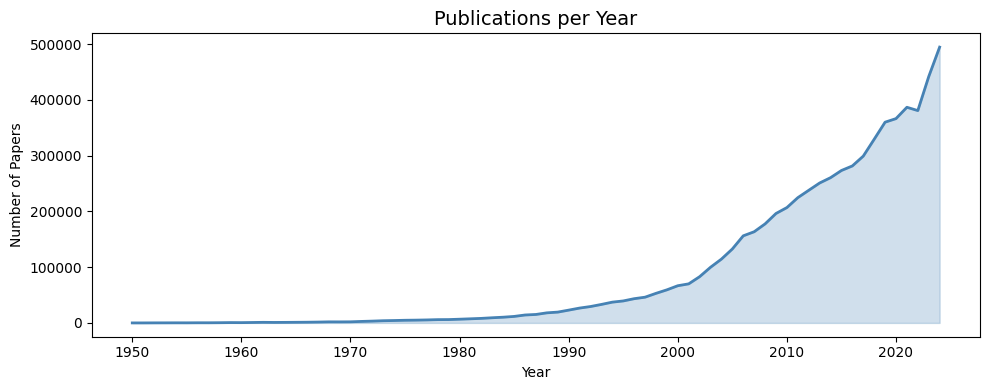

In [8]:
df_year = con.sql(f"""
    SELECT year, COUNT(*) AS papers
    FROM papers
    WHERE year BETWEEN 1950 AND 2024
    GROUP BY year
    ORDER BY year
""").df()
 
fig, ax = plt.subplots(figsize=(10,4))
ax.fill_between(df_year["year"], df_year["papers"], alpha=0.25, color="steelblue")
ax.plot(df_year["year"], df_year["papers"], color="steelblue", linewidth=2)
ax.set_title("Publications per Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Papers")

plt.tight_layout()
plt.show()
 

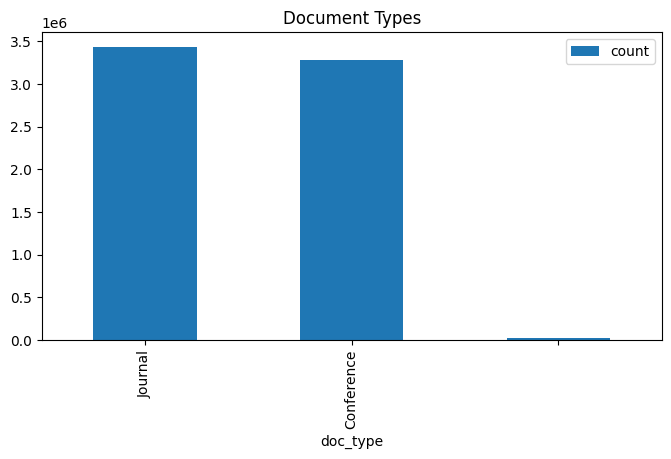

In [9]:
df = con.sql(f"""
    SELECT doc_type, COUNT(*) AS count
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE doc_type IS NOT NULL
    GROUP BY doc_type ORDER BY count DESC
""").df()

df.plot(kind="bar", x="doc_type", y="count", title="Document Types", figsize=(8,4))
plt.show()

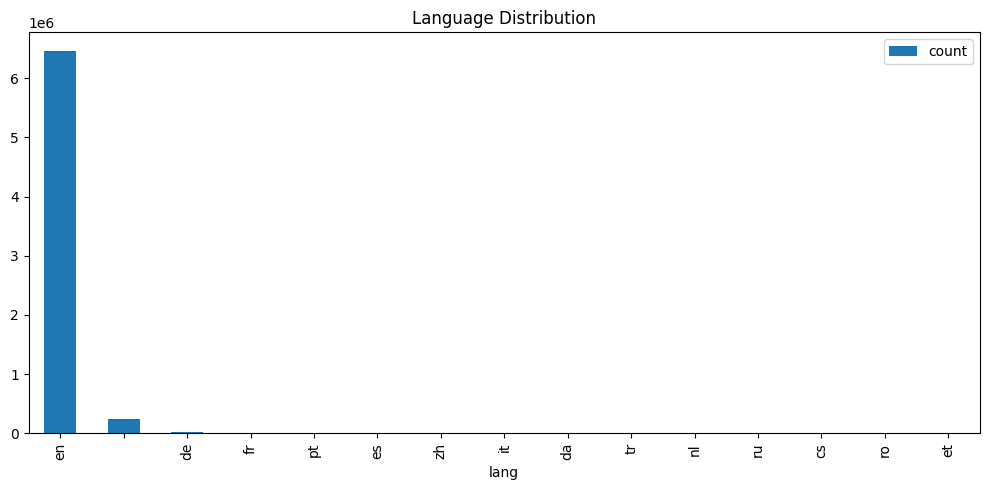

In [10]:
# Language distribution from parquet
df = con.sql(f"""
    SELECT lang, COUNT(*) AS count
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE lang IS NOT NULL
    GROUP BY lang 
    ORDER BY count DESC
    LIMIT 15
""").df()

df.plot(kind="bar", x="lang", y="count", title="Language Distribution", figsize=(10, 5))
plt.tight_layout()
plt.show()

## Citation Analysis

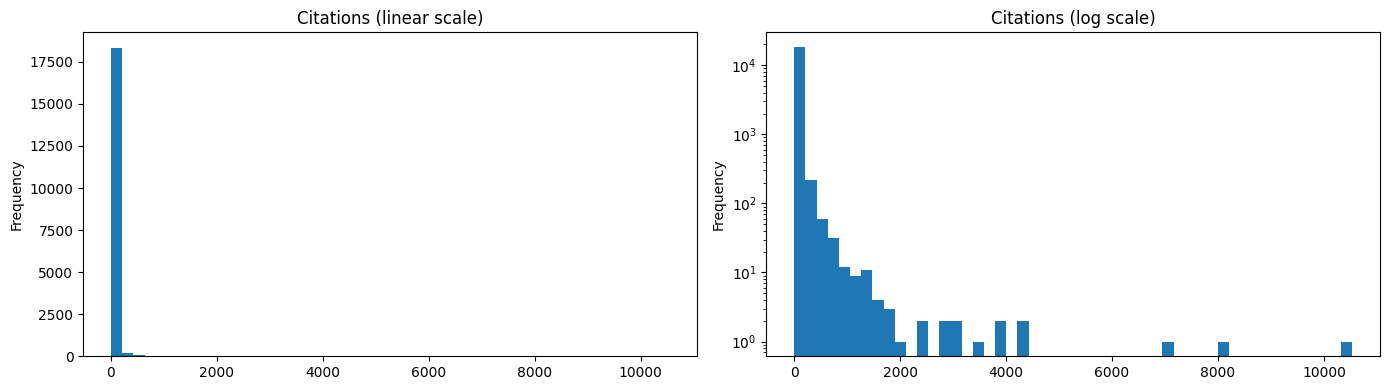

In [11]:
df = con.sql(f"""
    SELECT n_citation
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE n_citation IS NOT NULL AND n_citation > 0
    USING SAMPLE 20000
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["n_citation"].plot(kind="hist", bins=50, ax=axes[0], title="Citations (linear scale)")
df["n_citation"].apply(lambda x: x+1).plot(kind="hist", bins=50, logy=True, ax=axes[1], title="Citations (log scale)")
plt.tight_layout()
plt.show()

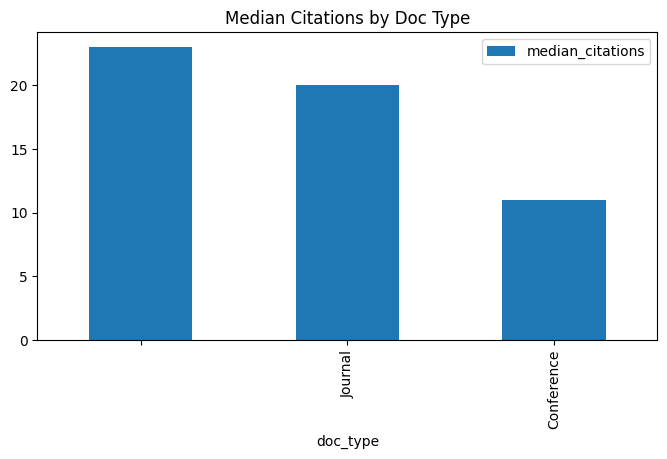

In [12]:
df = con.sql(f"""
    SELECT doc_type,
           COUNT(*) AS papers,
           AVG(n_citation) AS avg_citations,
           MEDIAN(n_citation) AS median_citations
    
    -- FROM papers         
    FROM read_parquet('{PARQUET}')
    WHERE doc_type IS NOT NULL AND n_citation IS NOT NULL
    GROUP BY doc_type ORDER BY median_citations DESC
""").df()

df.plot(kind="bar", x="doc_type", y="median_citations", title="Median Citations by Doc Type", figsize=(8,4))
plt.show()

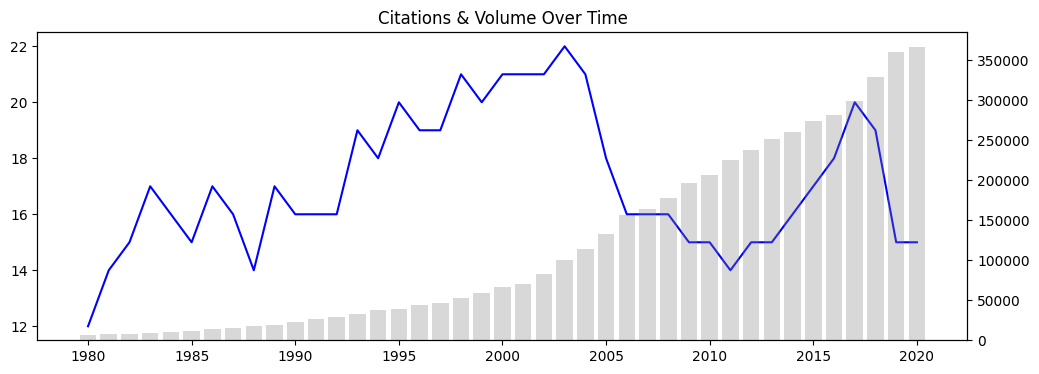

In [13]:
df = con.sql(f"""
    SELECT year,
           MEDIAN(n_citation) AS median_citations,
           COUNT(*) AS papers
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE year BETWEEN 1980 AND 2020 AND n_citation IS NOT NULL
    GROUP BY year ORDER BY year
""").df()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(df["year"], df["median_citations"], color="blue", label="Median citations")
ax2.bar(df["year"], df["papers"], alpha=0.3, color="gray", label="Paper count")
ax1.set_title("Citations & Volume Over Time")
plt.show()

## Authors and Collaborations

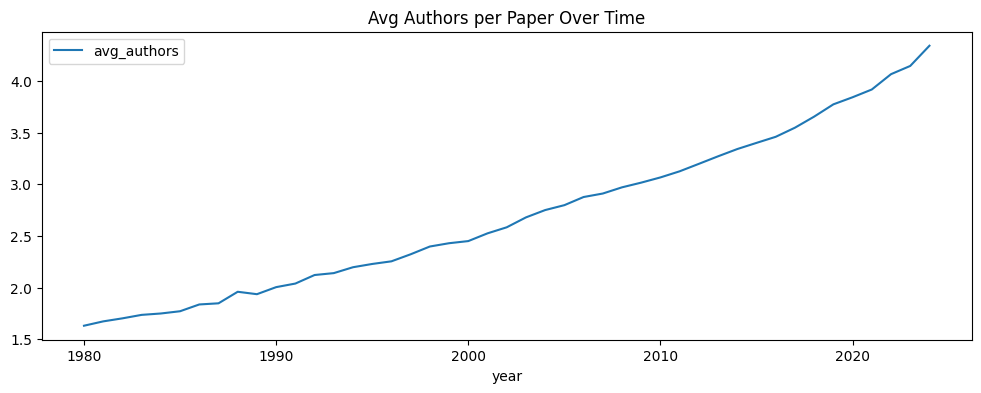

In [14]:
df = con.sql(f"""
    SELECT year,
           AVG(ARRAY_LENGTH(authors)) AS avg_authors
 -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE year BETWEEN 1980 AND 2024 AND authors IS NOT NULL
    GROUP BY year ORDER BY year
""").df()

df.plot(kind="line", x="year", y="avg_authors", title="Avg Authors per Paper Over Time", figsize=(12,4))
plt.show()

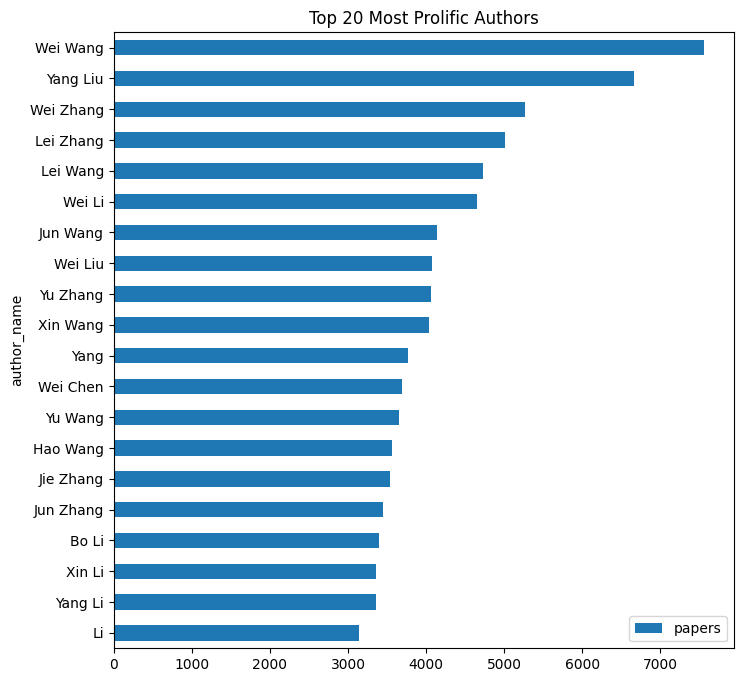

In [15]:
df = con.sql(f"""
    SELECT
        author.name AS author_name,
        COUNT(*) AS papers
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.name IS NOT NULL
      AND author.name != ''
    GROUP BY 1
    ORDER BY papers DESC
    LIMIT 20
""").df()

df.plot(kind="barh", x="author_name", y="papers", title="Top 20 Most Prolific Authors", figsize=(8,8))
plt.gca().invert_yaxis()
plt.show()

## Keywords and Venues

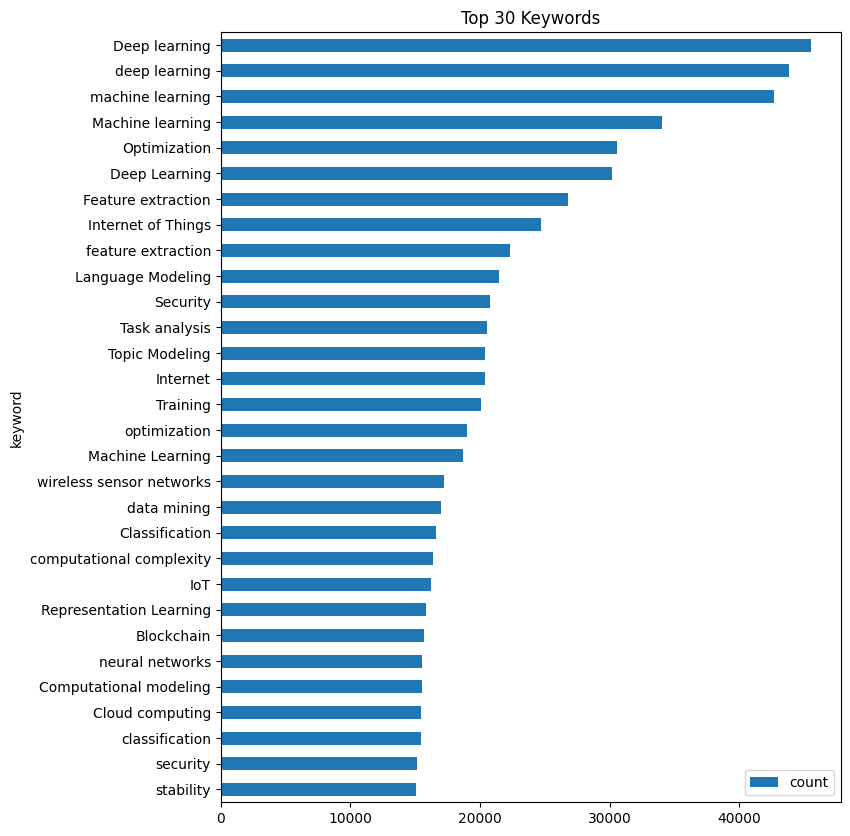

In [16]:
df = con.sql(f"""
    SELECT kw AS keyword, COUNT(*) AS count
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(keywords) AS t(kw)
    WHERE kw IS NOT NULL AND kw != ''
    GROUP BY kw
    ORDER BY count DESC
    LIMIT 30
""").df()

df.plot(kind="barh", x="keyword", y="count", title="Top 30 Keywords", figsize=(8,10))
plt.gca().invert_yaxis()
plt.show()

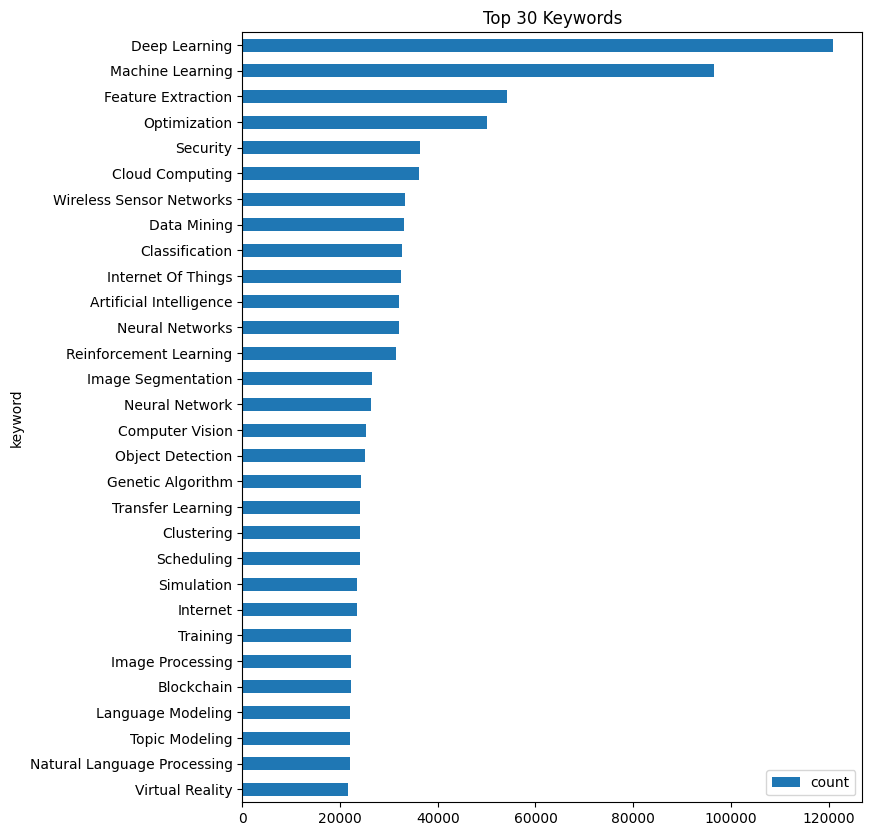

In [17]:
# merge identical keywords by case

def to_camel_case(s):
    return ' '.join(word.capitalize() for word in s.split())

raw = con.sql(f"""
    SELECT kw AS keyword
    FROM read_parquet('{PARQUET}')
    -- FROM papers
    CROSS JOIN
         UNNEST(keywords) AS t(kw)
    WHERE kw IS NOT NULL AND kw != ''
""").df()

raw['keyword'] = raw['keyword'].apply(to_camel_case)

df = (
    raw.groupby('keyword', as_index=False)
       .size()
       .rename(columns={'size': 'count'})
       .sort_values('count', ascending=False)
       .head(30)
)

df.plot(kind="barh", x="keyword", y="count", title="Top 30 Keywords", figsize=(8, 10))
plt.gca().invert_yaxis()
plt.show()

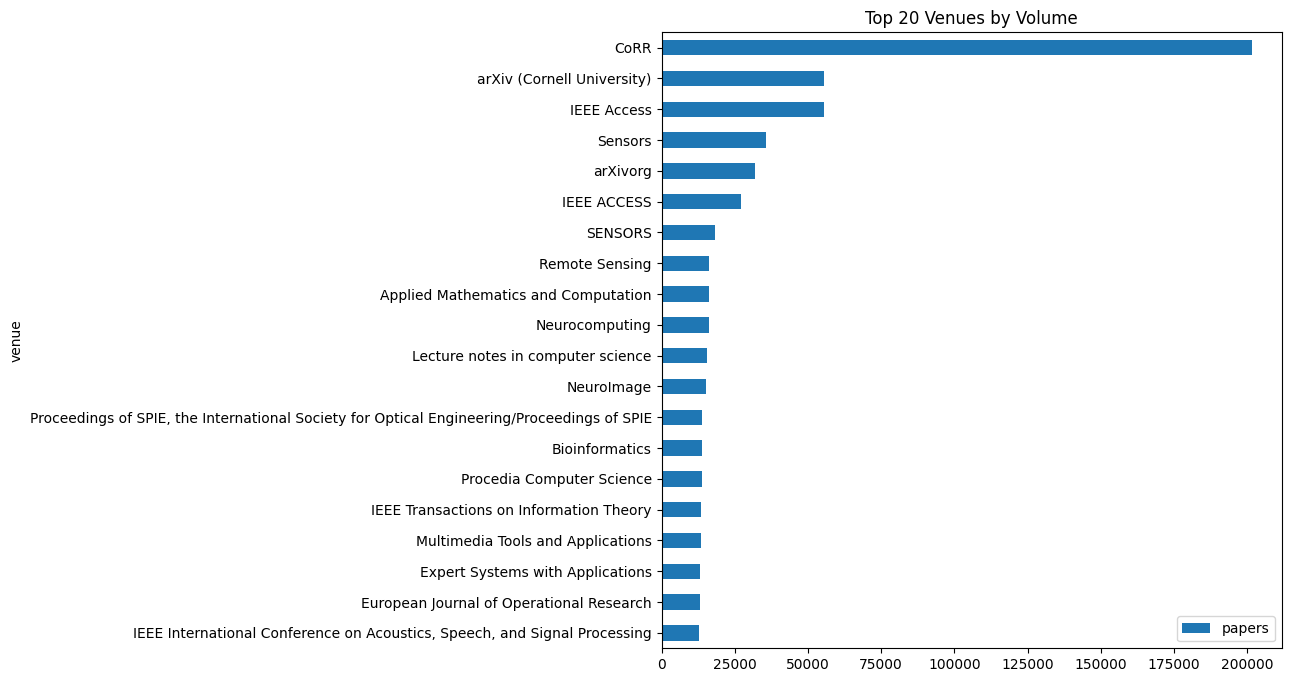

In [18]:
df = con.sql(f"""
    SELECT venue, COUNT(*) AS papers, MEDIAN(n_citation) AS median_citations
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE venue IS NOT NULL AND venue != ''
    GROUP BY venue
    ORDER BY papers DESC
    LIMIT 20
""").df()

df.plot(kind="barh", x="venue", y="papers", title="Top 20 Venues by Volume", figsize=(8,8))
plt.gca().invert_yaxis()
plt.show()

##  Missingness

In [19]:
# Missingness report (null + empty string/array) from parquet
missing_df = con.sql(f"""
WITH base AS (
    SELECT
        COUNT(*)::DOUBLE AS total_rows,
        SUM(CASE WHEN id IS NULL OR TRIM(COALESCE(id, '')) = '' THEN 1 ELSE 0 END) AS miss_id,
        SUM(CASE WHEN title IS NULL OR TRIM(COALESCE(title, '')) = '' THEN 1 ELSE 0 END) AS miss_title,
        SUM(CASE WHEN abstract IS NULL OR TRIM(COALESCE(abstract, '')) = '' THEN 1 ELSE 0 END) AS miss_abstract,
        SUM(CASE WHEN keywords IS NULL OR ARRAY_LENGTH(keywords) = 0 THEN 1 ELSE 0 END) AS miss_keywords,
        SUM(CASE WHEN year IS NULL THEN 1 ELSE 0 END) AS miss_year,
        SUM(CASE WHEN authors IS NULL OR ARRAY_LENGTH(authors) = 0 THEN 1 ELSE 0 END) AS miss_authors,
        SUM(CASE WHEN "references" IS NULL OR ARRAY_LENGTH("references") = 0 THEN 1 ELSE 0 END) AS miss_references,
        SUM(CASE WHEN lang IS NULL OR TRIM(COALESCE(lang, '')) = '' THEN 1 ELSE 0 END) AS miss_lang,
        SUM(CASE WHEN venue IS NULL OR TRIM(COALESCE(venue, '')) = '' THEN 1 ELSE 0 END) AS miss_venue,
        SUM(CASE WHEN doc_type IS NULL OR TRIM(COALESCE(doc_type, '')) = '' THEN 1 ELSE 0 END) AS miss_doc_type,
        SUM(CASE WHEN doi IS NULL OR TRIM(COALESCE(doi, '')) = '' THEN 1 ELSE 0 END) AS miss_doi,
        SUM(CASE WHEN page_start IS NULL OR TRIM(COALESCE(page_start, '')) = '' THEN 1 ELSE 0 END) AS miss_page_start,
        SUM(CASE WHEN page_end IS NULL OR TRIM(COALESCE(page_end, '')) = '' THEN 1 ELSE 0 END) AS miss_page_end,
        SUM(CASE WHEN n_citation IS NULL THEN 1 ELSE 0 END) AS miss_n_citation
    FROM read_parquet('{PARQUET}')
    -- FROM papers
)
SELECT * FROM (
    SELECT 'id' AS feature,        100.0 * miss_id / total_rows AS missing_pct FROM base
    UNION ALL SELECT 'title',      100.0 * miss_title / total_rows FROM base
    UNION ALL SELECT 'abstract',   100.0 * miss_abstract / total_rows FROM base
    UNION ALL SELECT 'keywords',   100.0 * miss_keywords / total_rows FROM base
    UNION ALL SELECT 'year',       100.0 * miss_year / total_rows FROM base
    UNION ALL SELECT 'authors',    100.0 * miss_authors / total_rows FROM base
    UNION ALL SELECT 'references', 100.0 * miss_references / total_rows FROM base
    UNION ALL SELECT 'lang',       100.0 * miss_lang / total_rows FROM base
    UNION ALL SELECT 'venue',      100.0 * miss_venue / total_rows FROM base
    UNION ALL SELECT 'doc_type',   100.0 * miss_doc_type / total_rows FROM base
    UNION ALL SELECT 'doi',        100.0 * miss_doi / total_rows FROM base
    UNION ALL SELECT 'page_start', 100.0 * miss_page_start / total_rows FROM base
    UNION ALL SELECT 'page_end',   100.0 * miss_page_end / total_rows FROM base
    UNION ALL SELECT 'n_citation', 100.0 * miss_n_citation / total_rows FROM base
)
ORDER BY missing_pct DESC
""").df()

display(missing_df)

,feature,missing_pct
0,page_end,27.977907
1,page_start,26.567752
2,keywords,16.196907
3,references,15.643282
4,doi,8.945102
5,abstract,5.377448
6,lang,3.604579
7,venue,0.667016
8,doc_type,0.312697
9,authors,0.000045


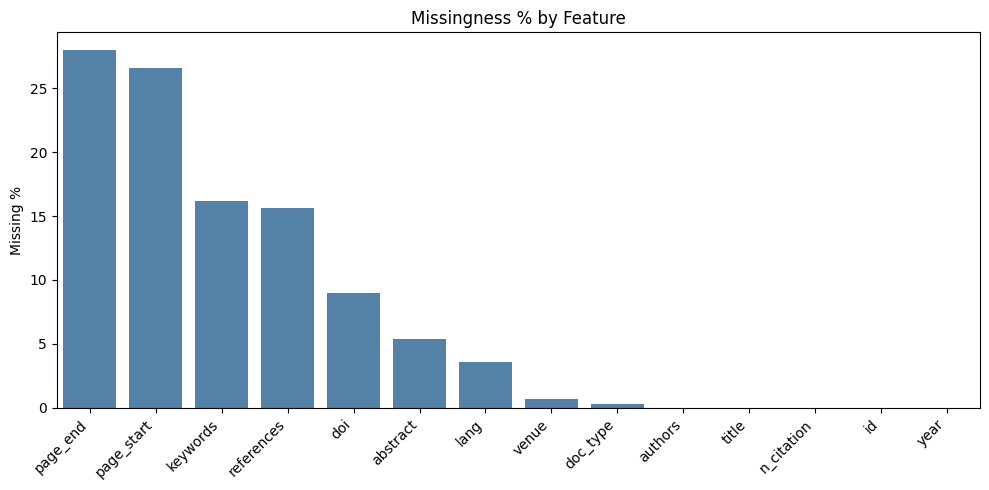

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x="feature", y="missing_pct", color="steelblue")
plt.title("Missingness % by Feature")
plt.ylabel("Missing %")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Data Quality

In [21]:
df = con.sql(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(title) AS has_title,
        COUNT(abstract) AS has_abstract,
        COUNT(year) AS has_year,
        COUNT(doi) AS has_doi,
        COUNT(n_citation) AS has_citations,
        COUNT(venue) AS has_venue
    -- FROM papers
    FROM read_parquet('{PARQUET}')
""").df()

print(df.T)

                     0
total          6729828
has_title      6729828
has_abstract   6729828
has_year       6729828
has_doi        6729828
has_citations  6729828
has_venue      6703333


# Data quality

In [22]:
df = con.sql(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(title) AS has_title,
        COUNT(abstract) AS has_abstract,
        COUNT(year) AS has_year,
        COUNT(doi) AS has_doi,
        COUNT(n_citation) AS has_citations,
        COUNT(venue) AS has_venue
    -- FROM papers
    FROM read_parquet('{PARQUET}')
""").df()

print(df.T)

                     0
total          6729828
has_title      6729828
has_abstract   6729828
has_year       6729828
has_doi        6729828
has_citations  6729828
has_venue      6703333


## What this next check does (author.id / author.org missingness)
It explodes the authors array so each author mention in each paper is one row.
Then it counts how often author.id is missing, how often author.org is missing, and how often both are missing.
Output is a table with counts and percentages.
How to read it:

- High miss_author_id_pct means many authors cannot be uniquely tracked across papers.
- High miss_author_org_pct means affiliation-based features may be weak/noisy.
- High miss_both_pct means severe metadata incompleteness for author-level modeling.

In [23]:
# Missing author.id and author.org rates (explicit)
missing_author_fields_df = con.sql(f"""
WITH a AS (
    SELECT
        author.name AS author_name,
        author.id   AS author_id,
        author.org  AS author_org
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
),
base AS (
    SELECT
        COUNT(*)::DOUBLE AS total_author_mentions,
        SUM(CASE WHEN author_id IS NULL OR TRIM(COALESCE(author_id, '')) = '' THEN 1 ELSE 0 END) AS miss_author_id,
        SUM(CASE WHEN author_org IS NULL OR TRIM(COALESCE(author_org, '')) = '' THEN 1 ELSE 0 END) AS miss_author_org,
        SUM(CASE WHEN (author_id IS NULL OR TRIM(COALESCE(author_id, '')) = '')
                  AND (author_org IS NULL OR TRIM(COALESCE(author_org, '')) = '')
                 THEN 1 ELSE 0 END) AS miss_both
    FROM a
)
SELECT
    total_author_mentions,
    miss_author_id,
    ROUND(100.0 * miss_author_id / NULLIF(total_author_mentions, 0), 4) AS miss_author_id_pct,
    miss_author_org,
    ROUND(100.0 * miss_author_org / NULLIF(total_author_mentions, 0), 4) AS miss_author_org_pct,
    miss_both,
    ROUND(100.0 * miss_both / NULLIF(total_author_mentions, 0), 4) AS miss_both_pct
FROM base;
""").df()
display(missing_author_fields_df)

,total_author_mentions,miss_author_id,miss_author_id_pct,miss_author_org,miss_author_org_pct,miss_both,miss_both_pct
0,22998013.0,2284412.0,9.9331,4208990.0,18.3015,802063.0,3.4875


author.id missing ≈ 9.94% author.org missing ≈ 18.30% both missing ≈ 3.48%

Missingness is too high for author.org; dropping would bias data

We should create missingness features. booleans like: has_author_id, has_author_org, and pair-level both_have_org.

Use author.id as primary identity, normalized name only as fallback.

With this class rate, train on sampled negatives (e.g., 1:5 or 1:10 pos:neg) and evaluate with PR-AUC / Recall@K, not accuracy.

## What this next check does (author-name variation / normalization)
It normalizes names (lowercase, remove punctuation, collapse spaces).
It groups by normalized form and finds cases where many raw spellings map to the same normalized author string.
Output shows likely spelling/format variants (for example accents, dots, extra spaces, initials).
How to read it:

- n_raw_variants = number of distinct original spellings for the same normalized name.
- mentions = total occurrences of that normalized name.
- raw_variants lists the observed spellings with counts.
Important:

This is a heuristic quality check, not true entity resolution.
Same normalized name can still refer to different people (homonyms).

In [24]:
# 2) Author-name variation / normalization checks (memory-safe)

# DuckDB tuning for this heavy aggregation
con.sql("SET preserve_insertion_order = false;")
con.sql("SET threads = 4;")

name_variation_df = con.sql(f"""
WITH flat AS (
    SELECT TRIM(author.name) AS raw_name
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.name IS NOT NULL AND TRIM(author.name) <> ''
),
norm_counts AS (
    SELECT
        LOWER(
            REGEXP_REPLACE(
                REGEXP_REPLACE(raw_name, '[^[:alnum:] ]', ' ', 'g'),
                '\\s+', ' ', 'g'
            )
        ) AS normalized_name,
        raw_name,
        COUNT(*) AS raw_mentions
    FROM flat
    GROUP BY 1, 2
),
name_stats AS (
    SELECT
        normalized_name,
        SUM(raw_mentions) AS mentions,
        COUNT(*) AS n_raw_variants
    FROM norm_counts
    GROUP BY normalized_name
    HAVING COUNT(*) > 1
    ORDER BY n_raw_variants DESC, mentions DESC
    LIMIT 30
)
SELECT
    s.normalized_name,
    s.mentions,
    s.n_raw_variants,
    STRING_AGG(
        nc.raw_name || ' (' || CAST(nc.raw_mentions AS VARCHAR) || ')',
        ' | '
        ORDER BY nc.raw_mentions DESC, nc.raw_name
    ) AS raw_variants
FROM name_stats s
JOIN norm_counts nc USING (normalized_name)
GROUP BY s.normalized_name, s.mentions, s.n_raw_variants
ORDER BY s.n_raw_variants DESC, s.mentions DESC;
""").df()

display(name_variation_df)

,normalized_name,mentions,n_raw_variants,raw_variants
0,,2018.0,1909,刘炜 (5) | 王作英 (4) | : (3) | 于炯 (3) | 刘伟 (3) | 刘...
1,c c jay kuo,605.0,14,C. -C. Jay Kuo (372) | C.-C. Jay Kuo (107) | C...
2,yang liu,6701.0,10,Yang Liu (6662) | Yang Liu (14) | Yang Liu (1...
3,xuemin sherman shen,901.0,10,Xuemin (Sherman) Shen (815) | Xuemin Sherman S...
4,wil m p van der aalst,645.0,10,Wil M. P. van der Aalst (598) | Wil M. P. Van ...
5,alex sandy pentland,98.0,10,Alex 'Sandy' Pentland (35) | Alex (Sandy) Pent...
6,max q h meng,491.0,9,Max Q. -H. Meng (251) | Max Q-H Meng (107) | M...
7,florian floyd mueller,202.0,9,Florian 'Floyd' Mueller (167) | Florian Floyd ...
8,willem jan van den heuvel,153.0,9,Willem-Jan van den Heuvel (115) | Willem-Jan V...
9,y h taguchi,37.0,9,Y-h. Taguchi (16) | Y-h Taguchi (8) | Y-H. Tag...


The name-variation table is for finding likely spelling variants; treat it as cleaning support, not truth.

We should build canonical text forms (lowercase, trim, punctuation/space cleanup, unicode normalization). Keep a small manual alias map for top recurring variants from the variation output

## What this next check does (temporal consistency of affiliations)
- It keeps authors with a valid author.id and year.
- For each author across time, it counts how many distinct non-empty organizations appear.
- It returns authors with more than one organization over their timeline.

How to read it:

- n_distinct_orgs > 1 can mean real career moves or inconsistent/dirty org strings.
- timeline_rows and year range (first_year, last_year) give context on how broad the timeline is.
- Rows at the top are the strongest candidates for manual cleaning rules (org normalization, alias mapping).

In [25]:
# Temporal consistency of author affiliations
author_org_temporal_df = con.sql(f"""
WITH author_timeline AS (
    SELECT
        author.id AS author_id,
        MIN(TRIM(author.name)) AS sample_name,
        year,
        NULLIF(TRIM(author.org), '') AS org
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.id IS NOT NULL AND TRIM(author.id) <> ''
      AND year IS NOT NULL
    GROUP BY author.id, year, NULLIF(TRIM(author.org), '')
)
 ,agg AS (
    SELECT
        author_id,
        MIN(sample_name) AS sample_name,
        COUNT(*) AS timeline_rows,
        COUNT(DISTINCT org) FILTER (WHERE org IS NOT NULL) AS n_distinct_orgs,
        MIN(year) AS first_year,
        MAX(year) AS last_year
    FROM author_timeline
    GROUP BY author_id
)
SELECT
    author_id,
    sample_name,
    timeline_rows,
    n_distinct_orgs,
    first_year,
    last_year
FROM agg
WHERE n_distinct_orgs > 1
ORDER BY n_distinct_orgs DESC, timeline_rows DESC
LIMIT 30;
""").df()

display(author_org_temporal_df)

,author_id,sample_name,timeline_rows,n_distinct_orgs,first_year,last_year
0,53f6615fdabfae8dcd35b276,JIAO Li-cheng,929,599,1998,2025
1,542c458bdabfae2b4e1fb0c8,H Jin,903,537,1997,2025
2,53f48c1fdabfaea7cd1ce3f8,D. Tao,744,511,2004,2025
3,53f445bcdabfaee4dc7ce5dc,Alouini Mohamed-Slim,880,496,1997,2025
4,53f48ce5dabfaea7cd1d0893,Li Xuelong,659,441,1994,2025
5,5625051945cedb339856ec92,A Abraham,609,406,1998,2025
6,5429fd93dabfae61d494cf5d,G Wen,759,404,1990,2025
7,53f7ffb0dabfae90ec136659,N NAVAB,644,373,1989,2025
8,53f45044dabfaedf435f34cb,Benini Luca,741,371,1994,2025
9,54084ac2dabfae450f408e17,A Alimi,474,363,1993,2025


for example, the first row shows that:

The same author ID appears a lot in the dataset (786 author-year-org records). Across those records, there are 510 different organization strings. This is far too high to be realistic as true job changes, so it mostly indicates: noisy/inconsistent author.org text, variants of the same institution, possible mixed identities in the source.

What to do with it:

Keep author.id as the stable identity key. Normalize author.org (case, punctuation, spacing, abbreviations). Build an org alias map for top repeated variants. For modeling, use robust org features (has_org, normalized org match) rather than raw org string equality.

# Data Cleaning

In [26]:
import re
import unicodedata

def normalize_text(value):
    if value is None:
        return ""
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

try:
    con.create_function("normalize_text", normalize_text, [str], str)
except Exception:
    pass

Author canonicalization layer: 'author.id' is the primary key, and normalized name is the fallback.

In [27]:
con.sql(f"""
CREATE OR REPLACE TABLE author_mentions_clean AS
SELECT
    p.id AS paper_id,
    p.year,
    CASE
        WHEN a.author.id IS NOT NULL AND TRIM(a.author.id) <> ''
            THEN TRIM(a.author.id)
        ELSE 'name:' || normalize_text(a.author.name)
    END AS author_key,
    TRIM(a.author.id) AS author_id_raw,
    normalize_text(a.author.name) AS author_name_norm,
    TRIM(a.author.name) AS author_name_raw,
    normalize_text(a.author.org) AS author_org_norm
FROM read_parquet('{PARQUET}') p
-- FROM papers p
CROSS JOIN UNNEST(p.authors) AS a(author)
WHERE a.author.name IS NOT NULL
  AND TRIM(a.author.name) <> '';
""")

In [28]:
con.sql("""
CREATE OR REPLACE TABLE author_name_canonical AS
WITH counts AS (
    SELECT
        author_key,
        author_name_norm,
        author_name_raw,
        COUNT(*) AS n_mentions
    FROM author_mentions_clean
    GROUP BY 1, 2, 3
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY author_key
            ORDER BY n_mentions DESC, LENGTH(author_name_raw) DESC, author_name_raw
        ) AS rn
    FROM counts
)
SELECT
    author_key,
    author_name_raw AS canonical_author_name,
    author_name_norm AS canonical_author_name_norm,
    n_mentions
FROM ranked
WHERE rn = 1;
""")

In [29]:
display(con.sql("SELECT * FROM author_name_canonical LIMIT 10").df())

,author_key,canonical_author_name,canonical_author_name_norm,n_mentions
0,560a1b4245ce1e595fb793f4,Yi-Ju Tseng,yi ju tseng,22
1,560a2d0a45cedb339705a857,Robert E. Miller,robert e miller,5
2,560a2d9a45cedb339705be5a,Antonio Orlando,antonio orlando,7
3,560a3fb845ce1e595fc1f316,Simon Yu,simon yu,1
4,560a437f45cedb339708af1f,Yu Kang,yu kang,3
5,560a4d2a45cedb339709edf7,Yujiang Wang,yujiang wang,28
6,560a6ab745cedb33970d96d7,Guo Jiandong,guo jiandong,1
7,560a6dcb45ce1e595fc92838,Hui Li,hui li,5
8,560a76b145cedb33970f22e5,Junghyun Lee,junghyun lee,3
9,560a9fe645ce1e595fde753c,Florent Colin,florent colin,1


Use the resolved author-table cells below. The old raw-name join should not be used.

In [30]:
con.sql("""
CREATE OR REPLACE TABLE paper_authors AS
SELECT
    am.paper_id AS id,
    am.author_key,
    ac.canonical_author_name AS author_name,
    am.author_org_norm
FROM author_mentions_clean am
LEFT JOIN author_name_canonical ac
    ON am.author_key = ac.author_key;
""")

con.sql("""
CREATE OR REPLACE TABLE author_stats AS
SELECT
    author_key,
    author_name,
    COUNT(*) AS author_papers,
    MEDIAN(p.n_citation) AS author_median_citations,
    AVG(p.n_citation) AS author_avg_citations,
    MAX(p.n_citation) AS author_max_citations
FROM paper_authors pa
JOIN papers p
    ON pa.id = p.id
GROUP BY author_key, author_name;
""")

con.sql(f"""
CREATE OR REPLACE TABLE features_author AS
SELECT
    p.id,
    COUNT(DISTINCT pa.author_key) AS n_authors,
    COALESCE(AVG(a.author_avg_citations), 0) AS avg_author_citations,
    COALESCE(MAX(a.author_max_citations), 0) AS max_author_citations,
    CASE WHEN COUNT(DISTINCT pa.author_key) > 1 THEN 1 ELSE 0 END AS multi_authored
FROM read_parquet('{PARQUET}') p
-- FROM papers p
LEFT JOIN paper_authors pa
    ON p.id = pa.id
LEFT JOIN author_stats a
    ON pa.author_key = a.author_key
GROUP BY p.id;
""")

display(con.sql("SELECT * FROM paper_authors LIMIT 10").df())

,id,author_key,author_name,author_org_norm
0,599c785a601a182cd25bd70b,53f3aa93dabfae4b34af4727,Chunqiang Hu,george washington univ dept comp sci washingto...
1,599c785f601a182cd25bfd9e,5631ba3145cedb3399effac0,Valerie Dos Santos Martins,univ lyon 1 cnrs automat proc control lab lage...
2,599c786a601a182cd25c4f36,5448b82ddabfae87b7e6c02b,Manuel Filipe Santos,univ minho dept informat syst algoritmi res ct...
3,599c7876601a182cd25cb19e,53f446d5dabfaedd74df0184,Yulei Wu,chinese acad sci comp network informat ctr bei...
4,599c7888601a182cd25d3396,60d9a7c96750f85de6991bfc,Shenghong Li,shanghai jiao tong univ sch informat secur eng...
5,599c789c601a182cd25dcc52,63af377184ab04bd7fb40759,Chien-Heng Tu,natl kaohsiung univ appl sci dept finance kaoh...
6,599c789f601a182cd25de30e,53f438e0dabfaee43ec47bf2,Martijn van de Giessen,leiden univ med ctr dept radiol div image proc...
7,599c789f601a182cd25de47b,54483e7cdabfae87b7df2d1c,Erich Novak,univ jena math inst ernst abbe pl 2 d 07743 je...
8,599c78bb601a182cd25eaf94,53f476dedabfaeb22f5687ba,Robert Fitch,None
9,599c78cb601a182cd25f2952,5631217e45cedb3399cb9513,Mona Faraji-Niri,iran univ sci technol dept elect engn tehran iran


In [31]:
con.sql(f"""
CREATE OR REPLACE TABLE papers_clean AS
WITH base AS (
    SELECT
        p.*,
        normalize_text(p.title) AS title_norm,
        normalize_text(p.abstract) AS abstract_norm,
        normalize_text(p.venue) AS venue_norm,
        normalize_text(p.doc_type) AS doc_type_norm,
        CASE
            WHEN p.id IS NULL OR TRIM(p.id) = '' THEN
                'paper_' || md5(
                    COALESCE(p.title, '') || '|' ||
                    COALESCE(p.abstract, '') || '|' ||
                    COALESCE(CAST(p.year AS VARCHAR), '') || '|' ||
                    COALESCE(p.venue, '')
                )
            ELSE TRIM(p.id)
        END AS id_clean,
        CASE WHEN p.id IS NULL OR TRIM(p.id) = '' THEN 1 ELSE 0 END AS was_missing_id
    -- FROM papers p
    FROM read_parquet('{PARQUET}') p
)
SELECT
    id_clean AS id,
    NULLIF(title_norm, '') AS title,
    NULLIF(abstract_norm, '') AS abstract,
    year,
    authors,
    keywords,
    "references",
    NULLIF(venue_norm, '') AS venue,
    CASE
        WHEN regexp_matches(COALESCE(venue_norm, ''), '(conference|symposium|workshop|proceedings|meeting)') THEN 'conference'
        WHEN regexp_matches(COALESCE(venue_norm, ''), '(journal|transactions|letters)') THEN 'journal'
        WHEN regexp_matches(COALESCE(venue_norm, ''), '(book|chapter|lecture notes)') THEN 'book'
        WHEN doc_type_norm IN ('article', 'journal article') THEN 'journal'
        WHEN doc_type_norm IN ('inproceedings', 'conference paper', 'conference') THEN 'conference'
        WHEN doc_type_norm = '' THEN 'unknown'
        ELSE doc_type_norm
    END AS doc_type,
    doi,
    page_start,
    page_end,
    n_citation,
    ARRAY_LENGTH(authors) AS n_authors,
    ARRAY_LENGTH(keywords) AS n_keywords,
    ARRAY_LENGTH("references") AS n_references,
    LENGTH(COALESCE(NULLIF(title_norm, ''), '')) AS title_len,
    LENGTH(COALESCE(NULLIF(abstract_norm, ''), '')) AS abstract_len,
    TRY_CAST(page_end AS BIGINT) - TRY_CAST(page_start AS BIGINT) AS page_count,
    was_missing_id
FROM base;
""")

con.sql("CREATE OR REPLACE TABLE papers AS SELECT * FROM papers_clean")

display(con.sql("SELECT id, title, venue, doc_type, was_missing_id FROM papers LIMIT 5").df())

,id,title,venue,doc_type,was_missing_id
0,599c7a82601a182cd26bfa2a,new products,ieee micro,journal,0
1,599c7a85601a182cd26c0fb2,compression and approximate matching,the computer journal,journal,0
2,599c7a9a601a182cd26caa31,deeply learned view invariant features for cro...,ieee transactions on image processing,journal,0
3,599c7a9b601a182cd26cb1b6,hierarchical image segmentation based on itera...,ieee transactions on image processing,journal,0
4,599c7ab2601a182cd26d61fc,reducing the complexity of dataflow graphs usi...,acm transactions on design automation of elect...,journal,0


# Target Focused Exploration

In [32]:
# Class balance: citation links (positive) vs non-links (negative)

# Assumptions:
## - `papers.id` is the paper identifier
## - `papers.references` is an array of cited paper ids
## - we only keep references that point to ids present in `papers`

# Set temp directory for DuckDB (Windows fix)

balance_df = con.sql(f"""
WITH ids AS (
    SELECT DISTINCT id
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE id IS NOT NULL AND TRIM(id) <> ''
)
 ,pos AS (
    SELECT DISTINCT
        p.id AS src_id,
        ref AS dst_id
    -- FROM papers p
    FROM read_parquet('{PARQUET}') p
    CROSS JOIN UNNEST(p."references") AS t(ref)
    INNER JOIN ids i ON i.id = ref
    WHERE p.id IS NOT NULL
      AND TRIM(p.id) <> ''
      AND ref IS NOT NULL
      AND TRIM(ref) <> ''
      AND p.id <> ref
)
 ,counts AS (
    SELECT
        (SELECT COUNT(*) FROM ids) AS n_nodes,
        (SELECT COUNT(*) FROM pos) AS n_positive_links
)
SELECT
    n_nodes,
    n_positive_links,
    (n_nodes * (n_nodes - 1) - n_positive_links) AS n_non_links,
    ROUND(100.0 * n_positive_links / NULLIF(n_nodes * (n_nodes - 1), 0), 6) AS positive_rate_pct,
    ROUND(100.0 * (n_nodes * (n_nodes - 1) - n_positive_links) / NULLIF(n_nodes * (n_nodes - 1), 0), 6) AS non_link_rate_pct
FROM counts;
""").df()

display(balance_df)

,n_nodes,n_positive_links,n_non_links,positive_rate_pct,non_link_rate_pct
0,6729828,73640521,45290504539235,0.000163,99.999837


In [33]:
# ratio as "1 positive : X negatives"
pos = float(balance_df.loc[0, "n_positive_links"])
neg = float(balance_df.loc[0, "n_non_links"])
print(f"Positive link rate: {balance_df.loc[0, 'positive_rate_pct']:.6f}%")
print(f"Non-link rate: {balance_df.loc[0, 'non_link_rate_pct']:.6f}%")

Positive link rate: 0.000163%
Non-link rate: 99.999837%


# Pair Level Analysis

## Features selection

### Correlation Matrix

In [34]:
# df = con.sql(f"""
#     SELECT
#         ARRAY_LENGTH(authors) AS n_authors,
#         ARRAY_LENGTH(keywords) AS n_keywords,
#         ARRAY_LENGTH("references") AS n_references,
#         TRY_CAST(page_end AS INT) - TRY_CAST(page_start AS INT) AS page_count,
#         LENGTH(abstract) AS abstract_length,
#         n_citation
#     FROM read_parquet('{PARQUET}')
#     WHERE n_citation IS NOT NULL
#     USING SAMPLE 20000
# """).df().dropna()

# sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Feature Correlations")
# plt.tight_layout()
# plt.show()

There are no correlated features in the original dataset, only a little correlation between n_references and abstract_lenght.

# Feature Selection

### 1 TEXT-BASED FEATURES

Features da **titolo** e **abstract** per catturare complessità e specificità:
- `title_word_count` → Lunghezza titolo
- `abstract_word_count` → Lunghezza abstract  
- `title_complexity` → Media parole nel titolo (linguaggio tecnico)
- `abstract_complexity` → Media parole nell'abstract
- `has_numbers_*` → Presenza numeri (specificità)

In [35]:
text_sql = """
CREATE OR REPLACE TABLE features_text AS
SELECT 
    id,
    CASE WHEN title IS NULL THEN 0 
         ELSE ARRAY_LENGTH(STRING_SPLIT(TRIM(title), ' '))
    END AS title_word_count,
    
    CASE WHEN abstract IS NULL THEN 0 
         ELSE ARRAY_LENGTH(STRING_SPLIT(TRIM(abstract), ' '))
    END AS abstract_word_count,
    
    CASE WHEN LENGTH(COALESCE(abstract, '')) = 0 THEN 0
         ELSE CAST(LENGTH(COALESCE(title, '')) AS FLOAT) / LENGTH(COALESCE(abstract, ''))
    END AS title_abstract_ratio,
    
    CASE WHEN title IS NULL OR ARRAY_LENGTH(STRING_SPLIT(TRIM(title), ' ')) = 0 THEN 0
         ELSE CAST(LENGTH(COALESCE(title, '')) AS FLOAT) / ARRAY_LENGTH(STRING_SPLIT(TRIM(title), ' '))
    END AS title_complexity,
    
    CASE WHEN abstract IS NULL OR ARRAY_LENGTH(STRING_SPLIT(TRIM(abstract), ' ')) = 0 THEN 0
         ELSE CAST(LENGTH(COALESCE(abstract, '')) AS FLOAT) / ARRAY_LENGTH(STRING_SPLIT(TRIM(abstract), ' '))
    END AS abstract_complexity,
    
    CASE WHEN title ~ '[0-9]' THEN 1 ELSE 0 END AS has_numbers_in_title,
    CASE WHEN abstract ~ '[0-9]' THEN 1 ELSE 0 END AS has_numbers_in_abstract
    
FROM read_parquet('{PARQUET}')
""".format(PARQUET=PARQUET)

con.sql(text_sql)
print("DONE")

DONE


### 2️ AUTHOR-BASED FEATURES

Features che catturano **reputazione** e **collaborazione**:
- `n_authors` → Numero autori  
- `first_author_avg_citations` → Media cit. primo autore (star lead researcher)
- `avg_author_citations` → Media cit. aggregato autori
- `max_author_citations` → Max cit. tra autori (presenza di star)
- `multi_authored` → Flag collaborazione (>1 autore)

In [36]:
# Compute author statistics
author_stats_sql = """
CREATE OR REPLACE TABLE author_stats AS
SELECT 
    author.name AS author_name,
    COUNT(*) AS author_papers,
    MEDIAN(n_citation) AS author_median_citations,
    AVG(n_citation) AS author_avg_citations,
    MAX(n_citation) AS author_max_citations
FROM read_parquet('{PARQUET}') 
CROSS JOIN UNNEST(authors) AS t(author)
WHERE author.name IS NOT NULL AND author.name != ''
GROUP BY author.name
""".format(PARQUET=PARQUET)

con.sql(author_stats_sql)
print("Author statistics DONE")

# Create paper-author links
paper_author_sql = """
CREATE OR REPLACE TABLE paper_authors AS
SELECT 
    p.id,
    author.name AS author_name
FROM read_parquet('{PARQUET}') AS p
CROSS JOIN UNNEST(p.authors) AS t(author)
WHERE author.name IS NOT NULL AND author.name != ''
""".format(PARQUET=PARQUET)

con.sql(paper_author_sql)
print("Paper-author links DONE")

# Join with author stats
author_features_sql = """
CREATE OR REPLACE TABLE features_author AS
SELECT 
    p.id,
    ARRAY_LENGTH(p.authors) AS n_authors,
    
    COALESCE(AVG(a.author_avg_citations), 0) AS avg_author_citations,
    COALESCE(MAX(a.author_max_citations), 0) AS max_author_citations,
    
    CASE WHEN ARRAY_LENGTH(p.authors) > 1 THEN 1 ELSE 0 END AS multi_authored

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN paper_authors pa ON p.id = pa.id
LEFT JOIN author_stats a ON pa.author_name = a.author_name
GROUP BY p.id, ARRAY_LENGTH(p.authors)
""".format(PARQUET=PARQUET)

con.sql(author_features_sql)
print("AUTHOR-BASED FEATURES DONE")

Author statistics DONE
Paper-author links DONE
AUTHOR-BASED FEATURES DONE


### 3 NETWORK & REFERENCE FEATURES

- `n_references` → Numero di riferimenti citati  
- `references_author_ratio` → Riferimenti per autore
- `citation_richness` → Densità riferimenti rispetto abstract
- `has_high_ref_count` → Flag papers che sono review/comprehensive (>50 ref)

In [37]:
network_sql = """
CREATE OR REPLACE TABLE features_network AS
SELECT 
    id,
    ARRAY_LENGTH("references") AS n_references,
    
    CASE WHEN ARRAY_LENGTH(authors) = 0 THEN 0
         ELSE CAST(ARRAY_LENGTH("references") AS FLOAT) / ARRAY_LENGTH(authors)
    END AS references_author_ratio,
    
    CASE WHEN LENGTH(abstract) = 0 THEN 0
         ELSE CAST(ARRAY_LENGTH("references") AS FLOAT) / (LENGTH(abstract) / 100.0)
    END AS citation_richness,
    
    CASE WHEN ARRAY_LENGTH("references") > 50 THEN 1 ELSE 0 END AS has_high_ref_count

FROM read_parquet('{PARQUET}')
""".format(PARQUET=PARQUET)

con.sql(network_sql)
print("NETWORK & REFERENCE FEATURES DONE")

NETWORK & REFERENCE FEATURES DONE


### 4 TEMPORAL FEATURES

Features che catturano **recency** e **stagionalità**:
- `years_since_publication` → Anni dalla pubblicazione (non usare lineare!)
- `publication_era` → Era storica (pre-2000, 2000-2009, 2010-2019, 2020+)
- `decade` → Decennio della pubblicazione
- `is_recent` → Flag se pubblicato negli ultimi 5 anni

In [38]:
temporal_sql = """
CREATE OR REPLACE TABLE features_temporal AS
SELECT 
    id,
    year,
    (2024 - year) AS years_since_publication,
    
    CASE 
        WHEN year < 2000 THEN 'pre-2000'
        WHEN year < 2010 THEN '2000-2009'
        WHEN year < 2020 THEN '2010-2019'
        ELSE '2020+'
    END AS publication_era,
    
    CAST(year / 10 * 10 AS INT) AS decade,
    
    CASE WHEN year >= 2019 THEN 1 ELSE 0 END AS is_recent

FROM read_parquet('{PARQUET}')
WHERE year IS NOT NULL
""".format(PARQUET=PARQUET)

con.sql(temporal_sql)
print("TEMPORAL FEATURES DONE")

TEMPORAL FEATURES DONE


### 5 QUALITY & IMPACT FEATURES

Features che rappresentano **qualità e impatto** normalizzati nel tempo:
- `citation_per_year` → Velocità accumulo citazioni (normalizzato per recency)  
- `is_highly_cited_for_year` → Flag se sopra mediana dell'anno
- `impact_score` → Composito: (cit/years × ln(peers per year)) **BEST predictor**

In [39]:
# Compute year statistics for normalization
con.sql("""
CREATE OR REPLACE TABLE year_citation_stats AS
SELECT 
    year,
    MEDIAN(n_citation) AS median_citations_per_year,
    AVG(n_citation) AS avg_citations_per_year,
    COUNT(*) AS papers_per_year
FROM read_parquet('{PARQUET}')
WHERE year IS NOT NULL AND n_citation IS NOT NULL
GROUP BY year
""".format(PARQUET=PARQUET))

quality_sql = """
CREATE OR REPLACE TABLE features_quality AS
SELECT 
    p.id,
    p.year,
    p.n_citation,
    
    CASE 
        WHEN (2024 - p.year) = 0 THEN CAST(p.n_citation AS FLOAT)
        WHEN p.n_citation = 0 THEN 0.0
        ELSE CAST(p.n_citation AS FLOAT) / CAST((2024 - p.year) AS FLOAT)
    END AS citation_per_year,
    
    CASE 
        WHEN p.n_citation >= COALESCE(ycs.median_citations_per_year, 0) THEN 1 
        ELSE 0 
    END AS is_highly_cited_for_year,
    
    (CAST(p.n_citation AS FLOAT) / CAST((2024 - p.year + 1) AS FLOAT)) * 
    (1 + LN(CAST(COALESCE(ycs.papers_per_year, 1) AS FLOAT))) AS impact_score
    
FROM read_parquet('{PARQUET}') AS p
LEFT JOIN year_citation_stats AS ycs ON p.year = ycs.year
WHERE p.n_citation IS NOT NULL
""".format(PARQUET=PARQUET)

con.sql(quality_sql)
print("QUALITY & IMPACT FEATURES DONE")

QUALITY & IMPACT FEATURES DONE


### 6 VENUE & DOMAIN FEATURES

Features che catturano **prestigio del venue** e **accessibility**:
- `venue_median_citations` → Prestigi proxy del venue (STRONGEST PREDICTOR)
- `venue_volume` → Numero papers nel venue (importance marker)
- `is_top_venue` → Flag se venue è nei top 50
- `is_english` → Flag lingua inglese (global reach)
- `venue_tier` → Ordinale categorico (elite → high → medium → low)

In [40]:
# Compute venue statistics
venue_stats_sql = """
CREATE OR REPLACE TABLE venue_stats AS
SELECT 
    venue,
    COUNT(*) AS venue_papers,
    MEDIAN(n_citation) AS venue_median_citations,
    AVG(n_citation) AS venue_avg_citations
FROM read_parquet('{PARQUET}')
WHERE venue IS NOT NULL AND venue != '' AND n_citation IS NOT NULL
GROUP BY venue
""".format(PARQUET=PARQUET)

con.sql(venue_stats_sql)

# Get top 50 venues
con.sql("CREATE OR REPLACE TABLE top_venues AS SELECT venue FROM venue_stats ORDER BY venue_median_citations DESC LIMIT 50")

# Create venue features
venue_features_sql = """
CREATE OR REPLACE TABLE features_venue AS
SELECT 
    p.id,
    p.venue,
    p.lang,
    
    COALESCE(vs.venue_median_citations, 0) AS venue_median_citations,
    COALESCE(vs.venue_papers, 0) AS venue_volume,
    
    CASE WHEN p.venue IN (SELECT venue FROM top_venues) THEN 1 ELSE 0 END AS is_top_venue,
    
    CASE WHEN UPPER(p.lang) IN ('EN', 'ENGLISH') THEN 1 ELSE 0 END AS is_english,
    
    CASE 
        WHEN COALESCE(vs.venue_median_citations, 0) > 100 THEN 'elite'
        WHEN COALESCE(vs.venue_median_citations, 0) > 50 THEN 'high'
        WHEN COALESCE(vs.venue_median_citations, 0) > 10 THEN 'medium'
        ELSE 'low'
    END AS venue_tier

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN venue_stats AS vs ON p.venue = vs.venue
""".format(PARQUET=PARQUET)

con.sql(venue_features_sql)
print("VENUE & DOMAIN FEATURES DONE")

VENUE & DOMAIN FEATURES DONE


### 7 GRAPH-BASED FEATURES (Network Topology)

To capture the structural importance of papers within the citation network, we compute global graph metrics using `NetworkX`. 
To strictly prevent **data leakage**, we build the graph using only historical citation data (published in or before 2020), mirroring the approach used for venue prestige.

We extract three core graph-based features to fulfill the structural feature requirement:
- `pagerank`: Measures a paper's importance based on the quantity and quality of its incoming citations.
- `hub_score`: Identifies "Hubs" (e.g., comprehensive review papers) that cite many authoritative sources.
- `authority_score`: Identifies "Authorities" (highly influential core papers) that are cited by many hubs.

In [41]:
import networkx as nx
import pandas as pd

print("1. Extracting historical edges for the citation graph...")
edges_df = con.sql("""
    SELECT p.id AS src_id, ref AS dst_id
    FROM papers p
    CROSS JOIN UNNEST(p."references") AS t(ref)
    WHERE p.year <= 2020 
      AND ref IS NOT NULL 
      AND ref != ''
""").df()

print("2. Building the NetworkX DiGraph...")
G = nx.DiGraph()
G.add_edges_from(edges_df[['src_id', 'dst_id']].values)
print(f"Graph created: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

print("3. Computing PageRank, HITS, in/out degree (this might take a minute)...")
pagerank_scores = nx.pagerank(G)
hubs, authorities = nx.hits(G, max_iter=200, tol=1e-06)
in_degree_map  = dict(G.in_degree())
out_degree_map = dict(G.out_degree())

print("4. Saving graph features to DuckDB...")
graph_features_df = pd.DataFrame({
    'id':              list(G.nodes()),
    'pagerank':        [pagerank_scores.get(n, 0.0) for n in G.nodes()],
    'hub_score':       [hubs.get(n, 0.0)            for n in G.nodes()],
    'authority_score': [authorities.get(n, 0.0)     for n in G.nodes()],
    'in_degree':       [in_degree_map.get(n, 0)     for n in G.nodes()],
    'out_degree':      [out_degree_map.get(n, 0)    for n in G.nodes()],
})

con.register("graph_features_temp", graph_features_df)
con.sql("""
    CREATE OR REPLACE TABLE features_graph AS 
    SELECT * FROM graph_features_temp
""")
print("DONE! 'features_graph' table created successfully.")

# 5. Build lookup dict for pair-level feature construction
graph_feat_lookup = {
    row.id: {
        "pagerank":        row.pagerank,
        "hub_score":       row.hub_score,
        "authority_score": row.authority_score,
        "in_degree":       row.in_degree,
        "out_degree":      row.out_degree,
    }
    for row in graph_features_df.itertuples(index=False)
}
_default_graph = {"pagerank": 0.0, "hub_score": 0.0, "authority_score": 0.0, "in_degree": 0, "out_degree": 0}
print(f"Graph lookup ready for {len(graph_feat_lookup):,} papers")

1. Extracting historical edges for the citation graph...
2. Building the NetworkX DiGraph...
Graph created: 4,463,204 nodes, 46,237,465 edges
3. Computing PageRank, HITS, in/out degree (this might take a minute)...
4. Saving graph features to DuckDB...
DONE! 'features_graph' table created successfully.
Graph lookup ready for 4,463,204 papers


###  CONSOLIDATE: Master Features Table

In [42]:
TABLE_NAME = "papers_with_features"

master_sql = f"""
CREATE OR REPLACE TABLE {TABLE_NAME} AS
SELECT 
    p.id,
    p.title,
    p.references,       
    p.year,
    p.n_citation AS target_variable,
    
    -- Text features
    ft.title_word_count,
    ft.abstract_word_count,
    ft.title_abstract_ratio,
    ft.title_complexity,
    ft.abstract_complexity,
    ft.has_numbers_in_title,
    ft.has_numbers_in_abstract,
    
    -- Author features
    fa.n_authors,
    fa.avg_author_citations,
    fa.max_author_citations,
    fa.multi_authored,
    
    -- Network features
    fn.n_references,
    fn.references_author_ratio,
    fn.citation_richness,
    fn.has_high_ref_count,
    
    -- Temporal features
    ft2.years_since_publication,
    ft2.publication_era,
    ft2.decade,
    ft2.is_recent,
    
    -- Quality features
    fq.citation_per_year,
    fq.is_highly_cited_for_year,
    fq.impact_score,
    
    -- Venue features
    fv.venue,
    fv.venue_median_citations,
    fv.venue_volume,
    fv.is_top_venue,
    fv.is_english,
    fv.venue_tier,
    
    -- Graph features
    COALESCE(fg.pagerank, 0.0) AS pagerank,
    COALESCE(fg.hub_score, 0.0) AS hub_score,
    COALESCE(fg.authority_score, 0.0) AS authority_score

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN features_text ft ON p.id = ft.id
LEFT JOIN features_author fa ON p.id = fa.id
LEFT JOIN features_network fn ON p.id = fn.id
LEFT JOIN features_temporal ft2 ON p.id = ft2.id
LEFT JOIN features_quality fq ON p.id = fq.id
LEFT JOIN features_venue fv ON p.id = fv.id
LEFT JOIN features_graph fg ON p.id = fg.id

WHERE p.n_citation IS NOT NULL
"""

con.sql(master_sql)

# Check
row_count = con.sql(f"SELECT COUNT(*) FROM {TABLE_NAME}").df().iloc[0, 0]
col_count = len(con.sql(f"SELECT * FROM {TABLE_NAME} LIMIT 1").df().columns)

print(f"\nDONE MASTER FEATURES TABLE CREATED!")
print(f"   • Rows: {row_count:,} papers")
print(f"   • Columns: {col_count} features + metadata")

# Salva parquet direttamente con DuckDB 
con.sql(f"COPY (SELECT * FROM {TABLE_NAME}) TO '{TABLE_NAME}.parquet' (FORMAT PARQUET)")
print(f"   • Saved: {TABLE_NAME}.parquet")


DONE MASTER FEATURES TABLE CREATED!
   • Rows: 6,729,828 papers
   • Columns: 36 features + metadata
   • Saved: papers_with_features.parquet


##  CORRELATION ANALYSIS WITH n_citations AS TARGET

Loaded 46,691 papers for analysis

TOP 15 MOST CORRELATED FEATURES WITH CITATIONS (SPEARMAN):
                Feature  Correlation
           impact_score     0.721868
      citation_per_year     0.690605
   avg_author_citations     0.584807
 venue_median_citations     0.557765
           n_references     0.514962
      citation_richness     0.463586
references_author_ratio     0.461015
        authority_score     0.416752
               pagerank     0.379886
   max_author_citations     0.292147
              hub_score     0.237889
           venue_volume     0.196750
    abstract_word_count     0.180769
   title_abstract_ratio    -0.164208
    abstract_complexity     0.091635


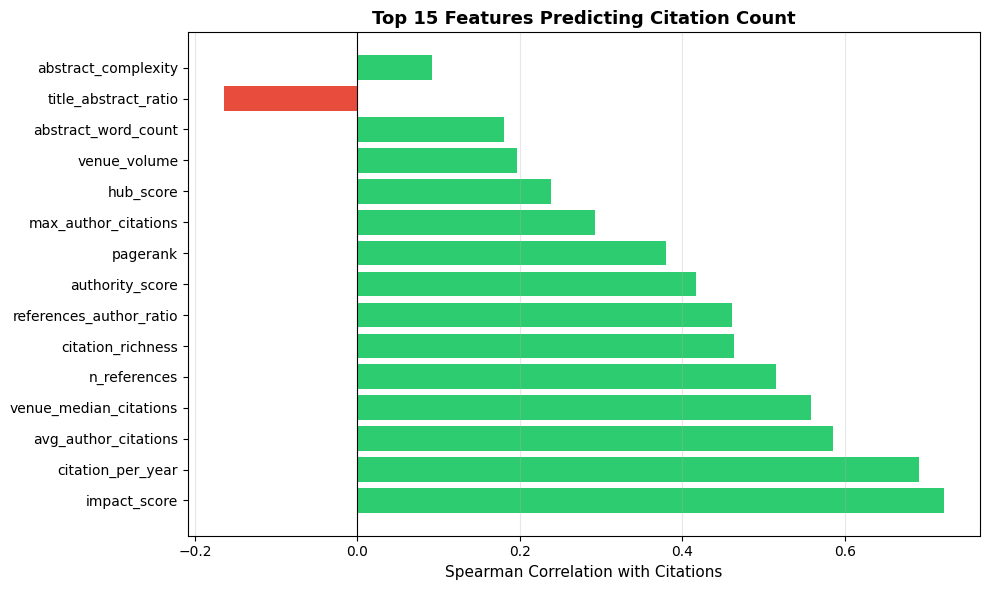


 FEATURE CORRELATION SUMMARY:
   Strong predictors (|corr| > 0.4): 8
   Moderate predictors (0.2 < |corr| <= 0.4): 3
   Weak predictors (|corr| <= 0.2): 10


In [43]:
# Load features into pandas for correlation analysis
df_features = con.sql("""
SELECT *
FROM papers_with_features
USING SAMPLE 50000
""").df()

# Filter where target > 0
df_features = df_features[df_features['target_variable'] > 0]

print(f"Loaded {len(df_features):,} papers for analysis")

# 1. AGGIUNTE LE GRAPH FEATURES ALLA LISTA
numeric_features = [
    'title_word_count', 'abstract_word_count', 'title_abstract_ratio',
    'title_complexity', 'abstract_complexity',
    'n_authors', 'avg_author_citations', 
    'max_author_citations',
    'n_references', 'references_author_ratio', 'citation_richness',
    'years_since_publication', 
    'citation_per_year', 'impact_score',
    'venue_median_citations', 'venue_volume', 'is_top_venue', 'is_english',
    'pagerank', 'hub_score', 'authority_score'
]

# Compute correlations
correlations = {}
for feat in numeric_features:
    if feat in df_features.columns:
        # 2. AGGIUNTO method='spearman' PER ROBUSTEZZA AGLI OUTLIER
        corr = df_features[[feat, 'target_variable']].corr(method='spearman').iloc[0, 1]
        correlations[feat] = corr

# Create dataframe and sort
corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
corr_df = corr_df.sort_values('Correlation', key=abs, ascending=False)

print("\nTOP 15 MOST CORRELATED FEATURES WITH CITATIONS (SPEARMAN):")
print(corr_df.head(15).to_string(index=False))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 6))
top_corr = corr_df.head(15)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_corr['Correlation']]
bars = ax.barh(range(len(top_corr)), top_corr['Correlation'], color=colors)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['Feature'], fontsize=10)
ax.set_xlabel('Spearman Correlation with Citations', fontsize=11)
ax.set_title('Top 15 Features Predicting Citation Count', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance summary
print("\n FEATURE CORRELATION SUMMARY:")
print(f"   Strong predictors (|corr| > 0.4): {len(corr_df[abs(corr_df['Correlation']) > 0.4])}")
print(f"   Moderate predictors (0.2 < |corr| <= 0.4): {len(corr_df[(abs(corr_df['Correlation']) > 0.2) & (abs(corr_df['Correlation']) <= 0.4)])}")
print(f"   Weak predictors (|corr| <= 0.2): {len(corr_df[abs(corr_df['Correlation']) <= 0.2])}")

##  FEATURE INTERACTIONS & SEGMENTATION

 VENUE TIER ANALYSIS
           target_variable                         citation_per_year  \
                     count    mean median      std              mean   
venue_tier                                                             
elite                  163  383.18  137.0  1326.05         79.739998   
high                  1232  156.06   62.0   441.13         16.379999   
low                  14560   14.08    8.0    47.92          2.710000   
medium               30736   39.04   22.0   155.52          7.280000   

           n_references  
                   mean  
venue_tier               
elite             29.51  
high              20.66  
low                6.52  
medium            13.72  


C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\3245083418.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features_sorted, x='venue_tier', y='target_variable', ax=axes[0], palette='Set2')
C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\3245083418.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_features_sorted, x='venue_tier', y='citation_per_year', ax=axes[1], palette='Set3')


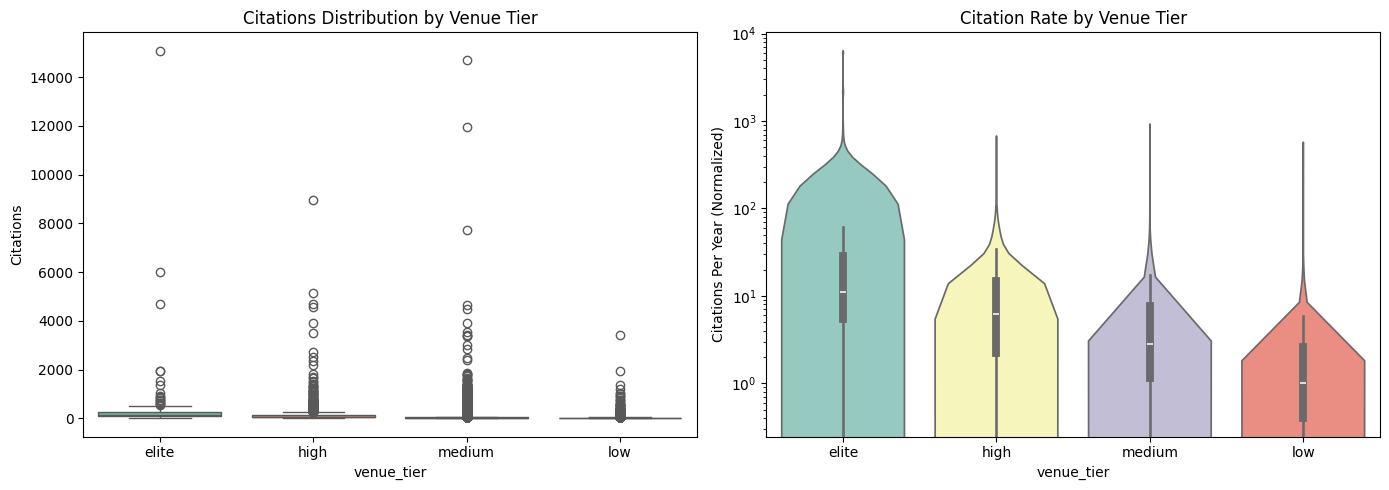


👥 AUTHOR REPUTATION TIERS
            target_variable               n_authors
                      count   mean median      mean
author_tier                                        
Emerging                825   2.58    2.0      1.97
Mid-Career             1831   8.55    8.0      2.29
Established           10864  17.13   13.0      2.69
Star                  32365  40.59   19.0      3.74


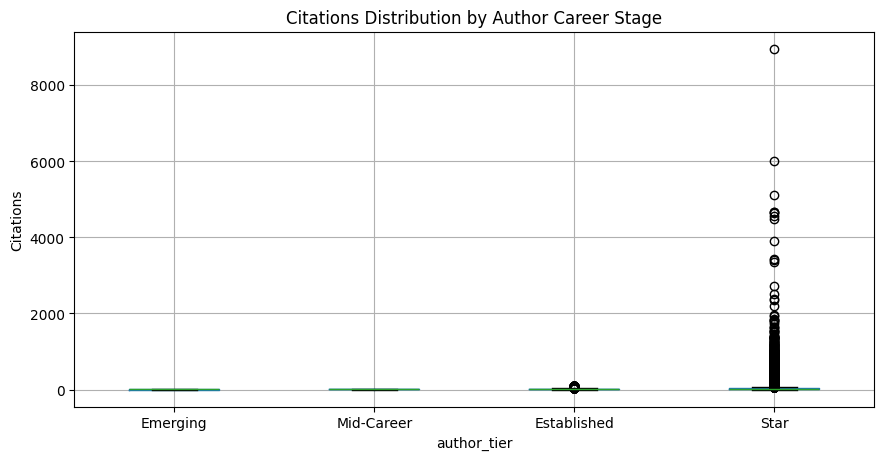


TEMPORAL TRENDS
                target_variable               citation_per_year
                          count   mean median              mean
publication_era                                                
2000-2009                  9101  47.85   18.0              2.56
2010-2019                 19599  35.37   17.0              4.27
2020+                     14029  22.83   15.0             13.03
pre-2000                   3962  53.22   21.0              1.69


C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\3245083418.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='publication_era', y='target_variable', ax=ax1, palette='Set1')
C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\3245083418.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp_norm, x='publication_era', y='citation_per_year', ax=ax2, palette='Set2')


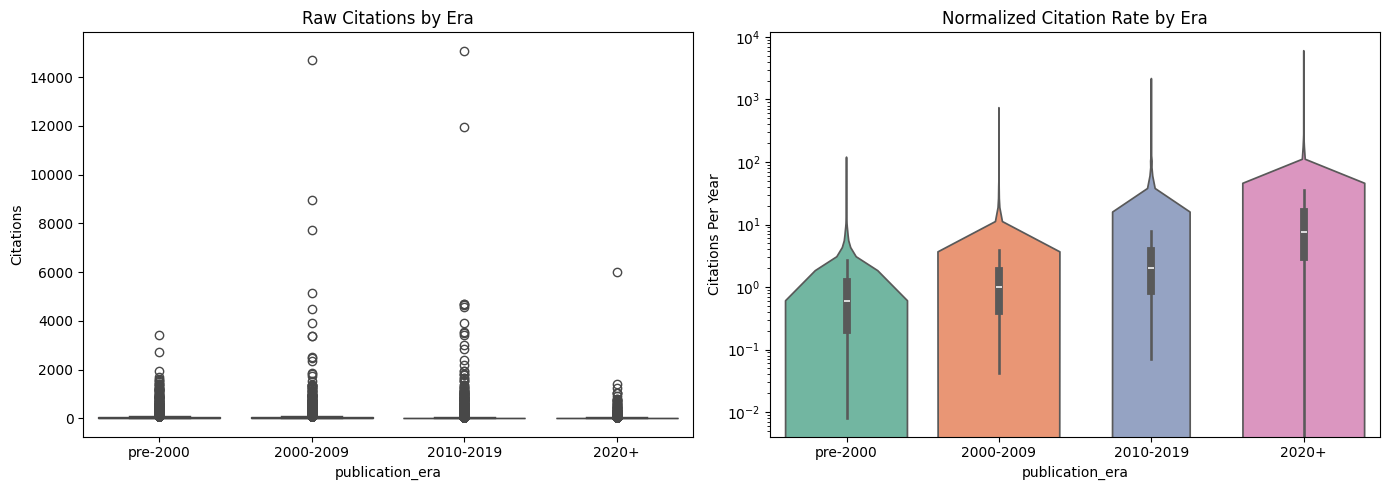


 VENUE x AUTHOR INTERACTION
                        count   mean
venue_tier author_tier              
elite      Emerging         1    4.0
           Mid-Career       1    1.0
           Established      7   41.1
           Star           145  314.3
high       Emerging         2    1.5
           Mid-Career      21    9.0
           Established    113   38.2
           Star          1011  159.7
low        Emerging       555    2.5
           Mid-Career     904    6.9
           Established   4185   10.4
           Star          8769   16.8
medium     Emerging       267    2.8
           Mid-Career     905   10.2
           Established   6559   21.0
           Star         22440   42.8

🕸️ PAGERANK TOPOLOGY TIERS
              target_variable                 pagerank
                        count     mean median     mean
pagerank_tier                                         
Q1 (Low)                23361  17.7920   12.0      0.0
Q2                      11657  19.5904   14.0      0.0
Q3

C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\3245083418.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features, x='pagerank_tier', y='target_variable', palette='magma')


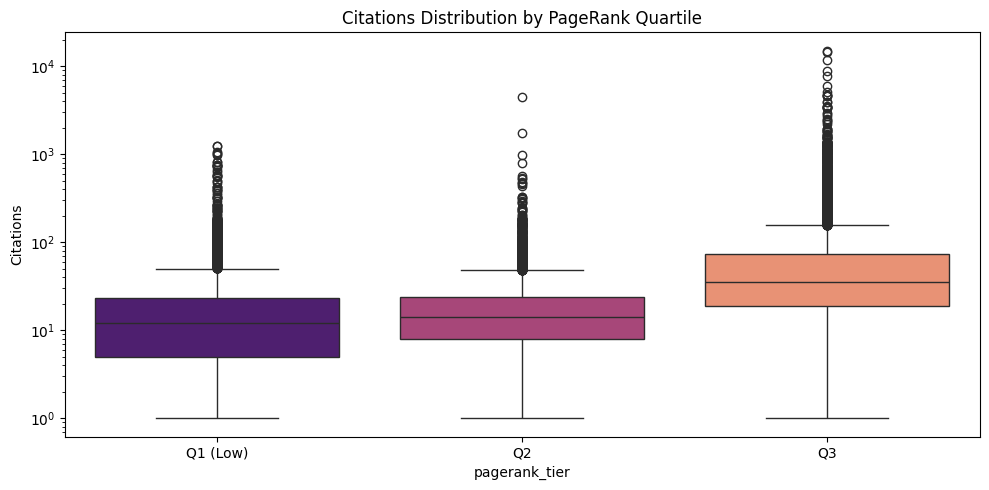

In [ ]:
# 1. Venue Tier Impact
print(" VENUE TIER ANALYSIS")
venue_analysis = df_features.groupby('venue_tier').agg({
    'target_variable': ['count', 'mean', 'median', 'std'],
    'citation_per_year': 'mean',
    'n_references': 'mean'
}).round(2)
print(venue_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
venue_order = ['elite', 'high', 'medium', 'low']
df_features_sorted = df_features.copy()
df_features_sorted['venue_tier'] = pd.Categorical(df_features_sorted['venue_tier'], categories=venue_order, ordered=True)

sns.boxplot(data=df_features_sorted, x='venue_tier', y='target_variable', ax=axes[0], palette='Set2')
axes[0].set_ylabel('Citations')
axes[0].set_title('Citations Distribution by Venue Tier')

sns.violinplot(data=df_features_sorted, x='venue_tier', y='citation_per_year', ax=axes[1], palette='Set3')
axes[1].set_ylabel('Citations Per Year (Normalized)')
axes[1].set_title('Citation Rate by Venue Tier')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# 2. Author Reputation Impact
print("\n👥 AUTHOR REPUTATION TIERS")
df_features['author_tier'] = pd.cut(df_features['max_author_citations'], 
                                     bins=[0, 5, 20, 100, 10000],
                                     labels=['Emerging', 'Mid-Career', 'Established', 'Star'])

# AGGIUNTO observed=True PER EVITARE IL PANDAS FUTURE WARNING
author_analysis = df_features.groupby('author_tier', observed=True).agg({
    'target_variable': ['count', 'mean', 'median'],
    'n_authors': 'mean'
}).round(2)
print(author_analysis)

df_features.boxplot(column='target_variable', by='author_tier', figsize=(10, 5))
plt.suptitle('')
plt.title('Citations Distribution by Author Career Stage')
plt.ylabel('Citations')
plt.show()

# 3. Era Analysis
print("\nTEMPORAL TRENDS")
era_analysis = df_features.groupby('publication_era').agg({
    'target_variable': ['count', 'mean', 'median'],
    'citation_per_year': 'mean'
}).round(2)
print(era_analysis)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

era_order = ['pre-2000', '2000-2009', '2010-2019', '2020+']
df_temp = df_features.copy()
df_temp['publication_era'] = pd.Categorical(df_temp['publication_era'], categories=era_order, ordered=True)
df_temp = df_temp.sort_values('publication_era')

sns.boxplot(data=df_temp, x='publication_era', y='target_variable', ax=ax1, palette='Set1')
ax1.set_ylabel('Citations')
ax1.set_title('Raw Citations by Era')

df_temp_norm = df_temp[df_temp['citation_per_year'].notna()]
sns.violinplot(data=df_temp_norm, x='publication_era', y='citation_per_year', ax=ax2, palette='Set2')
ax2.set_ylabel('Citations Per Year')
ax2.set_title('Normalized Citation Rate by Era')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

# 4. Complex Interactions
print("\n VENUE x AUTHOR INTERACTION")
# AGGIUNTO observed=True
interaction = df_features.groupby(['venue_tier', 'author_tier'], observed=True)['target_variable'].agg(['count', 'mean']).round(1)
print(interaction)

# ---------------------------------------------------------
# 5. GRAPH TOPOLOGY IMPACT 
# ---------------------------------------------------------
if 'pagerank' in df_features.columns:
    print("\nPAGERANK TOPOLOGY TIERS")
    
    # Dividiamo il PageRank in 4 quantili (Q1 basso, Q4 alto)
    pagerank_cut, pagerank_bins = pd.qcut(
    df_features['pagerank'], q=4, retbins=True, duplicates='drop'
    )
    
    n_bins = len(pagerank_bins) - 1
    tier_labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'][:n_bins]

    df_features['pagerank_tier'] = pd.qcut(
        df_features['pagerank'], q=4,
        labels=tier_labels,
        duplicates='drop'
    )
    
    pagerank_analysis = df_features.groupby('pagerank_tier', observed=True).agg({
        'target_variable': ['count', 'mean', 'median'],
        'pagerank': 'mean'
    }).round(4)
    print(pagerank_analysis)
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_features, x='pagerank_tier', y='target_variable', palette='magma')
    plt.title('Citations Distribution by PageRank Quartile')
    plt.ylabel('Citations')
    plt.yscale('log') # Usiamo log scale perché i top paper esplodono
    plt.tight_layout()
    plt.show()

Building comprehensive correlation matrix with ALL features...
Combined dataset shape: (33111, 25)
Features included: ['title_word_count', 'abstract_word_count', 'title_abstract_ratio', 'title_complexity', 'abstract_complexity', 'n_authors', 'avg_author_citations', 'max_author_citations', 'n_references', 'references_author_ratio', 'citation_richness', 'years_since_publication', 'citation_per_year', 'impact_score', 'venue_median_citations', 'venue_volume', 'is_top_venue', 'is_english', 'pagerank', 'hub_score', 'authority_score', 'target_variable', 'n_keywords', 'page_count', 'abstract_length']


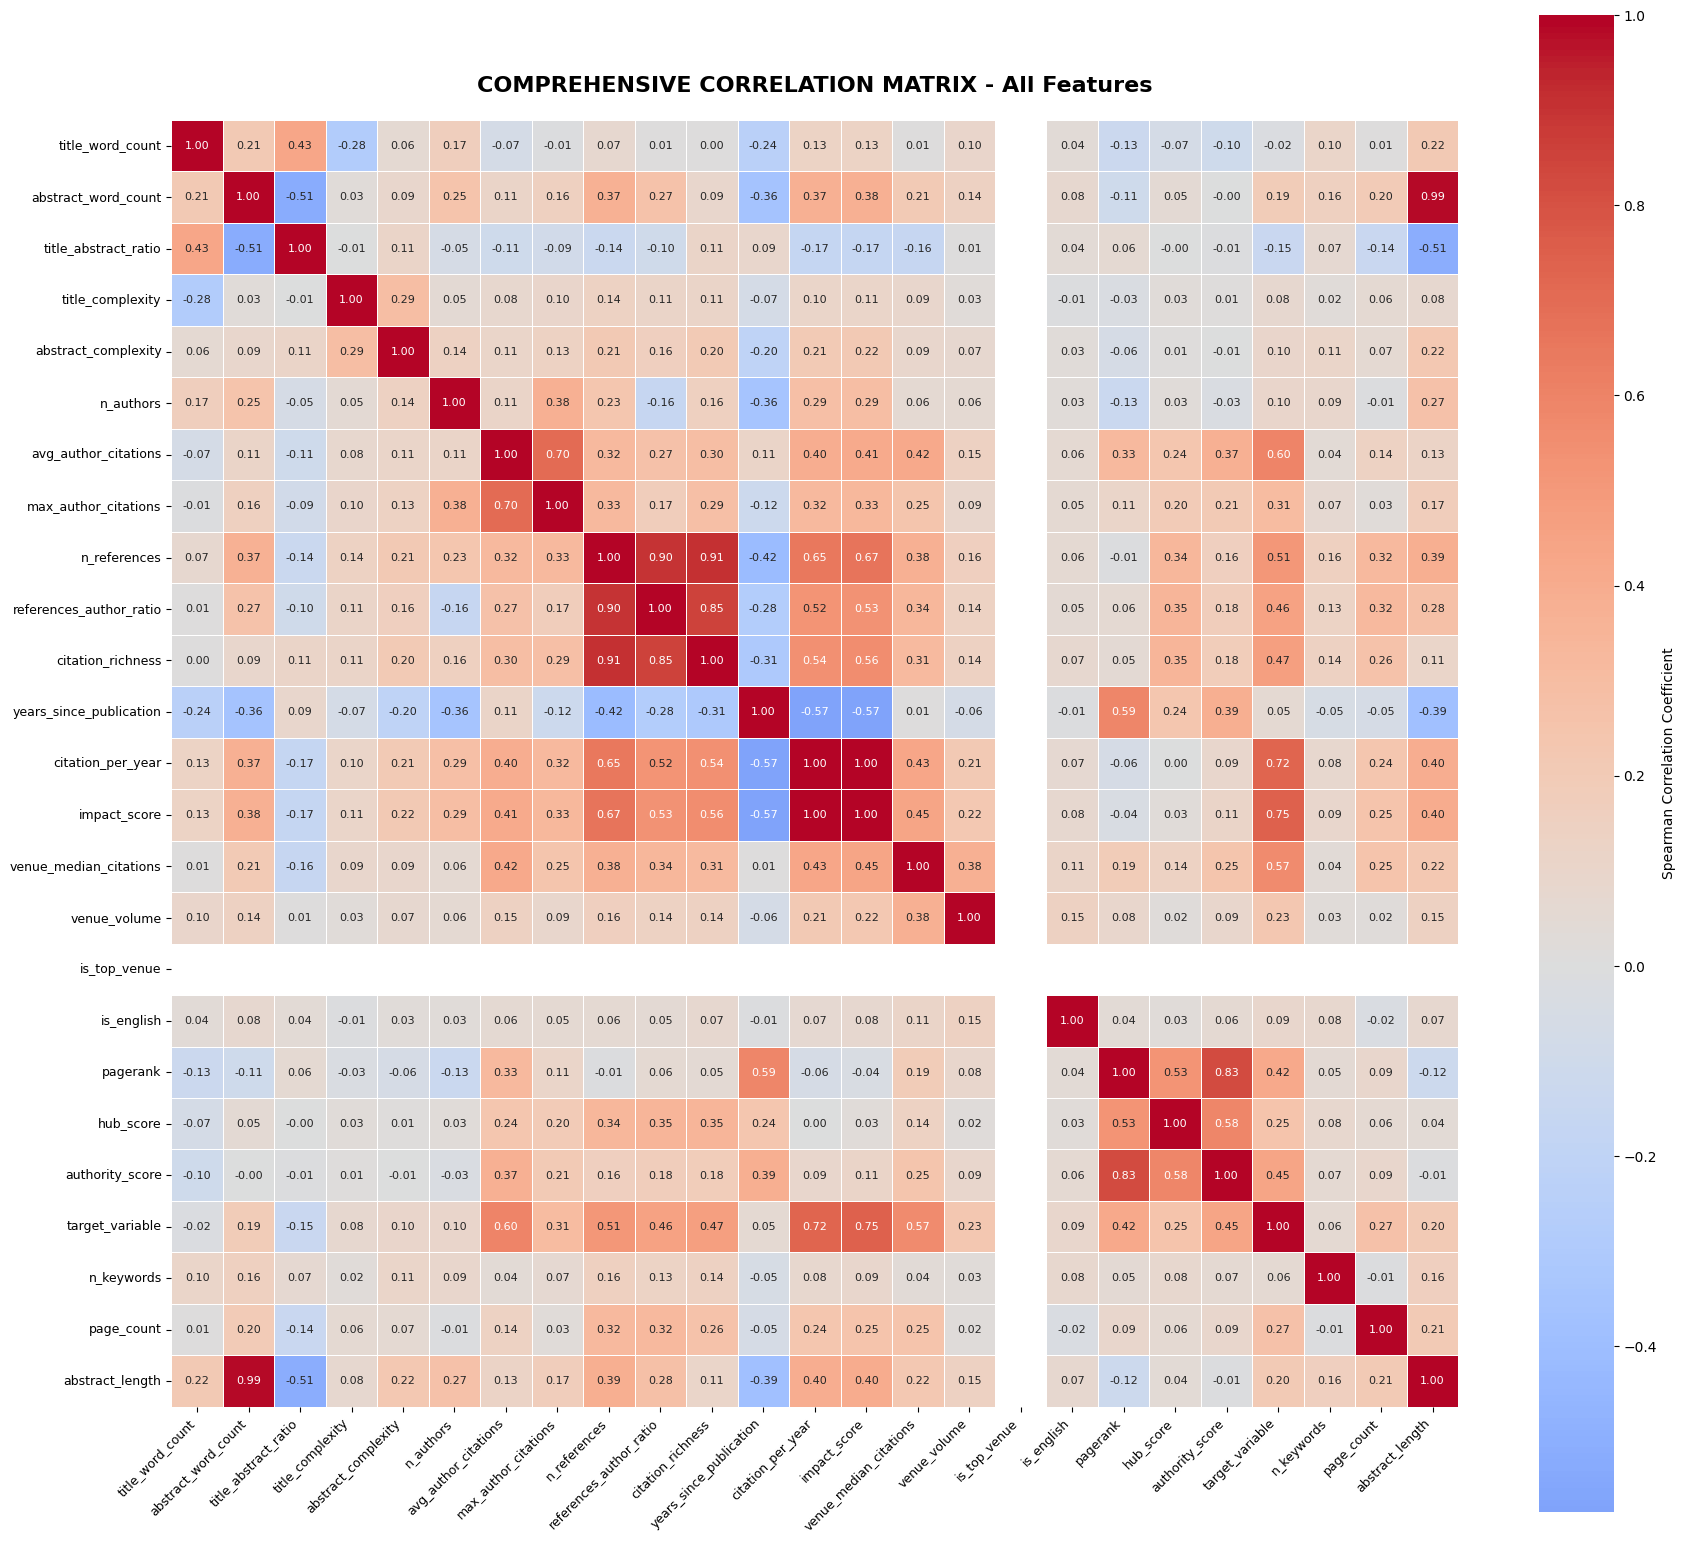


CORRELATION WITH TARGET VARIABLE (n_citation) - SPEARMAN

All features ranked by correlation strength with citations:
  ★★★ impact_score                   +0.7462
  ★★★ citation_per_year              +0.7239
  ★★★ avg_author_citations           +0.5973
  ★★★ venue_median_citations         +0.5679
  ★★★ n_references                   +0.5136
  ★★★ citation_richness              +0.4661
  ★★★ references_author_ratio        +0.4573
  ★★★ authority_score                +0.4464
  ★★★ pagerank                       +0.4173
  ★★ max_author_citations           +0.3077
  ★★ page_count                     +0.2701
  ★★ hub_score                      +0.2538
  ★★ venue_volume                   +0.2283
  ★★ abstract_length                +0.2015
  ★ abstract_word_count            +0.1891
  ★ title_abstract_ratio           -0.1487
  ★ abstract_complexity            +0.0990
  ★ n_authors                      +0.0963
  ★ is_english                     +0.0893
  ★ title_complexity               +0.076

In [46]:
# COMPREHENSIVE CORRELATION MATRIX - All Features Combined
print("Building comprehensive correlation matrix with ALL features...")

# Facciamo un'UNICA query per prendere tutte le feature perfettamente allineate!
df_combined = con.sql(f"""
    SELECT 
        pwf.title_word_count,
        pwf.abstract_word_count,
        pwf.title_abstract_ratio,
        pwf.title_complexity,
        pwf.abstract_complexity,
        pwf.n_authors,
        pwf.avg_author_citations,
        pwf.max_author_citations,
        pwf.n_references,
        pwf.references_author_ratio,
        pwf.citation_richness,
        pwf.years_since_publication,
        pwf.citation_per_year,
        pwf.impact_score,
        pwf.venue_median_citations,
        pwf.venue_volume,
        pwf.is_top_venue,
        pwf.is_english,
        pwf.pagerank,               -- <-- NUOVA
        pwf.hub_score,              -- <-- NUOVA
        pwf.authority_score,        -- <-- NUOVA
        pwf.target_variable,
        
        -- Feature aggiuntive estratte direttamente dal parquet originale
        ARRAY_LENGTH(p.keywords) AS n_keywords,
        TRY_CAST(p.page_end AS INT) - TRY_CAST(p.page_start AS INT) AS page_count,
        LENGTH(p.abstract) AS abstract_length
        
    FROM papers_with_features pwf
    JOIN read_parquet('{PARQUET}') p ON pwf.id = p.id
    WHERE pwf.target_variable IS NOT NULL 
      AND pwf.target_variable > 0
    USING SAMPLE 50000
""").df().dropna()

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Features included: {list(df_combined.columns)}")

# === FINAL COMPREHENSIVE CORRELATION MATRIX ===
# Calcoliamo la matrice usando SPEARMAN (più robusto per le citazioni)
correlation_matrix = df_combined.corr(method='spearman')

# Create large heatmap
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman Correlation Coefficient'},
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('COMPREHENSIVE CORRELATION MATRIX - All Features', 
             fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# === CORRELATION WITH TARGET ===
print("\n" + "="*80)
print("CORRELATION WITH TARGET VARIABLE (n_citation) - SPEARMAN")
print("="*80)

target_corr = correlation_matrix['target_variable'].drop('target_variable').sort_values(key=abs, ascending=False)
print("\nAll features ranked by correlation strength with citations:")
for feat, corr_val in target_corr.items():
    stars = "★★★" if abs(corr_val) > 0.4 else "★★" if abs(corr_val) > 0.2 else "★"
    print(f"  {stars} {feat:30} {corr_val:+.4f}")

# === FEATURE GROUPING INSIGHTS ===
print("\n" + "="*80)
print("FEATURE STRENGTH SUMMARY")
print("="*80)
strong = len(target_corr[abs(target_corr) > 0.4])
moderate = len(target_corr[(abs(target_corr) > 0.2) & (abs(target_corr) <= 0.4)])
weak = len(target_corr[abs(target_corr) <= 0.2])

print(f"Strong predictors (|r| > 0.40):      {strong:2d} features")
print(f"Moderate predictors (0.2 < |r| ≤ 0.40): {moderate:2d} features")
print(f"Weak predictors (|r| ≤ 0.20):        {weak:2d} features")
print(f"Total features analyzed:             {len(target_corr):2d} features")

# === INTER-FEATURE CORRELATIONS ===
print("\n" + "="*80)
print("HIGH INTER-FEATURE CORRELATIONS (|r| > 0.7) - Potential Multicollinearity")
print("="*80)

# Find highly correlated feature pairs (excluding diagonal and duplicates)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            feat1 = correlation_matrix.columns[i]
            feat2 = correlation_matrix.columns[j]
            corr_pairs.append((feat1, feat2, corr_val))

corr_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

if corr_pairs:
    for f1, f2, corr in corr_pairs[:15]:  # Top 15
        print(f"  {f1:25} <-> {f2:25} | r = {corr:+.4f}")
else:
    print("  No highly correlated feature pairs found (r > 0.7)")

print("\n" + "="*80)

## EXPORT & SUMMARY

Esportiamo i risultati del feature engineering per uso in modeling:

In [47]:
# Export complete feature set
con.sql("COPY papers_with_features TO 'papers_with_features.parquet' (FORMAT PARQUET)")
print(" Exported: papers_with_features.parquet")

# Export top cited papers
con.sql("""
COPY (
    SELECT * FROM papers_with_features
    ORDER BY target_variable DESC
    LIMIT 100
) TO 'top_cited_papers_features.parquet' (FORMAT PARQUET)
""")
print("Exported: top_cited_papers_features.parquet")

# --- CALCOLO INSIGHTS SULL'INTERO DATASET TRAMITE DUCKDB ---
# Molto più preciso e professionale che usare il sample Pandas!
total_papers = con.sql("SELECT COUNT(*) FROM papers_with_features").fetchone()[0]

elite_mean    = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE venue_tier = 'elite'").fetchone()[0] or 0
weak_mean     = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE venue_tier = 'low'").fetchone()[0] or 0

star_mean     = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE max_author_citations > 100").fetchone()[0] or 0
emerging_mean = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE max_author_citations <= 5").fetchone()[0] or 0

mature_mean   = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE year < 2000").fetchone()[0] or 0
recent_mean   = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE year >= 2020").fetchone()[0] or 0

# Generate summary report
print("\n" + "="*80)
print("FEATURE ENGINEERING FINAL REPORT")
print("="*80)

print(f"\nTotal Papers with Features: {total_papers:,}")
print(f"Total Features Created: {len(numeric_features)} numeric + 5 categorical")

print(f"\n TOP 5 PREDICTIVE FEATURES (Spearman):")
for i, row in corr_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']:30} | Corr: {row['Correlation']:+.4f}")

print(f"\n KEY INSIGHTS (Computed on the FULL dataset):")
print(f"   • Strong venues get {elite_mean:.0f} citations vs {weak_mean:.0f} for weak")
print(f"   • Papers with star authors: {star_mean:.0f} cit. vs {emerging_mean:.0f} for emerging")
print(f"   • Pre-2000 papers: {mature_mean:.0f} citations (mature)")
print(f"   • 2020+ papers: {recent_mean:.0f} citations (incomplete)")

# Aggiungiamo un insight per la tua nuova feature!
if 'pagerank' in corr_df['Feature'].values:
    pr_corr = corr_df[corr_df['Feature'] == 'pagerank']['Correlation'].iloc[0]
    print(f"   • Graph Topology: PageRank correlation with citations is {pr_corr:+.4f}!")

print("\n" + "="*80)

 Exported: papers_with_features.parquet
Exported: top_cited_papers_features.parquet

FEATURE ENGINEERING FINAL REPORT

Total Papers with Features: 6,729,828
Total Features Created: 21 numeric + 5 categorical

 TOP 5 PREDICTIVE FEATURES (Spearman):
   14. impact_score                   | Corr: +0.7219
   13. citation_per_year              | Corr: +0.6906
   7. avg_author_citations           | Corr: +0.5848
   15. venue_median_citations         | Corr: +0.5578
   9. n_references                   | Corr: +0.5150

 KEY INSIGHTS (Computed on the FULL dataset):
   • Strong venues get 385 citations vs 12 for weak
   • Papers with star authors: 44 cit. vs 2 for emerging
   • Pre-2000 papers: 58 citations (mature)
   • 2020+ papers: 20 citations (incomplete)
   • Graph Topology: PageRank correlation with citations is +0.3799!



In [48]:
# %pip install -q torch torchvision torchaudio
# %pip install -q torch-geometric scikit-learn

# TRAINING

In [49]:
# import os
# import torch
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from torch_geometric.utils import to_undirected


# REBUILD_SPLITS = False


# SPLIT_DIR   = "splits_gcn"
# NODE_PATH   = f"{SPLIT_DIR}/node_df.parquet"
# EDGE_PATH   = f"{SPLIT_DIR}/edge_df.parquet"
# SCALER_MEAN = f"{SPLIT_DIR}/scaler_mean.npy"
# SCALER_STD  = f"{SPLIT_DIR}/scaler_std.npy"


# num_cols = [
#     'n_authors', 'avg_author_citations', 'max_author_citations',
#     'n_references', 'references_author_ratio', 'citation_richness',
#     'years_since_publication', 'citation_per_year', 'impact_score',
#     'venue_median_citations', 'venue_volume', 'is_top_venue', 'is_english'
# ]


# if REBUILD_SPLITS or not os.path.exists(NODE_PATH):
#     os.makedirs(SPLIT_DIR, exist_ok=True)

#     sample_n = 15000

#     # 1. Sample nodes with a fixed seed for reproducibility
#     node_df = con.sql(f"""
#         SELECT id, year,
#                n_authors, avg_author_citations, max_author_citations,
#                n_references, references_author_ratio, citation_richness,
#                years_since_publication, citation_per_year, impact_score,
#                venue_median_citations, venue_volume, is_top_venue, is_english
#         FROM papers_with_features
#         WHERE id IS NOT NULL AND TRIM(id) <> ''
#           AND year IS NOT NULL
#         USING SAMPLE reservoir({sample_n})
#     """).df().reset_index(drop=True)

#     node_df['node_idx'] = node_df.index
#     con.register("sampled_papers", node_df[['id']])

#     # 2. Retrieve edges between sampled papers
#     edge_df = con.sql("""
#         SELECT p.id AS src_id, ref AS dst_id
#         FROM papers p
#         CROSS JOIN UNNEST(p."references") AS t(ref)
#         JOIN sampled_papers sp_src ON p.id  = sp_src.id
#         JOIN sampled_papers sp_dst ON ref   = sp_dst.id
#     """).df().drop_duplicates().reset_index(drop=True)

#     if edge_df.empty:
#         raise RuntimeError("No citations found among the sampled papers.")

#     edge_df = (edge_df
#         .merge(node_df[['id', 'node_idx']], left_on='src_id', right_on='id')
#         .rename(columns={'node_idx': 'src_idx'}).drop(columns=['id'])
#         .merge(node_df[['id', 'node_idx']], left_on='dst_id', right_on='id')
#         .rename(columns={'node_idx': 'dst_idx'}).drop(columns=['id'])
#     )

#     # 3. Temporal split on edges — prevents data leakage
#     edge_df = edge_df.merge(
#         node_df[['node_idx', 'year']].rename(columns={'node_idx': 'src_idx', 'year': 'src_year'}),
#         on='src_idx'
#     )

#     edge_df = edge_df.sort_values('src_year').reset_index(drop=True)
#     n         = len(edge_df)
#     train_end = int(n * 0.70)
#     val_end   = int(n * 0.85)

#     conditions = [
#         edge_df.index < train_end,
#         (edge_df.index >= train_end) & (edge_df.index < val_end),
#     ]
#     edge_df['split'] = np.select(conditions, ['train', 'val'], default='test')

#     print(f"Total edges: {n}")
#     print(edge_df['split'].value_counts().sort_index())
#     print(f"Max year train: {edge_df[edge_df.split=='train']['src_year'].max()}")
#     print(f"Min year val:   {edge_df[edge_df.split=='val']['src_year'].min()}")
#     print(f"Min year test:  {edge_df[edge_df.split=='test']['src_year'].min()}")

#     # 4. Normalisation — fit only on train nodes
#     train_node_ids = set(
#         edge_df[edge_df.split == 'train']['src_idx'].tolist() +
#         edge_df[edge_df.split == 'train']['dst_idx'].tolist()
#     )
#     train_mask = node_df['node_idx'].isin(train_node_ids)

#     features_raw = node_df[num_cols].to_numpy(dtype=float)
#     features_raw = np.nan_to_num(features_raw, nan=0.0, posinf=1e9, neginf=-1e9)

#     scaler = StandardScaler()
#     scaler.fit(features_raw[train_mask])
#     node_df[num_cols] = scaler.transform(features_raw)

#     # 5. Save
#     node_df.to_parquet(NODE_PATH, index=False)
#     edge_df.to_parquet(EDGE_PATH, index=False)
#     np.save(SCALER_MEAN, scaler.mean_)
#     np.save(SCALER_STD,  scaler.scale_)
#     print("Splits saved to", SPLIT_DIR)

# else:
#     print("Existing splits found, loading...")
#     node_df = pd.read_parquet(NODE_PATH)
#     edge_df = pd.read_parquet(EDGE_PATH)
#     print(f"Nodes: {len(node_df)} | Edges: {len(edge_df)}")
#     print(edge_df['split'].value_counts().sort_index())

## SPLIT

In [50]:
import pyarrow.parquet as pq
import pandas as pd

INPUT_FILE = "papers_with_features.parquet"

# Read schema without loading data
pf = pq.read_schema(INPUT_FILE)
print(f"Total columns: {len(pf.names)}\n")
print(f"{'Column':<45} {'Type':<20}")
print("-" * 65)
for name in pf.names:
    print(f"{name:<45} {str(pf.field(name).type):<20}")

# Load only first 3 rows to see actual values
print("\n--- Sample values (3 rows) ---")
sample = pd.read_parquet(INPUT_FILE).head(3)
for col in sample.columns:
    print(f"\n{col}: {sample[col].tolist()}")

Total columns: 36

Column                                        Type                
-----------------------------------------------------------------
id                                            string              
title                                         string              
references                                    list<element: string>
year                                          int64               
target_variable                               int64               
title_word_count                              int64               
abstract_word_count                           int64               
title_abstract_ratio                          float               
title_complexity                              float               
abstract_complexity                           float               
has_numbers_in_title                          int32               
has_numbers_in_abstract                       int32               
n_authors                                  

In [51]:
leaky_features = [
    # --- QUALITY & IMPACT (Looking to the future) ---
    "citation_per_year",
    "impact_score",
    "is_highly_cited_for_year",
    
    # --- AUTHOR METRICS (Focus on the author’s future career) ---
    "avg_author_citations",
    "max_author_citations",
    
    # --- VENUE METRICS (Focus on the venue’s overall popularity) ---
    "venue_median_citations",
    "venue_volume",         # <-- ADDED
    "is_top_venue",
    "venue_tier",
    
    # --- GRAPH METRICS (Use the topology of the citation network) ---
    "pagerank",             # <-- ADDED
    "hub_score",            # <-- ADDED
    "authority_score",      # <-- ADDED
]


In [52]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                        CONFIGURATION                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
INPUT_FILE = "papers_with_features.parquet"  # ← file con references
OUTPUT_DIR = "model_splits"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Check if split files already exist
split_files_exist = all([
    os.path.exists(f"{OUTPUT_DIR}/train.parquet"),
    os.path.exists(f"{OUTPUT_DIR}/val.parquet"),
    os.path.exists(f"{OUTPUT_DIR}/test.parquet")
])

if split_files_exist:
    print(f"Split files already exist in '{OUTPUT_DIR}'. Skipping creation.")
else:
    print("Loading dataset...")
    df = pd.read_parquet(INPUT_FILE)

    # ── 1. Temporal sorting ───────────────────────────────────────────────
    df = df.dropna(subset=["year"]).copy()
    df = df.sort_values("year").reset_index(drop=True)

    # Sequential node_idx 0..N-1 (required by PyTorch Geometric)
    df["node_idx"] = np.arange(len(df), dtype=np.int32)

    # ── 2. Feature definition (NO TARGET NODE FEATURE PER LA LINK PREDICTION)
    
    # Lista di feature da ignorare (leaky_features va definita prima, es. leaky_features = [])
    leaky_features = getattr(globals(), 'leaky_features', []) 

    # Colonne strutturali che NON devono essere usate come feature numeriche (non vanno scalate)
    non_feature_cols = [
        "id",
        "n_citation",
        "node_idx",
        "split",
        "year",
        "title",
        "abstract",
        "venue",
        "publication_era",
        "venue_tier",
        "references",       # ← FONDAMENTALE: contiene i link (edge_index)
        "target_variable"   # Lo includiamo qui solo per evitare che venga scalato se fosse rimasto nel dataframe per sbaglio
    ]

    exclude_cols = set(non_feature_cols + list(leaky_features))

    # Seleziona solo le colonne numeriche valide
    safe_numeric_features = [
        col for col in df.columns
        if col not in exclude_cols
        and pd.api.types.is_numeric_dtype(df[col])
    ]

    print(f"\nSafe numeric features selected ({len(safe_numeric_features)}):")
    for f in safe_numeric_features[:5]:
        print(f"  ✓  {f}")
    if len(safe_numeric_features) > 5:
        print("  ... e altre")

    # ── 3. Temporal splitting (Train <= 2020, Val 2021-2022, Test >= 2023) ───────────────
    df["split"] = ""
    
    df.loc[df["year"] <= 2020, "split"] = "train"
    df.loc[(df["year"] >= 2021) & (df["year"] <= 2022), "split"] = "val"
    df.loc[df["year"] >= 2023, "split"] = "test"

    print("\nSplit distribution:")
    print(df["split"].value_counts().reindex(["train", "val", "test"]))
    print(f"  Train years : {df.loc[df['split']=='train', 'year'].min()} – "
          f"{df.loc[df['split']=='train', 'year'].max()}")
    print(f"  Val years   : {df.loc[df['split']=='val',   'year'].min()} – "
          f"{df.loc[df['split']=='val',   'year'].max()}")
    print(f"  Test years  : {df.loc[df['split']=='test',  'year'].min()} – "
          f"{df.loc[df['split']=='test',  'year'].max()}")

    # ── 4. Strict scaling (fit ONLY on train, transform val/test) ────────
    X_train = df.loc[df["split"] == "train", safe_numeric_features].to_numpy()
    X_val   = df.loc[df["split"] == "val",   safe_numeric_features].to_numpy()
    X_test  = df.loc[df["split"] == "test",  safe_numeric_features].to_numpy()

    X_train = np.nan_to_num(X_train, nan=-999.0, posinf=0.0, neginf=0.0)
    X_val   = np.nan_to_num(X_val,   nan=-999.0, posinf=0.0, neginf=0.0)
    X_test  = np.nan_to_num(X_test,  nan=-999.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)

    # Cast a float64 per sicurezza e assegnazione
    for col in safe_numeric_features:
        df[col] = df[col].astype("float64")

    df.loc[df["split"] == "train", safe_numeric_features] = X_train_scaled
    df.loc[df["split"] == "val",   safe_numeric_features] = X_val_scaled
    df.loc[df["split"] == "test",  safe_numeric_features] = X_test_scaled

    # ── 5. Save files ─────────────────────────────────────────────────────
    
    # Colonne da mantenere nel file salvato (features + struttura + link)
    keep_cols = safe_numeric_features + [
        "id",
        "node_idx",
        "split",
        "year",
        "references",       # ← vitale per costruire gli edge_index (archi) successivamente
    ]

    # Sicurezza extra: rimuove eventuali colonne duplicate mantenendo l'ordine
    keep_cols = list(dict.fromkeys(keep_cols))

    print("\nSaving split files...")
    df.loc[df["split"] == "train", keep_cols].to_parquet(
        f"{OUTPUT_DIR}/train.parquet", index=False)
    df.loc[df["split"] == "val",   keep_cols].to_parquet(
        f"{OUTPUT_DIR}/val.parquet",   index=False)
    df.loc[df["split"] == "test",  keep_cols].to_parquet(
        f"{OUTPUT_DIR}/test.parquet",  index=False)

    np.save(f"{OUTPUT_DIR}/scaler_mean.npy",  scaler.mean_)
    np.save(f"{OUTPUT_DIR}/scaler_scale.npy", scaler.scale_)

    print(f"\n✓ Done. Files saved in '{OUTPUT_DIR}/'")
    print(f"   Node Features        : {len(safe_numeric_features)}")
    print(f"   Structural columns   : id, node_idx, split, year")
    print(f"   Graph Edges column   : references")
    print(f"   Scaler saved         : scaler_mean.npy, scaler_scale.npy")

Loading dataset...

Safe numeric features selected (28):
  ✓  title_word_count
  ✓  abstract_word_count
  ✓  title_abstract_ratio
  ✓  title_complexity
  ✓  abstract_complexity
  ... e altre

Split distribution:
split
train    4920858
val       767458
test     1041512
Name: count, dtype: int64
  Train years : 0 – 2020
  Val years   : 2021 – 2022
  Test years  : 2023 – 2027

Saving split files...

✓ Done. Files saved in 'model_splits/'
   Node Features        : 28
   Structural columns   : id, node_idx, split, year
   Graph Edges column   : references
   Scaler saved         : scaler_mean.npy, scaler_scale.npy


In [53]:
# import pyarrow.parquet as pq

# # Reread LOAD_COLS from the current schema of the new Parquet files
# pf_new = pq.read_schema(f"{OUTPUT_DIR}/train.parquet")
# LOAD_COLS = [c for c in pf_new.names if c not in {"split"}]

# print("LOAD_COLS updated:", LOAD_COLS)

# train_df = load_and_sample(f"{OUTPUT_DIR}/train.parquet", TRAIN_SAMPLE, LOAD_COLS)
# val_df   = load_and_sample(f"{OUTPUT_DIR}/val.parquet",   VAL_SAMPLE,   LOAD_COLS)
# test_df  = load_and_sample(f"{OUTPUT_DIR}/test.parquet",  TEST_SAMPLE,  LOAD_COLS)

# train_df

# CELLA DA ESEGUIRE PER CARICARE GLI SPLIT

In [54]:
import polars as pl

# Carica i file parquet come DataFrame Polars
train_df = pl.read_parquet('model_splits/train.parquet')
val_df = pl.read_parquet('model_splits/val.parquet')
test_df = pl.read_parquet('model_splits/test.parquet')

train_df

title_word_count,abstract_word_count,title_abstract_ratio,title_complexity,abstract_complexity,has_numbers_in_title,has_numbers_in_abstract,n_authors,avg_author_citations,max_author_citations,multi_authored,n_references,references_author_ratio,citation_richness,has_high_ref_count,years_since_publication,decade,is_recent,citation_per_year,is_highly_cited_for_year,impact_score,venue_median_citations,venue_volume,is_top_venue,is_english,pagerank,hub_score,authority_score,id,node_idx,split,year,references
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i32,str,i64,list[str]
-1.307657,-0.16144,-0.342573,0.991975,0.276941,0.0,0.0,-0.439039,-0.217704,-0.207977,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-0.096645,0.976734,-0.096337,-0.409409,-0.22979,-0.003313,-5.182193,-0.203694,-0.138997,-0.014738,"""5e54f1813a55acae32a25d83""",0,"""train""",0,[]
-0.774911,-1.368681,1.176274,-0.749234,0.064624,0.0,0.0,-0.054845,-0.141985,0.291158,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-0.096721,0.976734,-0.096358,1.010671,-0.223821,-0.003313,-5.182193,-0.203694,-0.138997,-0.014738,"""5fb3adec91e011e1ed1ef89f""",1,"""train""",0,[]
-1.041284,0.562904,-0.425641,0.450265,0.228003,0.0,0.0,1.481934,0.346494,6.320003,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-0.094697,0.976734,-0.095795,0.171533,-0.233564,-0.003313,-5.182193,0.112504,-0.138997,0.058364,"""5dce788a3a55ac9580a16242""",2,"""train""",0,[]
0.024208,-0.008947,-0.09869,-0.226871,0.134209,0.0,0.0,0.32935,-0.177738,-0.195947,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-0.096696,0.976734,-0.096351,-0.409409,-0.22979,-0.003313,-5.182193,-0.203694,-0.138997,-0.014738,"""5e54f1813a55acae32a25f40""",3,"""train""",0,[]
-2.373149,-0.479135,-0.658446,-1.445718,0.207225,0.0,0.0,-0.439039,-0.17432,-0.190194,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-0.096796,-1.02382,-0.096379,0.139258,-0.051781,-0.003313,-5.182193,-0.203694,-0.138997,-0.014738,"""62b132115aee126c0f9c1c6e""",4,"""train""",0,[]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.774911,-1.737207,-0.724406,-0.168831,-1.704685,0.0,0.0,0.32935,-0.231717,-0.185661,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,-0.905639,0.905639,2.403072,-0.090434,-1.02382,-0.090451,0.139258,0.058509,-0.003313,0.192969,-0.203694,-0.138997,-0.014738,"""601d1a4991e011d4d940f0ac""",4920853,"""train""",2020,[]
0.024208,-1.737207,-0.724406,0.179411,-1.704685,0.0,0.0,-0.054845,-0.171279,-0.186533,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,-0.905639,0.905639,2.403072,-0.096796,-1.02382,-0.096379,0.139258,0.058509,-0.003313,0.192969,-0.203694,-0.138997,-0.014738,"""601d1a4891e011d4d940f049""",4920854,"""train""",2020,[]
-1.041284,0.0673,-0.326806,1.26283,0.365449,0.0,0.0,-0.439039,-0.185666,-0.194204,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,-0.905639,0.905639,2.403072,0.030447,0.976734,0.022185,-0.248036,0.126228,-0.003313,0.192969,-0.024369,-0.138997,-0.010208,"""53908b6c20f70186a0dbd83d""",4920855,"""train""",2020,[]


## Preparation for LGBM and XGBoost

In [55]:
# Cell 0 — Shared data construction
# Run this once before LGBM and XGBoost cells.
# Produces: X_train_xgb, X_val_xgb, X_test_xgb, y_train_xgb, y_val_xgb, y_test_xgb, feature_names_xgb

import polars as pl
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt


# Fraction of edges to sample per split — reduce if RAM is tight
FRACTION_TRAIN = 0.20   # ~1.5M pairs
FRACTION_VAL   = 0.40   # ~0.9M pairs
FRACTION_TEST  = 0.50   # ~1.0M pairs

leaky_features = [
    # --- QUALITY & IMPACT (Looking to the future) ---
    "citation_per_year",
    "impact_score",
    "is_highly_cited_for_year",
    
    # --- AUTHOR METRICS (Focus on the author’s future career) ---
    "avg_author_citations",
    "max_author_citations",
    
    # --- VENUE METRICS (Focus on the venue’s overall popularity) ---
    "venue_median_citations",
    "venue_volume",         # <-- ADDED
    "is_top_venue",
    "venue_tier",
    
    # --- GRAPH METRICS (Use the topology of the citation network) ---
    "pagerank",             # <-- ADDED
    "hub_score",            # <-- ADDED
    "authority_score",      # <-- ADDED
]

# -- Section 0: Load pre-processed parquet splits -----------------------------

all_df = pl.concat([train_df, val_df, test_df]).sort("node_idx")

num_train_nodes = int(train_df["node_idx"].max()) + 1
num_val_nodes   = int(max(train_df["node_idx"].max(), val_df["node_idx"].max())) + 1
num_total_nodes = int(all_df["node_idx"].max()) + 1

print(f"  Train nodes: {num_train_nodes:,}")
print(f"  Val nodes  : {num_val_nodes:,}")
print(f"  Total nodes: {num_total_nodes:,}")

id_to_idx = all_df.select(["id", "node_idx"])


# -- Section 1: Node feature matrix -------------------------------------------
# Each split only sees features of nodes that exist at that point in time.
exclude_cols = ["id", "node_idx", "split", "year", "references", "target_variable"]
exclude_cols = list(dict.fromkeys(exclude_cols + leaky_features))
feature_cols = [c for c in all_df.columns if c not in exclude_cols]

print(f"\nBuilding feature matrix: {num_total_nodes:,} nodes × {len(feature_cols)} features...")
node_feats_full = all_df.select(feature_cols).to_numpy()
node_feats_full = np.nan_to_num(
    node_feats_full, nan=0.0, posinf=0.0, neginf=0.0
).astype(np.float32)

node_feats_train = node_feats_full[:num_train_nodes]
node_feats_val   = node_feats_full[:num_val_nodes]
node_feats_test  = node_feats_full[:num_total_nodes]


# -- Section 2: Positive edge extraction --------------------------------------
# Edge (src → dst) means "paper src cites paper dst".
# Edges pointing to future nodes are filtered out to prevent leakage.
def get_edge_index(split_df, max_dst_node):
    edges = (
        split_df.select(["node_idx", "references"])
        .explode("references")
        .drop_nulls()
        .rename({"node_idx": "src", "references": "target_id"})
    )
    edges = edges.join(id_to_idx, left_on="target_id", right_on="id", how="inner")
    edges = edges.rename({"node_idx": "dst"})
    edges = edges.filter(pl.col("dst") < max_dst_node)
    src_np = edges["src"].to_numpy()
    dst_np = edges["dst"].to_numpy()
    return torch.tensor(np.vstack([src_np, dst_np]), dtype=torch.long)


def subsample_edges(edge_index, fraction):
    if fraction >= 1.0:
        return edge_index
    n = max(1, int(edge_index.size(1) * fraction))
    return edge_index[:, torch.randperm(edge_index.size(1))[:n]]


print("Extracting positive edges...")
train_pos_full = get_edge_index(train_df, max_dst_node=num_train_nodes)
val_pos_full   = get_edge_index(val_df,   max_dst_node=num_val_nodes)
test_pos_full  = get_edge_index(test_df,  max_dst_node=num_total_nodes)

print("Applying subsampling...")
torch.manual_seed(42)
train_pos = subsample_edges(train_pos_full, FRACTION_TRAIN)
val_pos   = subsample_edges(val_pos_full,   FRACTION_VAL)
test_pos  = subsample_edges(test_pos_full,  FRACTION_TEST)

print(f"  Train: {train_pos.size(1):,} edges (out of {train_pos_full.size(1):,})")
print(f"  Val  : {val_pos.size(1):,} edges (out of {val_pos_full.size(1):,})")
print(f"  Test : {test_pos.size(1):,} edges (out of {test_pos_full.size(1):,})")


# -- Section 3: Temporal negative sampling ------------------------------------
# For each positive edge we sample one fake pair → balanced 50/50 dataset.
# Train negatives are guaranteed not to appear in val/test edge sets.
# Pairs are encoded as src * num_nodes + dst for O(1) lookup.
# def sample_negatives_fast(known_edge_index, num_nodes, target_count, oversample=2.0, seed=42):
#     rng = np.random.default_rng(seed)
#     src_k = known_edge_index[0].numpy().astype(np.int64)
#     dst_k = known_edge_index[1].numpy().astype(np.int64)
#     known_codes = set((src_k * num_nodes + dst_k).tolist())

#     collected_src, collected_dst = [], []
#     remaining = target_count

#     while remaining > 0:
#         n_sample = int(remaining * oversample)
#         src_rand = rng.integers(0, num_nodes, size=n_sample, dtype=np.int64)
#         dst_rand = rng.integers(0, num_nodes, size=n_sample, dtype=np.int64)
#         valid = src_rand != dst_rand
#         src_rand, dst_rand = src_rand[valid], dst_rand[valid]
#         codes = (src_rand * num_nodes + dst_rand).tolist()
#         mask = np.array([c not in known_codes for c in codes], dtype=bool)
#         src_rand, dst_rand = src_rand[mask], dst_rand[mask]
#         take = min(remaining, len(src_rand))
#         collected_src.append(src_rand[:take])
#         collected_dst.append(dst_rand[:take])
#         remaining -= take

#     src_out = np.concatenate(collected_src).astype(np.int64)
#     dst_out = np.concatenate(collected_dst).astype(np.int64)
#     return torch.tensor(np.vstack([src_out, dst_out]), dtype=torch.long)

def sample_negatives_hard(known_edge_index, num_nodes, target_count, years_array, max_gap=10, oversample=5.0, seed=42):
    rng = np.random.default_rng(seed)
    src_k = known_edge_index[0].numpy().astype(np.int64)
    dst_k = known_edge_index[1].numpy().astype(np.int64)
    known_codes = set((src_k * num_nodes + dst_k).tolist())

    collected_src, collected_dst = [], []
    remaining = target_count

    while remaining > 0:
        n_sample = int(remaining * oversample)
        # 1. Randomly pick source and destination nodes
        src_rand = rng.integers(0, num_nodes, size=n_sample, dtype=np.int64)
        dst_rand = rng.integers(0, num_nodes, size=n_sample, dtype=np.int64)
        
        # 2. HARD NEGATIVE CONSTRAINT: Ensure temporal validity and closeness
        src_years = years_array[src_rand]
        dst_years = years_array[dst_rand]
        valid_time = (dst_years <= src_years) & ((src_years - dst_years) <= max_gap)
        
        # 3. Remove self-loops
        valid = valid_time & (src_rand != dst_rand)
        src_rand, dst_rand = src_rand[valid], dst_rand[valid]
        
        # 4. Remove pairs that are actually real citations
        codes = (src_rand * num_nodes + dst_rand).tolist()
        mask = np.array([c not in known_codes for c in codes], dtype=bool)
        src_rand, dst_rand = src_rand[mask], dst_rand[mask]
        
        take = min(remaining, len(src_rand))
        collected_src.append(src_rand[:take])
        collected_dst.append(dst_rand[:take])
        remaining -= take

    src_out = np.concatenate(collected_src).astype(np.int64)
    dst_out = np.concatenate(collected_dst).astype(np.int64)
    return torch.tensor(np.vstack([src_out, dst_out]), dtype=torch.long)

# Extract the year array for fast numpy lookups during sampling
years_array = all_df["year"].to_numpy()

print("\nGenerating HARD negative samples (Max Gap: 10 years)...")

neg_train = sample_negatives_hard(
    train_pos_full, num_nodes=num_train_nodes,
    target_count=train_pos.size(1), years_array=years_array, seed=42
)
print(f"  neg_train: {neg_train.size(1):,}")

neg_val = sample_negatives_hard(
    torch.cat([train_pos_full, val_pos_full], dim=1),
    num_nodes=num_val_nodes,
    target_count=val_pos.size(1), years_array=years_array, seed=43
)
print(f"  neg_val  : {neg_val.size(1):,}")

neg_test = sample_negatives_hard(
    torch.cat([train_pos_full, val_pos_full, test_pos_full], dim=1),
    num_nodes=num_total_nodes,
    target_count=test_pos.size(1), years_array=years_array, seed=44
)
print(f"  neg_test : {neg_test.size(1):,}")



# -- Section 4: Tabular matrix construction -----------------------------------
# Each edge (src → dst) becomes a row of 50 values:
#   [feat_1_src ... feat_25_src | feat_1_dst ... feat_25_dst]
# Label 1 = real citation, 0 = fake pair.
def pairs_to_matrix(edge_index, node_feats):
    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()
    return np.hstack([node_feats[src], node_feats[dst]])


print("\nCreating tabular datasets...")

X_train_xgb = np.vstack([
    pairs_to_matrix(train_pos, node_feats_train),
    pairs_to_matrix(neg_train, node_feats_train),
])
y_train_xgb = np.concatenate([
    np.ones(train_pos.size(1),  dtype=np.int32),
    np.zeros(neg_train.size(1), dtype=np.int32),
])

X_val_xgb = np.vstack([
    pairs_to_matrix(val_pos, node_feats_val),
    pairs_to_matrix(neg_val, node_feats_val),
])
y_val_xgb = np.concatenate([
    np.ones(val_pos.size(1),  dtype=np.int32),
    np.zeros(neg_val.size(1), dtype=np.int32),
])

X_test_xgb = np.vstack([
    pairs_to_matrix(test_pos, node_feats_test),
    pairs_to_matrix(neg_test, node_feats_test),
])
y_test_xgb = np.concatenate([
    np.ones(test_pos.size(1),  dtype=np.int32),
    np.zeros(neg_test.size(1), dtype=np.int32),
])

feature_names_xgb = [f"src_{c}" for c in feature_cols] + [f"dst_{c}" for c in feature_cols]

print(f"  X_train : {X_train_xgb.shape}  ← {train_pos.size(1):,} positives + {neg_train.size(1):,} negatives")
print(f"  X_val   : {X_val_xgb.shape}  ← {val_pos.size(1):,} positives + {neg_val.size(1):,} negatives")
print(f"  X_test  : {X_test_xgb.shape}  ← {test_pos.size(1):,} positives + {neg_test.size(1):,} negatives")

  Train nodes: 4,920,858
  Val nodes  : 5,688,316
  Total nodes: 6,729,828

Building feature matrix: 6,729,828 nodes × 17 features...
Extracting positive edges...
Applying subsampling...
  Train: 9,223,809 edges (out of 46,119,048)
  Val  : 5,165,524 edges (out of 12,913,811)
  Test : 7,239,049 edges (out of 14,478,099)

Generating HARD negative samples (Max Gap: 10 years)...
  neg_train: 9,223,809
  neg_val  : 5,165,524
  neg_test : 7,239,049

Creating tabular datasets...
  X_train : (18447618, 34)  ← 9,223,809 positives + 9,223,809 negatives
  X_val   : (10331048, 34)  ← 5,165,524 positives + 5,165,524 negatives
  X_test  : (14478098, 34)  ← 7,239,049 positives + 7,239,049 negatives


# MODEL 1 --> LGBM

Training LightGBM with Early Stopping on Validation Set...
Training stopped at iteration : 94
Training time                 : 70.8s

Evaluating on the Test Set...


c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- LightGBM Link Prediction (Test Split) ---
ROC-AUC : 0.8586
PR-AUC  : 0.8585
Brier   : 0.1548

Classification report:
              precision    recall  f1-score   support

           0     0.7514    0.8066    0.7780   7239049
           1     0.7912    0.7331    0.7611   7239049

    accuracy                         0.7698  14478098
   macro avg     0.7713    0.7698    0.7695  14478098
weighted avg     0.7713    0.7698    0.7695  14478098



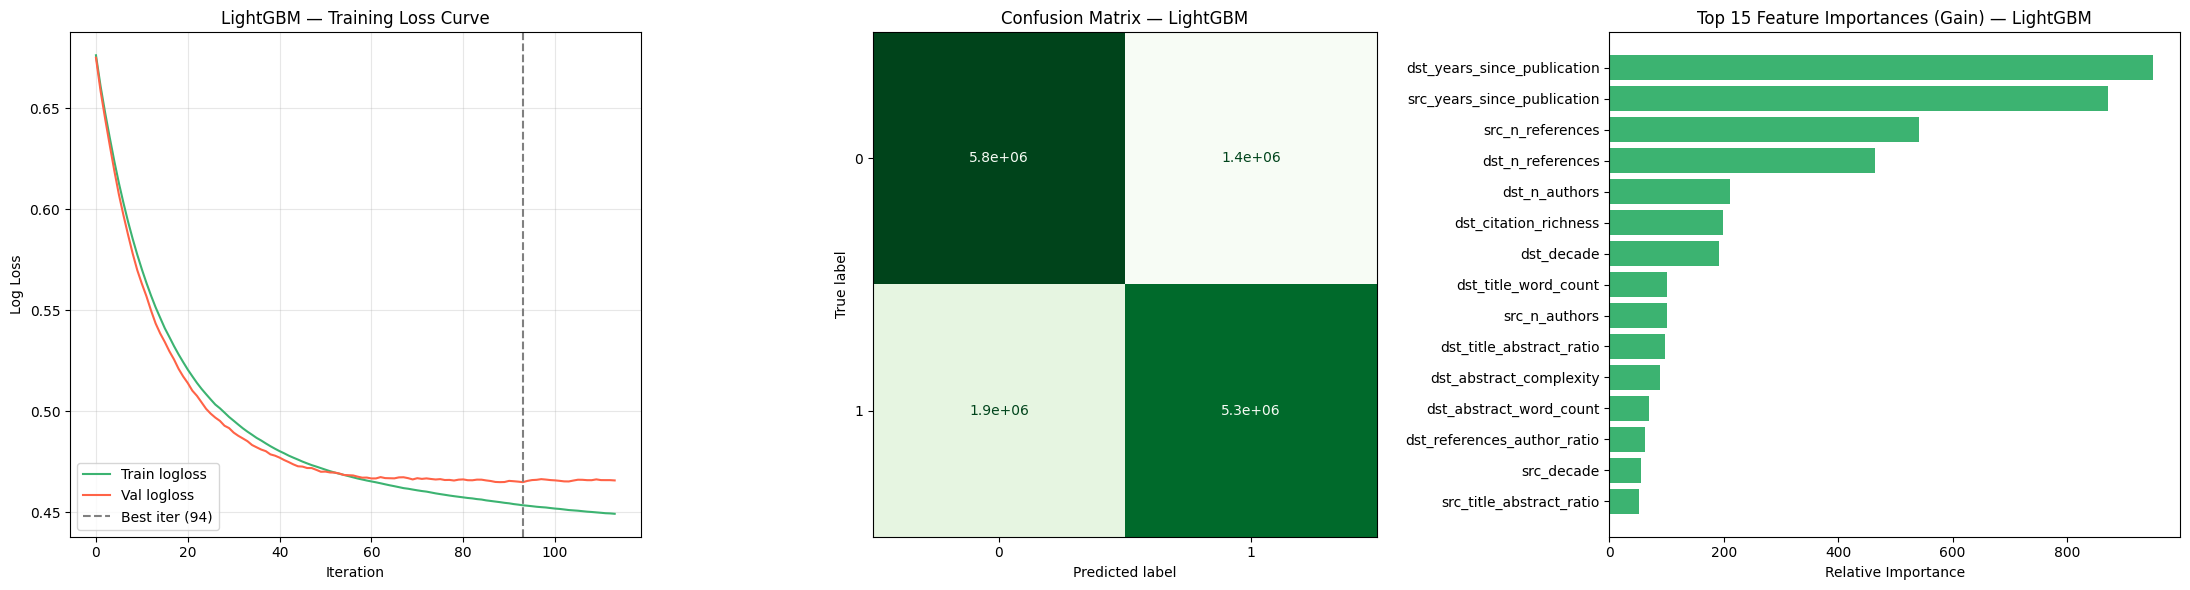

,feature,gain
30,dst_years_since_publication,950
13,src_years_since_publication,872
9,src_n_references,541
26,dst_n_references,464
24,dst_n_authors,211
28,dst_citation_richness,198
31,dst_decade,191
17,dst_title_word_count,100
7,src_n_authors,100
19,dst_title_abstract_ratio,98


In [56]:
import lightgbm as lgb
import time
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

assert 'X_train_xgb' in dir(), "Esegui prima la cella di costruzione dei dati (sezioni 0-4)!"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    LIGHTGBM — LINK PREDICTION                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("Training LightGBM with Early Stopping on Validation Set...")
scale_pos_weight_lgbm = (y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=6,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.9,
    min_child_samples=20,
    reg_lambda=1.0,
    objective="binary",
    metric="binary_logloss",
    scale_pos_weight=scale_pos_weight_lgbm,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# Callback per salvare la loss durante il training
lgbm_evals_result = {}

t0 = time.time()
lgbm_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_val_xgb, y_val_xgb)],
    eval_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=0),
        lgb.record_evaluation(lgbm_evals_result),
    ],
)
lgbm_train_time = time.time() - t0
print(f"Training stopped at iteration : {lgbm_model.best_iteration_}")
print(f"Training time                 : {lgbm_train_time:.1f}s")


# --- Evaluation ---
print("\nEvaluating on the Test Set...")
lgbm_probs = lgbm_model.predict_proba(X_test_xgb)[:, 1]
lgbm_preds = (lgbm_probs >= 0.5).astype(int)

print("\n--- LightGBM Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, lgbm_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, lgbm_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, lgbm_probs):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, lgbm_preds, digits=4))


# --- Plot: Loss curve + Confusion Matrix + Feature Importance ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Subplot 1: Loss curve
train_loss = lgbm_evals_result["train"]["binary_logloss"]
val_loss   = lgbm_evals_result["val"]["binary_logloss"]
axes[0].plot(train_loss, label="Train logloss", color="mediumseagreen", linewidth=1.5)
axes[0].plot(val_loss,   label="Val logloss",   color="tomato",         linewidth=1.5)
axes[0].axvline(lgbm_model.best_iteration_ - 1, color="gray", linestyle="--", label=f"Best iter ({lgbm_model.best_iteration_})")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log Loss")
axes[0].set_title("LightGBM — Training Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Confusion Matrix
cm_lgbm = confusion_matrix(y_test_xgb, lgbm_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_lgbm).plot(cmap="Greens", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — LightGBM")

# Subplot 3: Feature Importance
lgbm_importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "gain": lgbm_model.feature_importances_,
}).sort_values("gain", ascending=False).head(15)

axes[2].barh(lgbm_importance_df["feature"][::-1], lgbm_importance_df["gain"][::-1], color="mediumseagreen")
axes[2].set_title("Top 15 Feature Importances (Gain) — LightGBM")
axes[2].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

display(lgbm_importance_df.head(15))

# MODEL 2 --> Random Forest

Training Random Forest...
Training completed in : 4270.4s

Evaluating on the Test Set...

--- Random Forest Link Prediction (Test Split) ---
ROC-AUC : 0.8545
PR-AUC  : 0.8539
Brier   : 0.1574

Classification report:
              precision    recall  f1-score   support

           0     0.7420    0.8104    0.7747   7239049
           1     0.7912    0.7182    0.7529   7239049

    accuracy                         0.7643  14478098
   macro avg     0.7666    0.7643    0.7638  14478098
weighted avg     0.7666    0.7643    0.7638  14478098



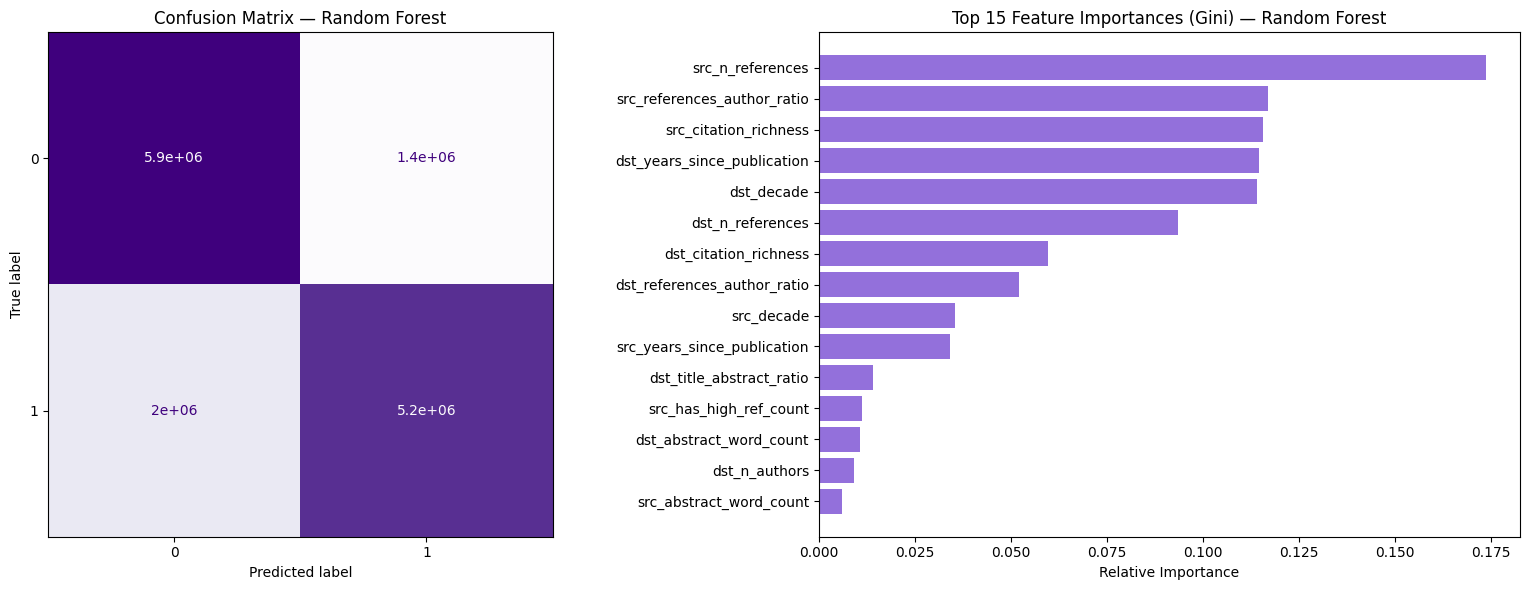

,feature,importance
9,src_n_references,0.173744
10,src_references_author_ratio,0.116880
11,src_citation_richness,0.115693
30,dst_years_since_publication,0.114551
31,dst_decade,0.114011
26,dst_n_references,0.093438
28,dst_citation_richness,0.059530
27,dst_references_author_ratio,0.051994
14,src_decade,0.035555
13,src_years_since_publication,0.034005


In [57]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

assert 'X_train_xgb' in dir(), "Run the data construction cell first (sections 0–4)!"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    RANDOM FOREST — LINK PREDICTION                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=500,          
    max_depth=15,              
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample", 
    random_state=42,
    n_jobs=-1,                 # Usa tutti i core disponibili
)

t0 = time.time()
rf_model.fit(X_train_xgb, y_train_xgb)
rf_train_time = time.time() - t0

print(f"Training completed in : {rf_train_time:.1f}s")


# --- Evaluation ---
print("\nEvaluating on the Test Set...")
rf_probs = rf_model.predict_proba(X_test_xgb)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print("\n--- Random Forest Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, rf_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, rf_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, rf_probs):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, rf_preds, digits=4))


# --- Plot: Confusion Matrix + Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Confusion Matrix
cm_rf = confusion_matrix(y_test_xgb, rf_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap="Purples", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Random Forest")

# Subplot 2: Feature Importance
# RF usa nativamente la Gini Impurity Decrease per calcolare l'importanza
rf_importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False).head(15)

axes[1].barh(rf_importance_df["feature"][::-1], rf_importance_df["importance"][::-1], color="mediumpurple")
axes[1].set_title("Top 15 Feature Importances (Gini) — Random Forest")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

display(rf_importance_df.head(15))

# MODEL 3 --> MLP

Using device: cuda
Training MLP with Early Stopping on Validation Set...
  Epoch  1 | train=0.4474  val=0.4435 ✓
  Epoch  2 | train=0.4341  val=0.4388 ✓
  Epoch  3 | train=0.4323  val=0.4386 ✓
  Epoch  4 | train=0.4318  val=0.4717
  Epoch  5 | train=0.4313  val=0.4464
  Epoch  6 | train=0.4313  val=0.4370 ✓
  Epoch  7 | train=0.4312  val=0.4249 ✓
  Epoch  8 | train=0.4310  val=0.4334
  Epoch  9 | train=0.4309  val=0.4453
  Epoch 10 | train=0.4307  val=0.4778
  Epoch 11 | train=0.4279  val=0.4342
  Epoch 12 | train=0.4277  val=0.4561
Early stopping at epoch 12.
Best epoch: 7  |  Training time: 3776.6s

--- MLP Link Prediction (Test Split) ---
ROC-AUC : 0.8825
PR-AUC  : 0.8721
Brier   : 0.1425

Classification report:
              precision    recall  f1-score   support

           0     0.8391    0.7558    0.7953   7239049
           1     0.7778    0.8551    0.8146   7239049

    accuracy                         0.8054  14478098
   macro avg     0.8085    0.8054    0.8049  14478098
wei

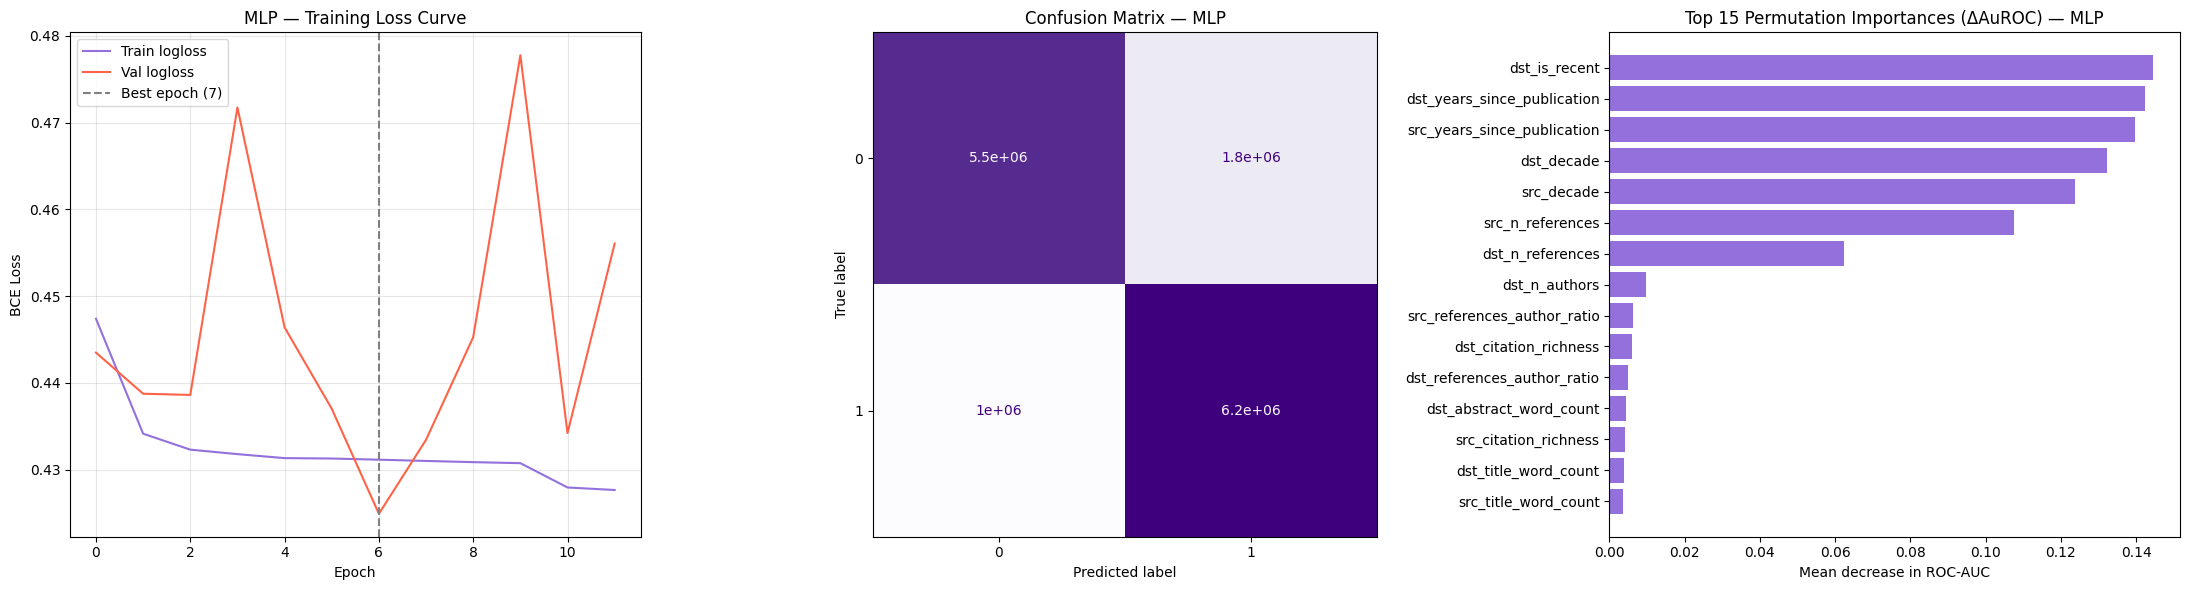

,feature,importance
32,dst_is_recent,0.144462
30,dst_years_since_publication,0.142275
13,src_years_since_publication,0.139619
31,dst_decade,0.132379
14,src_decade,0.123849
9,src_n_references,0.107626
26,dst_n_references,0.062378
24,dst_n_authors,0.009647
10,src_references_author_ratio,0.006207
28,dst_citation_richness,0.005937



══════════════ FAIR COMPARISON ══════════════
Metric           LightGBM        MLP
────────────────────────────────────
ROC-AUC            0.8586     0.8825
PR-AUC             0.8585     0.8721
Brier              0.1548     0.1425
Train time          70.8s    3776.6s
Best iter              94          7


In [58]:
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'X_train_xgb' in dir(), "Run the data construction cell first!"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                        MLP — LINK PREDICTION                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 4096
MAX_EPOCHS = 50
PATIENCE   = 5
LR         = 1e-3
print(f"Using device: {DEVICE}")


# --- 1. Model definition -----------------------------------------------------
class LinkMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# --- 2. DataLoaders ----------------------------------------------------------
def make_loader(X, y, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

train_loader = make_loader(X_train_xgb, y_train_xgb, shuffle=True)
val_loader   = make_loader(X_val_xgb,   y_val_xgb,   shuffle=False)
test_loader  = make_loader(X_test_xgb,  y_test_xgb,  shuffle=False)


# --- 3. Training loop --------------------------------------------------------
in_dim    = X_train_xgb.shape[1]
mlp_model = LinkMLP(in_dim).to(DEVICE)

pos_weight = torch.tensor(
    [(y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)],
    dtype=torch.float32,
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

mlp_train_losses, mlp_val_losses = [], []
best_val_loss  = float("inf")
best_state     = None
epochs_no_improve = 0

print("Training MLP with Early Stopping on Validation Set...")
t0 = time.time()

for epoch in range(1, MAX_EPOCHS + 1):

    # -- train --
    mlp_model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(yb)
    train_loss = epoch_loss / len(y_train_xgb)

    # -- validate --
    mlp_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(mlp_model(xb), yb).item() * len(yb)
    val_loss /= len(y_val_xgb)

    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.cpu().clone() for k, v in mlp_model.state_dict().items()}
        epochs_no_improve = 0
        tag = " ✓"
    else:
        epochs_no_improve += 1
        tag = ""

    print(f"  Epoch {epoch:>2} | train={train_loss:.4f}  val={val_loss:.4f}{tag}")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

mlp_train_time = time.time() - t0
best_epoch     = epoch - epochs_no_improve
print(f"Best epoch: {best_epoch}  |  Training time: {mlp_train_time:.1f}s")

# Restore best weights
mlp_model.load_state_dict(best_state)


# --- 4. Inference ------------------------------------------------------------
def predict_proba(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(DEVICE))
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)

mlp_probs = predict_proba(mlp_model, test_loader)
mlp_preds = (mlp_probs >= 0.5).astype(int)


# --- 5. Evaluation -----------------------------------------------------------
print("\n--- MLP Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb,  mlp_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, mlp_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, mlp_probs):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, mlp_preds, digits=4))


# --- 6. Permutation importance (on a 5k subsample for speed) ----------------
print("Computing permutation importance (subsample)...")
N_IMP = min(5000, len(X_test_xgb))
rng   = np.random.default_rng(42)
idx   = rng.choice(len(X_test_xgb), size=N_IMP, replace=False)
X_sub, y_sub = X_test_xgb[idx], y_test_xgb[idx]

# Wrap MLP as a sklearn-compatible scorer
def mlp_roc_score(X, y):
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    p = predict_proba(mlp_model, loader)
    return roc_auc_score(y, p)

base_score = mlp_roc_score(X_sub, y_sub)
n_features = X_sub.shape[1]
imp_scores  = np.zeros(n_features)

for i in range(n_features):
    X_perm        = X_sub.copy()
    X_perm[:, i]  = rng.permutation(X_perm[:, i])
    imp_scores[i] = base_score - mlp_roc_score(X_perm, y_sub)

mlp_importance_df = (
    pd.DataFrame({"feature": feature_names_xgb, "importance": imp_scores})
    .sort_values("importance", ascending=False)
    .head(15)
)


# --- 7. Plots ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Loss curve
axes[0].plot(mlp_train_losses, label="Train logloss", color="mediumpurple", linewidth=1.5)
axes[0].plot(mlp_val_losses,   label="Val logloss",   color="tomato",       linewidth=1.5)
axes[0].axvline(best_epoch - 1, color="gray", linestyle="--",
                label=f"Best epoch ({best_epoch})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("MLP — Training Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix
cm_mlp = confusion_matrix(y_test_xgb, mlp_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_mlp).plot(
    cmap="Purples", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — MLP")

# Feature importance
axes[2].barh(
    mlp_importance_df["feature"][::-1],
    mlp_importance_df["importance"][::-1],
    color="mediumpurple",
)
axes[2].set_title("Top 15 Permutation Importances (ΔAuROC) — MLP")
axes[2].set_xlabel("Mean decrease in ROC-AUC")

plt.tight_layout()
plt.show()

display(mlp_importance_df)


# --- 8. Fair comparison (update to include MLP) ------------------------------
print("\n══════════════ FAIR COMPARISON ══════════════")
print(f"{'Metric':<14} {'LightGBM':>10} {'MLP':>10}")
print(f"{'─'*36}")
print(f"{'ROC-AUC':<14} {roc_auc_score(y_test_xgb, lgbm_probs):>10.4f} {roc_auc_score(y_test_xgb, mlp_probs):>10.4f}")
print(f"{'PR-AUC':<14} {average_precision_score(y_test_xgb, lgbm_probs):>10.4f} {average_precision_score(y_test_xgb, mlp_probs):>10.4f}")
print(f"{'Brier':<14} {brier_score_loss(y_test_xgb, lgbm_probs):>10.4f} {brier_score_loss(y_test_xgb, mlp_probs):>10.4f}")
print(f"{'Train time':<14} {lgbm_train_time:>9.1f}s {mlp_train_time:>9.1f}s")
print(f"{'Best iter':<14} {lgbm_model.best_iteration_:>10} {best_epoch:>10}")

# COMPARISON FOR CLASSIC FEATURES

c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



═════════════════════════════════════════════════════════════════════════════════════
                              ULTIMATE FAIR COMPARISON                               
═════════════════════════════════════════════════════════════════════════════════════
Metric          |   LightGBM    | MLP (PyTorch)
─────────────────────────────────────────────────────────────────────────────────────
ROC-AUC         |        0.8586 |        0.8825
PR-AUC          |        0.8585 |        0.8721
Brier           |        0.1548 |        0.1425
Train time (s)  |          70.8 |        3776.6
═════════════════════════════════════════════════════════════════════════════════════



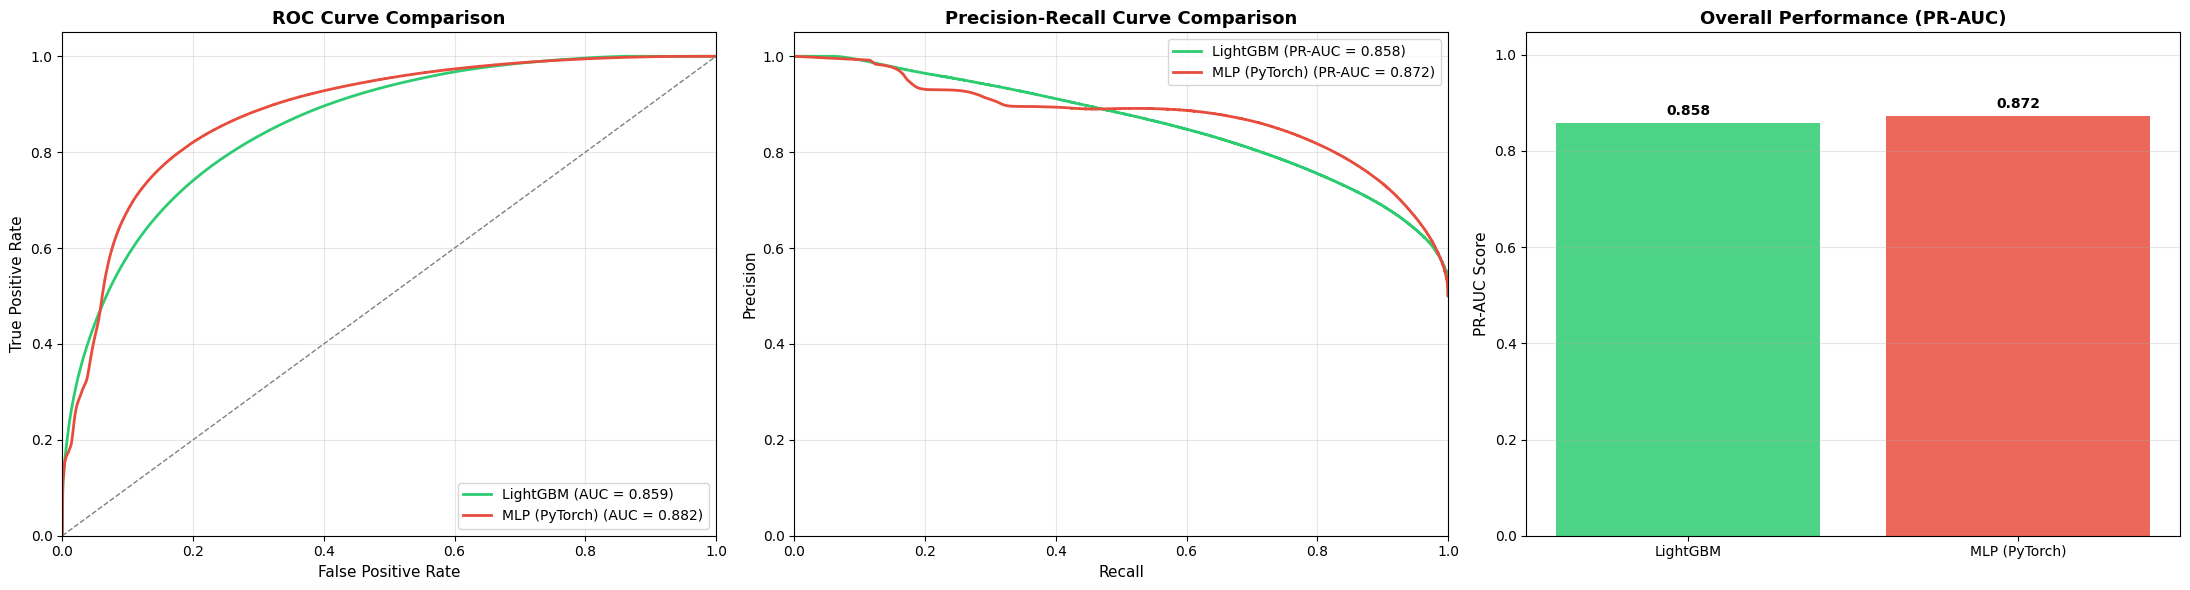


═════════════════════════════════════════════════════════════════════════════════════
                       SHAP EXPLAINABILITY (Tree-Based Models)                       
═════════════════════════════════════════════════════════════════════════════════════
Computing SHAP values on a 1k sample to optimize performance...

>> Generating SHAP plot for LightGBM...


c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


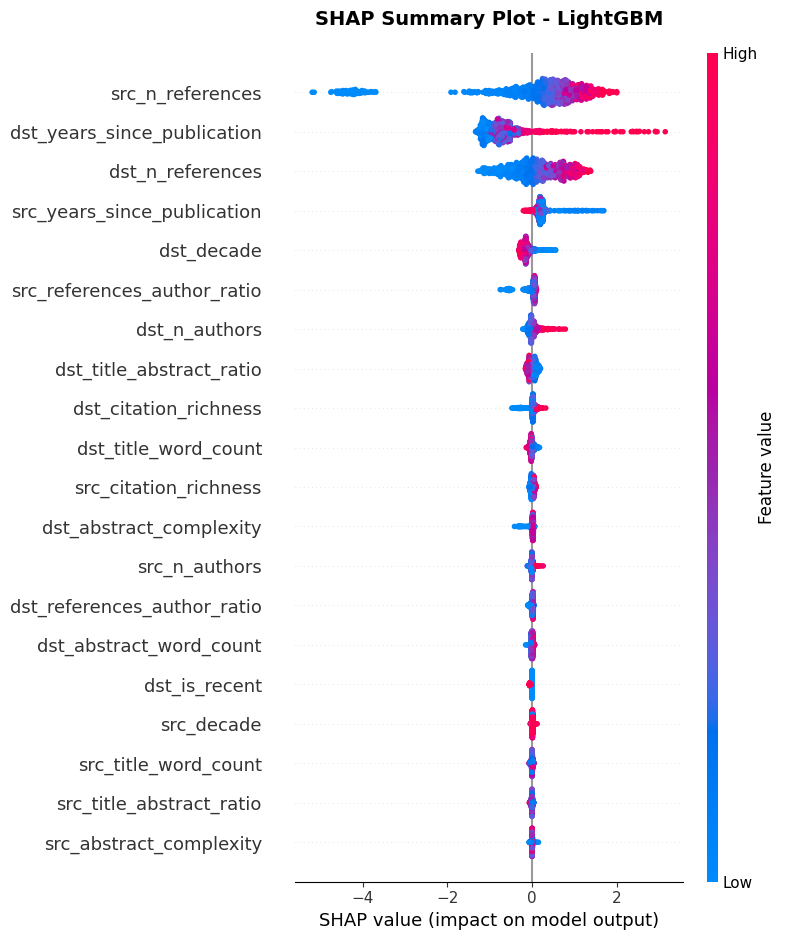

>> Generating SHAP plot for Random Forest...


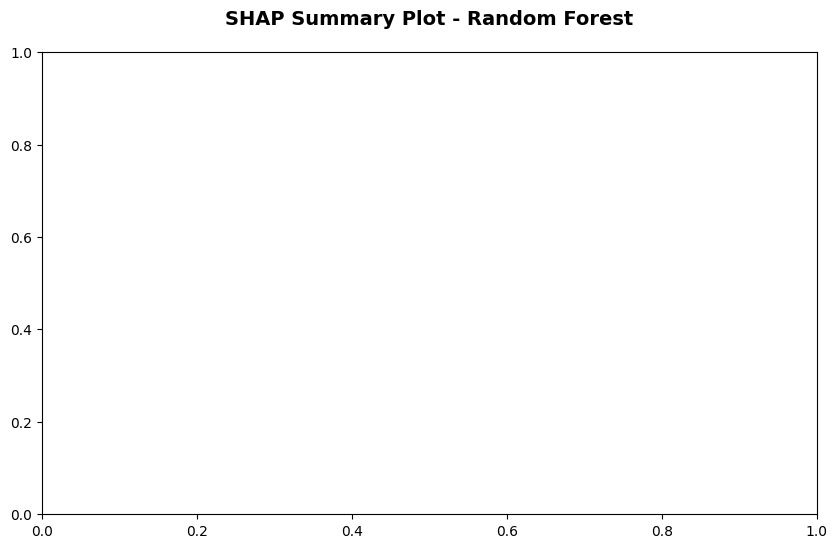

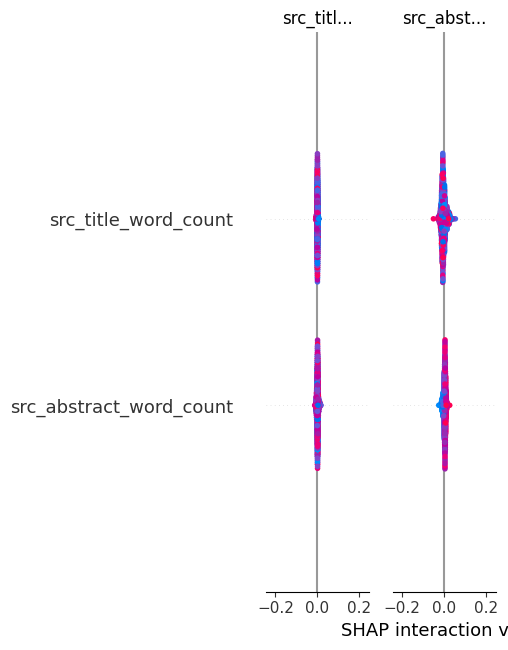

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve
)

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("Please install shap: pip install shap")

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║              ULTIMATE MODEL COMPARISON & SHAP EXPLAINABILITY             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Dynamically gather available models
models_info = {}

if 'rf_flat_probs' in globals():
    models_info['Random Forest'] = {'probs': rf_flat_probs, 'time': rf_flat_train_time, 'color': '#9b59b6'}
if 'lgbm_probs' in globals():
    models_info['LightGBM'] = {'probs': lgbm_probs, 'time': lgbm_train_time, 'color': '#2ecc71'}
if 'xgb_probs' in globals():
    models_info['XGBoost'] = {'probs': xgb_probs, 'time': xgb_train_time, 'color': '#3498db'}
if 'mlp_probs' in globals():
    models_info['MLP (PyTorch)'] = {'probs': mlp_probs, 'time': mlp_train_time, 'color': '#e74c3c'}

if not models_info:
    print("No models found in memory! Please run the training cells first.")
else:
    # --- 1. TEXT SUMMARY TABLE ---
    print("\n" + "═"*85)
    print(f"{'ULTIMATE FAIR COMPARISON':^85}")
    print("═"*85)
    print(f"{'Metric':<15} | " + " | ".join([f"{name:^13}" for name in models_info.keys()]))
    print("─"*85)
    
    metrics_calc = {'ROC-AUC': [], 'PR-AUC': [], 'Brier': [], 'Train Time': []}
    
    for name, data in models_info.items():
        metrics_calc['ROC-AUC'].append(roc_auc_score(y_test_xgb, data['probs']))
        metrics_calc['PR-AUC'].append(average_precision_score(y_test_xgb, data['probs']))
        metrics_calc['Brier'].append(brier_score_loss(y_test_xgb, data['probs']))
        metrics_calc['Train Time'].append(data['time'])
        
    print(f"{'ROC-AUC':<15} | " + " | ".join([f"{v:>13.4f}" for v in metrics_calc['ROC-AUC']]))
    print(f"{'PR-AUC':<15} | " + " | ".join([f"{v:>13.4f}" for v in metrics_calc['PR-AUC']]))
    print(f"{'Brier':<15} | " + " | ".join([f"{v:>13.4f}" for v in metrics_calc['Brier']]))
    print(f"{'Train time (s)':<15} | " + " | ".join([f"{v:>13.1f}" for v in metrics_calc['Train Time']]))
    print("═"*85 + "\n")

    # --- 2. COMPARISON PLOTS ---
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    # ROC Curve
    for name, data in models_info.items():
        fpr, tpr, _ = roc_curve(y_test_xgb, data['probs'])
        auc_val = metrics_calc['ROC-AUC'][list(models_info.keys()).index(name)]
        axes[0].plot(fpr, tpr, color=data['color'], lw=2, label=f"{name} (AUC = {auc_val:.3f})")
    
    axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=11)
    axes[0].set_ylabel('True Positive Rate', fontsize=11)
    axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # Precision-Recall Curve (Crucial for class imbalance)
    for name, data in models_info.items():
        precision, recall, _ = precision_recall_curve(y_test_xgb, data['probs'])
        pr_auc_val = metrics_calc['PR-AUC'][list(models_info.keys()).index(name)]
        axes[1].plot(recall, precision, color=data['color'], lw=2, label=f"{name} (PR-AUC = {pr_auc_val:.3f})")
    
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall', fontsize=11)
    axes[1].set_ylabel('Precision', fontsize=11)
    axes[1].set_title('Precision-Recall Curve Comparison', fontsize=13, fontweight='bold')
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

    # PR-AUC Bar Chart
    names = list(models_info.keys())
    pr_scores = metrics_calc['PR-AUC']
    colors = [models_info[n]['color'] for n in names]
    
    bars = axes[2].bar(names, pr_scores, color=colors, alpha=0.85)
    axes[2].set_ylim([0, max(pr_scores) * 1.2])
    axes[2].set_ylabel('PR-AUC Score', fontsize=11)
    axes[2].set_title('Overall Performance (PR-AUC)', fontsize=13, fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)
    
    for bar in bars:
        yval = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- 3. SHAP EXPLAINABILITY ---
    if HAS_SHAP:
        print("\n" + "═"*85)
        print(f"{'SHAP EXPLAINABILITY (Tree-Based Models)':^85}")
        print("═"*85)
        print("Computing SHAP values on a 1k sample to optimize performance...\n")

        # Convert test array to DataFrame for SHAP feature names, sample 1000 rows
        X_shap = pd.DataFrame(X_test_xgb, columns=feature_names_xgb).sample(n=min(1000, len(X_test_xgb)), random_state=42)

        # 3a. LightGBM SHAP
        if 'lgbm_model' in globals():
            print(">> Generating SHAP plot for LightGBM...")
            explainer_lgb = shap.TreeExplainer(lgbm_model)
            shap_values_lgb = explainer_lgb.shap_values(X_shap)
            # Handle binary classification output formats
            shap_vals = shap_values_lgb[1] if isinstance(shap_values_lgb, list) else shap_values_lgb
            
            plt.figure(figsize=(10, 6))
            plt.title("SHAP Summary Plot - LightGBM", fontsize=14, fontweight='bold', pad=20)
            shap.summary_plot(shap_vals, X_shap, show=False)
            plt.tight_layout()
            plt.show()

        # 3b. XGBoost SHAP
        if 'xgb_model' in globals():
            print(">> Generating SHAP plot for XGBoost...")
            explainer_xgb = shap.TreeExplainer(xgb_model)
            shap_values_xgb = explainer_xgb.shap_values(X_shap)
            shap_vals = shap_values_xgb[1] if isinstance(shap_values_xgb, list) else shap_values_xgb
            
            plt.figure(figsize=(10, 6))
            plt.title("SHAP Summary Plot - XGBoost", fontsize=14, fontweight='bold', pad=20)
            shap.summary_plot(shap_vals, X_shap, show=False)
            plt.tight_layout()
            plt.show()
            
        # 3c. Random Forest SHAP
        if 'rf_model' in globals():
            print(">> Generating SHAP plot for Random Forest...")
            explainer_rf = shap.TreeExplainer(rf_model)
            shap_values_rf = explainer_rf.shap_values(X_shap)
            shap_vals = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf
            
            plt.figure(figsize=(10, 6))
            plt.title("SHAP Summary Plot - Random Forest", fontsize=14, fontweight='bold', pad=20)
            shap.summary_plot(shap_vals, X_shap, show=False)
            plt.tight_layout()
            plt.show()

# MODEL 4 -> Random Forest, using pair-level features

## Pair-Level Baseline for Citation Link Prediction

The GCN section models the citation graph directly. For this target, the supervised example is a **paper pair**: source paper $A$ and candidate target paper $B$, with label $y=1$ if $A$ cites $B$ and $y=0$ otherwise.

That means the right tabular baseline should:
- build one row per paper pair,
- use only metadata available before the link decision,
- avoid citation-count leakage such as `n_citation` or `impact_score`,
- stay interpretable so the team can explain the result with SHAP and uncertainty.

Below, the notebook builds pair-level features from what is already in the dataset: authors, keywords, titles, abstracts, venue, year, and reference lists.

In [60]:
# %pip install -q scikit-learn shap

In [61]:
import re
import random
from bisect import bisect_right

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

random.seed(42)
np.random.seed(42)


In [62]:
def as_list(value):
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    return [value]


def normalize_scalar(value):
    if value is None:
        return ""
    if isinstance(value, float) and np.isnan(value):
        return ""
    text = str(value).strip().lower()
    return re.sub(r"\s+", " ", text)


def extract_author_names(authors):
    names = set()
    for item in as_list(authors):
        if isinstance(item, dict):
            name = item.get("name")
        elif hasattr(item, "get"):
            name = item.get("name")
        else:
            name = item
        name = normalize_scalar(name)
        if name:
            names.add(name)
    return names


def extract_strings(values):
    items = set()
    for item in as_list(values):
        token = normalize_scalar(item)
        if token:
            items.add(token)
    return items


def safe_int(value):
    if value is None:
        return 0
    if isinstance(value, float) and np.isnan(value):
        return 0
    return int(value)


def tokenize_text(text):
    text = normalize_scalar(text)
    if not text:
        return set()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return {tok for tok in text.split() if tok}


def jaccard(left, right):
    union = left | right
    if not union:
        return 0.0
    return len(left & right) / len(union)


Up to this point, our Exploratory Data Analysis (EDA) focused on **Node-Level Features**—metrics describing individual papers (e.g., `impact_score`, `citation_per_year`, `venue_tier`). While these are excellent for understanding global trends, our ultimate machine learning goal is **Link Prediction**: determining whether Paper A cites Paper B.

To predict links, we cannot look at papers in isolation. We must evaluate the *relationship* between them. 

If we try to predict a citation by feeding the model Paper B's total `impact_score` or `n_citation`, the model will suffer from **Target Leakage**. It would simply learn to predict that "highly cited papers get cited," effectively using future knowledge (citations accumulated up to 2024) to predict a past event. 

Instead, we force the model to rely purely on information available at the exact moment of publication. We do this by calculating **Pair-Level Features**:
1. **Jaccard Similarities:** We measure the mathematical overlap between the two papers' metadata (Authors, Keywords, References, Titles, and Abstracts). A higher Jaccard index implies stronger topical or social proximity.
2. **Temporal Features:** We calculate `year_gap` to understand the age difference between the citing and cited paper, and boolean flags like `same_decade` to capture chronological clustering.
3. **Venue & Overlap Flags:** Simple binary indicators (e.g., `same_venue`, `author_overlap_any`) to capture direct matches.

By constructing a balanced dataset of 10,000 pairs (50% actual citations, 50% random non-citations), we frame the link prediction task as a binary classification problem based purely on relational similarity.

In [63]:
print("Building pair-level dataset from paper metadata and reference links...")

# Keep this in DuckDB: only the lightweight id/year index is loaded here.
# The full paper metadata for the sampled pairs will be fetched later,
# after the positive/negative pairs are known.
all_ids_years = con.sql("""
SELECT id, year
FROM papers
WHERE id IS NOT NULL AND TRIM(id) <> '' AND year IS NOT NULL
""").df()

print(f"Indexed {len(all_ids_years):,} paper ids with year metadata")

Building pair-level dataset from paper metadata and reference links...
Indexed 6,729,828 paper ids with year metadata


In [64]:

positive_pairs = con.sql("""
SELECT DISTINCT
    p.id AS src_id,
    ref AS dst_id
FROM papers p
CROSS JOIN UNNEST(p."references") AS t(ref)
JOIN papers d ON d.id = ref
WHERE p.id IS NOT NULL
  AND d.id IS NOT NULL
  AND TRIM(p.id) <> ''
  AND TRIM(ref) <> ''
  AND p.id <> ref
  AND p.year IS NOT NULL
  AND d.year IS NOT NULL
""").df()

if positive_pairs.empty:
    raise RuntimeError("No citation edges were found in the dataset.")

In [65]:
sample_n = min(5000, len(positive_pairs))
positive_pairs = positive_pairs.sample(n=sample_n, random_state=42).reset_index(drop=True)

# Build a full paper-id/year index for negative sampling.
all_id_to_year = dict(zip(all_ids_years["id"], all_ids_years["year"]))
all_years_sorted = sorted(all_ids_years["year"].dropna().astype(int).unique().tolist())
all_ids_by_year = {year: all_ids_years.loc[all_ids_years["year"] == year, "id"].tolist() for year in all_years_sorted}
all_prefix_ids = {}
running_ids = []
for year in all_years_sorted:
    running_ids.extend(all_ids_by_year[year])
    all_prefix_ids[year] = running_ids.copy()

# Only fetch the reference lists for the sampled source papers.
source_ids_df = pd.DataFrame({"id": positive_pairs["src_id"].unique()})
con.register("source_ids", source_ids_df)
source_refs_df = con.sql("""
SELECT p.id, p."references" AS refs
FROM papers p
JOIN source_ids s ON p.id = s.id
""").df()
source_ref_lookup = {row.id: extract_strings(row.refs) for row in source_refs_df.itertuples(index=False)}

# Alias names used by the following cell.
id_to_year = all_id_to_year
years_sorted = all_years_sorted
prefix_ids = all_prefix_ids
id_to_refs = source_ref_lookup

# Sample negatives from all papers that are not already cited by the source.
def sample_negative_target(src_id):
    src_year = id_to_year[src_id]
    idx = bisect_right(years_sorted, src_year) - 1
    if idx < 0:
        return None
    pool_year = years_sorted[idx]
    pool = prefix_ids[pool_year]
    banned = id_to_refs.get(src_id, set()) | {src_id}
    if len(pool) <= len(banned):
        return None
    for _ in range(50):
        candidate = random.choice(pool)
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    for candidate in random.sample(pool, min(len(pool), 200)):
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    return None

negative_rows = []
for src_id in positive_pairs["src_id"].tolist():
    dst_id = sample_negative_target(src_id)
    if dst_id is not None:
        negative_rows.append((src_id, dst_id))

negative_pairs = pd.DataFrame(negative_rows, columns=["src_id", "dst_id"])
if negative_pairs.empty:
    raise RuntimeError("Failed to sample negative pairs.")

positive_pairs = positive_pairs.iloc[: len(negative_pairs)].copy()
positive_pairs["label"] = 1
negative_pairs["label"] = 0
pair_df = pd.concat([positive_pairs, negative_pairs], ignore_index=True)
pair_df = pair_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Fetch only the paper metadata that actually appears in the sampled pairs.
pair_ids_df = pd.DataFrame({"id": pd.unique(pd.concat([pair_df["src_id"], pair_df["dst_id"]], ignore_index=True))})
con.register("pair_ids", pair_ids_df)
papers_df = con.sql("""
SELECT
    id,
    year,
    venue,
    title,
    abstract,
    authors,
    keywords,
    "references" AS refs,
    n_authors,
    n_keywords,
    n_references,
    title_len,
    abstract_len
FROM papers
WHERE id IN (SELECT id FROM pair_ids)
""").df()

paper_lookup = papers_df.set_index("id").to_dict(orient="index")

print(f"Sampled positive pairs: {len(positive_pairs):,}")
print(f"Sampled negative pairs: {len(negative_pairs):,}")
print(f"Fetched metadata for {len(papers_df):,} unique papers involved in the sampled pairs.")

Sampled positive pairs: 5,000
Sampled negative pairs: 5,000
Fetched metadata for 14,882 unique papers involved in the sampled pairs.


In [66]:


def sample_negative_target(src_id):
    src_year = id_to_year[src_id]
    idx = bisect_right(years_sorted, src_year) - 1
    if idx < 0:
        return None
    pool_year = years_sorted[idx]
    pool = prefix_ids[pool_year]
    banned = id_to_refs.get(src_id, set()) | {src_id}
    if len(pool) <= len(banned):
        return None
    for _ in range(50):
        candidate = random.choice(pool)
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    for candidate in random.sample(pool, min(len(pool), 200)):
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    return None

In [67]:
print(f"Pair table ready: {len(pair_df):,} rows")
display(pair_df.head())

Pair table ready: 10,000 rows


,src_id,dst_id,label
0,61b478595244ab9dcbe67385,599c7e31601a182cd2882ad7,0
1,53e9a62eb7602d9702f5b67c,5390881820f70186a0d81a46,1
2,62bd156f5aee126c0f6250ba,6047609d91e0116b67c791d4,1
3,5390b2fc20f70186a0eee1be,558a6a4fe4b037c087570099,1
4,59ae3bf12bbe271c4c71c60b,5390b48420f70186a0efc566,1


## The Tabular Supervised Baseline (Random Forest)

### The Objective
Before deploying a complex, graph-native approach (like a Graph Convolutional Network), it is best practice to establish a robust **Supervised Tabular Baseline**. We use a Random Forest Classifier for this task because it handles non-linear relationships well, is robust to outliers in our text similarities, and provides excellent interpretability without requiring feature scaling.

### Feature Selection
Notice the `feature_cols` list below. **We strictly exclude all individual quality metrics** (`impact_score`, `venue_tier`, `n_citation`). The model is only allowed to see:
* Jaccard similarities (Text, Authors, References)
* Temporal distances (`year_gap`, `same_year`)
* Absolute lengths (Number of authors, abstract length)

This ensures our model genuinely learns *why* citations happen based on content and context, rather than "cheating" by looking at global popularity metrics.

### Model Configuration & Evaluation Strategy
1. **Stratified Splitting:** We use an 80/20 train-test split, stratified on our target `label` to ensure perfectly balanced classes in both sets.
2. **Hyperparameters:** We configure the Random Forest with `n_estimators=300` for stability, `min_samples_leaf=2` to prevent overfitting on highly specific paper pairs, and `class_weight="balanced_subsample"` to handle bootstrap-level imbalances.
3. **Interpretability:** Beyond standard metrics (ROC-AUC, PR-AUC, F1-Score), we prioritize interpretability. We utilize **Permutation Importance** (and SHAP values, if available) to explicitly rank which pair-level signals drive citation decisions, and we calculate the **Brier Score** to ensure our predicted citation probabilities are well-calibrated.

In [68]:
def build_pair_features(src_id, dst_id, label):
    src = paper_lookup[src_id]
    dst = paper_lookup[dst_id]

    src_authors  = extract_author_names(src["authors"])
    dst_authors  = extract_author_names(dst["authors"])
    src_keywords = extract_strings(src["keywords"])
    dst_keywords = extract_strings(dst["keywords"])
    src_refs     = extract_strings(src["refs"])
    dst_refs     = extract_strings(dst["refs"])
    src_title    = tokenize_text(src["title"])
    dst_title    = tokenize_text(dst["title"])
    src_abstract = tokenize_text(src["abstract"])
    dst_abstract = tokenize_text(dst["abstract"])

    src_venue = normalize_scalar(src["venue"])
    dst_venue = normalize_scalar(dst["venue"])
    src_year  = int(src["year"])
    dst_year  = int(dst["year"])

    author_overlap  = len(src_authors & dst_authors)
    keyword_overlap = len(src_keywords & dst_keywords)
    ref_overlap     = len(src_refs & dst_refs)

    # Graph features
    src_graph = graph_feat_lookup.get(src_id, _default_graph)
    dst_graph = graph_feat_lookup.get(dst_id, _default_graph)

    src_pagerank   = src_graph["pagerank"]
    dst_pagerank   = dst_graph["pagerank"]
    src_in_degree  = src_graph["in_degree"]
    dst_in_degree  = dst_graph["in_degree"]
    src_out_degree = src_graph["out_degree"]
    dst_out_degree = dst_graph["out_degree"]
    src_hub        = src_graph["hub_score"]
    dst_authority  = dst_graph["authority_score"]

    year_gap        = src_year - dst_year
    keyword_jaccard = jaccard(src_keywords, dst_keywords)

    return {
        "src_id":  src_id,
        "dst_id":  dst_id,
        "label":   label,

        # --- Temporal ---
        "year_gap":          year_gap,
        "src_year":          src_year,
        "dst_year":          dst_year,
        "same_year":         int(src_year == dst_year),
        "same_decade":       int(src_year // 10 == dst_year // 10),
        "source_not_earlier":int(src_year >= dst_year),

        # --- Venue ---
        "same_venue": int(src_venue != "" and src_venue == dst_venue),

        # --- Author (traditional) ---
        "author_overlap":     author_overlap,
        "author_overlap_any": int(author_overlap > 0),
        "author_jaccard":     jaccard(src_authors, dst_authors),

        # --- Textual ---
        "keyword_overlap":     keyword_overlap,
        "keyword_overlap_any": int(keyword_overlap > 0),
        "keyword_jaccard":     keyword_jaccard,
        "title_jaccard":       jaccard(src_title, dst_title),
        "abstract_jaccard":    jaccard(src_abstract, dst_abstract),

        # --- Bibliographic coupling (traditional) ---
        "bibliographic_coupling":     ref_overlap,
        "bibliographic_coupling_any": int(ref_overlap > 0),
        "reference_jaccard":          jaccard(src_refs, dst_refs),

        # --- Node-level counts ---
        "source_n_authors":    safe_int(src["n_authors"]),
        "dst_n_authors":       safe_int(dst["n_authors"]),
        "source_n_keywords":   safe_int(src["n_keywords"]),
        "dst_n_keywords":      safe_int(dst["n_keywords"]),
        "source_n_references": safe_int(src["n_references"]),
        "dst_n_references":    safe_int(dst["n_references"]),
        "source_title_len":    safe_int(src["title_len"]),
        "dst_title_len":       safe_int(dst["title_len"]),
        "source_abstract_len": safe_int(src["abstract_len"]),
        "dst_abstract_len":    safe_int(dst["abstract_len"]),

        # --- Graph-based ---
        "src_pagerank":    src_pagerank,
        "dst_pagerank":    dst_pagerank,
        "src_in_degree":   src_in_degree,
        "dst_in_degree":   dst_in_degree,
        "src_out_degree":  src_out_degree,
        "dst_out_degree":  dst_out_degree,
        "src_hub_score":   src_hub,
        "dst_authority_score": dst_authority,

        # --- Combination features (graph × textual / graph × temporal) ---
        "pagerank_ratio":            src_pagerank / max(dst_pagerank, 1e-9),
        "in_degree_diff":            src_in_degree - dst_in_degree,
        "hub_x_keyword_jaccard":     src_hub * keyword_jaccard,
        "authority_x_year_gap":      dst_authority * abs(year_gap),
    }

In [69]:
pair_feature_rows = [build_pair_features(row.src_id, row.dst_id, int(row.label)) for row in pair_df.itertuples(index=False)]
pair_features_df = pd.DataFrame(pair_feature_rows)

In [70]:

print(f"Pair rows built: {len(pair_features_df):,}")
display(pair_features_df.head())


Pair rows built: 10,000


,src_id,dst_id,label,year_gap,src_year,dst_year,same_year,same_decade,source_not_earlier,same_venue,...,src_in_degree,dst_in_degree,src_out_degree,dst_out_degree,src_hub_score,dst_authority_score,pagerank_ratio,in_degree_diff,hub_x_keyword_jaccard,authority_x_year_gap
0,61b478595244ab9dcbe67385,599c7e31601a182cd2882ad7,0,4,2021,2017,0,0,1,0,...,0,2,0,3,0.000000e+00,2.418775e-10,0.000000,-2,0.0,9.675099e-10
1,53e9a62eb7602d9702f5b67c,5390881820f70186a0d81a46,1,13,2014,2001,0,0,1,0,...,5,45,20,2,9.807352e-10,6.808839e-10,0.091737,-40,0.0,8.851491e-09
2,62bd156f5aee126c0f6250ba,6047609d91e0116b67c791d4,1,1,2022,2021,0,1,1,0,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000,0,0.0,0.000000e+00
3,5390b2fc20f70186a0eee1be,558a6a4fe4b037c087570099,1,9,2006,1997,0,0,1,0,...,15,39,7,3,6.675758e-09,5.449456e-07,0.252252,-24,0.0,4.904510e-06
4,59ae3bf12bbe271c4c71c60b,5390b48420f70186a0efc566,1,7,2017,2010,0,1,1,0,...,2,11,21,16,3.105995e-08,3.655785e-09,0.375311,-9,0.0,2.559050e-08


In [75]:
feature_cols = [
    "year_gap",
    "src_year",
    "dst_year",
    "same_year",
    "same_decade",
    "source_not_earlier",
    "same_venue",
    "author_overlap",
    "author_overlap_any",
    "author_jaccard",
    "keyword_overlap",
    "keyword_overlap_any",
    "keyword_jaccard",
    "title_jaccard",
    "abstract_jaccard",
    "bibliographic_coupling",
    "bibliographic_coupling_any",
    "reference_jaccard",
    "source_n_authors",
    "dst_n_authors",
    "source_n_keywords",
    "dst_n_keywords",
    "source_n_references",
    "dst_n_references",
    "source_title_len",
    "dst_title_len",
    "source_abstract_len",
    "dst_abstract_len",
    "src_pagerank",
    "dst_pagerank",
    "src_in_degree",
    "dst_in_degree",
    "src_out_degree",
    "dst_out_degree",
    "src_hub_score",
    "dst_authority_score",
    "pagerank_ratio",
    "in_degree_diff",
    "hub_x_keyword_jaccard",
    "authority_x_year_gap",
]

# Temporal split — train on older pairs, val and test on newer ones
pair_features_df = pair_features_df.sort_values("src_year").reset_index(drop=True)

n         = len(pair_features_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = pair_features_df.iloc[:train_end]
val_df   = pair_features_df.iloc[train_end:val_end]
test_df  = pair_features_df.iloc[val_end:]

X_train = train_df[feature_cols].fillna(0)
X_val   = val_df[feature_cols].fillna(0)
X_test  = test_df[feature_cols].fillna(0)
y_train = train_df["label"].astype(int)
y_val   = val_df["label"].astype(int)
y_test  = test_df["label"].astype(int)

print(f"Train : {len(X_train):,} pairs  (up to year {train_df['src_year'].max()})")
print(f"Val   : {len(X_val):,} pairs   (up to year {val_df['src_year'].max()})")
print(f"Test  : {len(X_test):,} pairs   (up to year {test_df['src_year'].max()})")

Train : 7,000 pairs  (up to year 2021)
Val   : 1,500 pairs   (up to year 2023)
Test  : 1,500 pairs   (up to year 2025)


Train : (7000, 40)  Val : (1050, 40)  Test : (1500, 40)
Pair features used (40): ['year_gap', 'src_year', 'dst_year', 'same_year', 'same_decade', 'source_not_earlier', 'same_venue', 'author_overlap', 'author_overlap_any', 'author_jaccard', 'keyword_overlap', 'keyword_overlap_any', 'keyword_jaccard', 'title_jaccard', 'abstract_jaccard', 'bibliographic_coupling', 'bibliographic_coupling_any', 'reference_jaccard', 'source_n_authors', 'dst_n_authors', 'source_n_keywords', 'dst_n_keywords', 'source_n_references', 'dst_n_references', 'source_title_len', 'dst_title_len', 'source_abstract_len', 'dst_abstract_len', 'src_pagerank', 'dst_pagerank', 'src_in_degree', 'dst_in_degree', 'src_out_degree', 'dst_out_degree', 'src_hub_score', 'dst_authority_score', 'pagerank_ratio', 'in_degree_diff', 'hub_x_keyword_jaccard', 'authority_x_year_gap']

Training Random Forest...
Training time : 5.8s

--- Random Forest (Test Split) ---
ROC-AUC : 0.9611
PR-AUC  : 0.9692
Brier   : 0.0699
              precision 

c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best iteration : 1000  |  Training time: 1.6s

--- LightGBM (Test Split) ---
ROC-AUC : 0.9669
PR-AUC  : 0.9736
Brier   : 0.0703
              precision    recall  f1-score   support

           0     0.8821    0.9683    0.9232       757
           1     0.9641    0.8681    0.9136       743

    accuracy                         0.9187      1500
   macro avg     0.9231    0.9182    0.9184      1500
weighted avg     0.9227    0.9187    0.9184      1500


Training MLP...
  Epoch   1 | train=0.6332  val=0.5859 ✓
  Epoch   2 | train=0.4922  val=0.4276 ✓
  Epoch   3 | train=0.3709  val=0.3570 ✓
  Epoch   4 | train=0.3095  val=0.3146 ✓
  Epoch   5 | train=0.2928  val=0.2931 ✓
  Epoch   6 | train=0.2847  val=0.2799 ✓
  Epoch   7 | train=0.2714  val=0.2713 ✓
  Epoch   8 | train=0.2683  val=0.2673 ✓
  Epoch   9 | train=0.2657  val=0.2599 ✓
  Epoch  10 | train=0.2618  val=0.2561 ✓
  Epoch  11 | train=0.2585  val=0.2516 ✓
  Epoch  12 | train=0.2581  val=0.2491 ✓
  Epoch  13 | train=0.2554  val=0.24

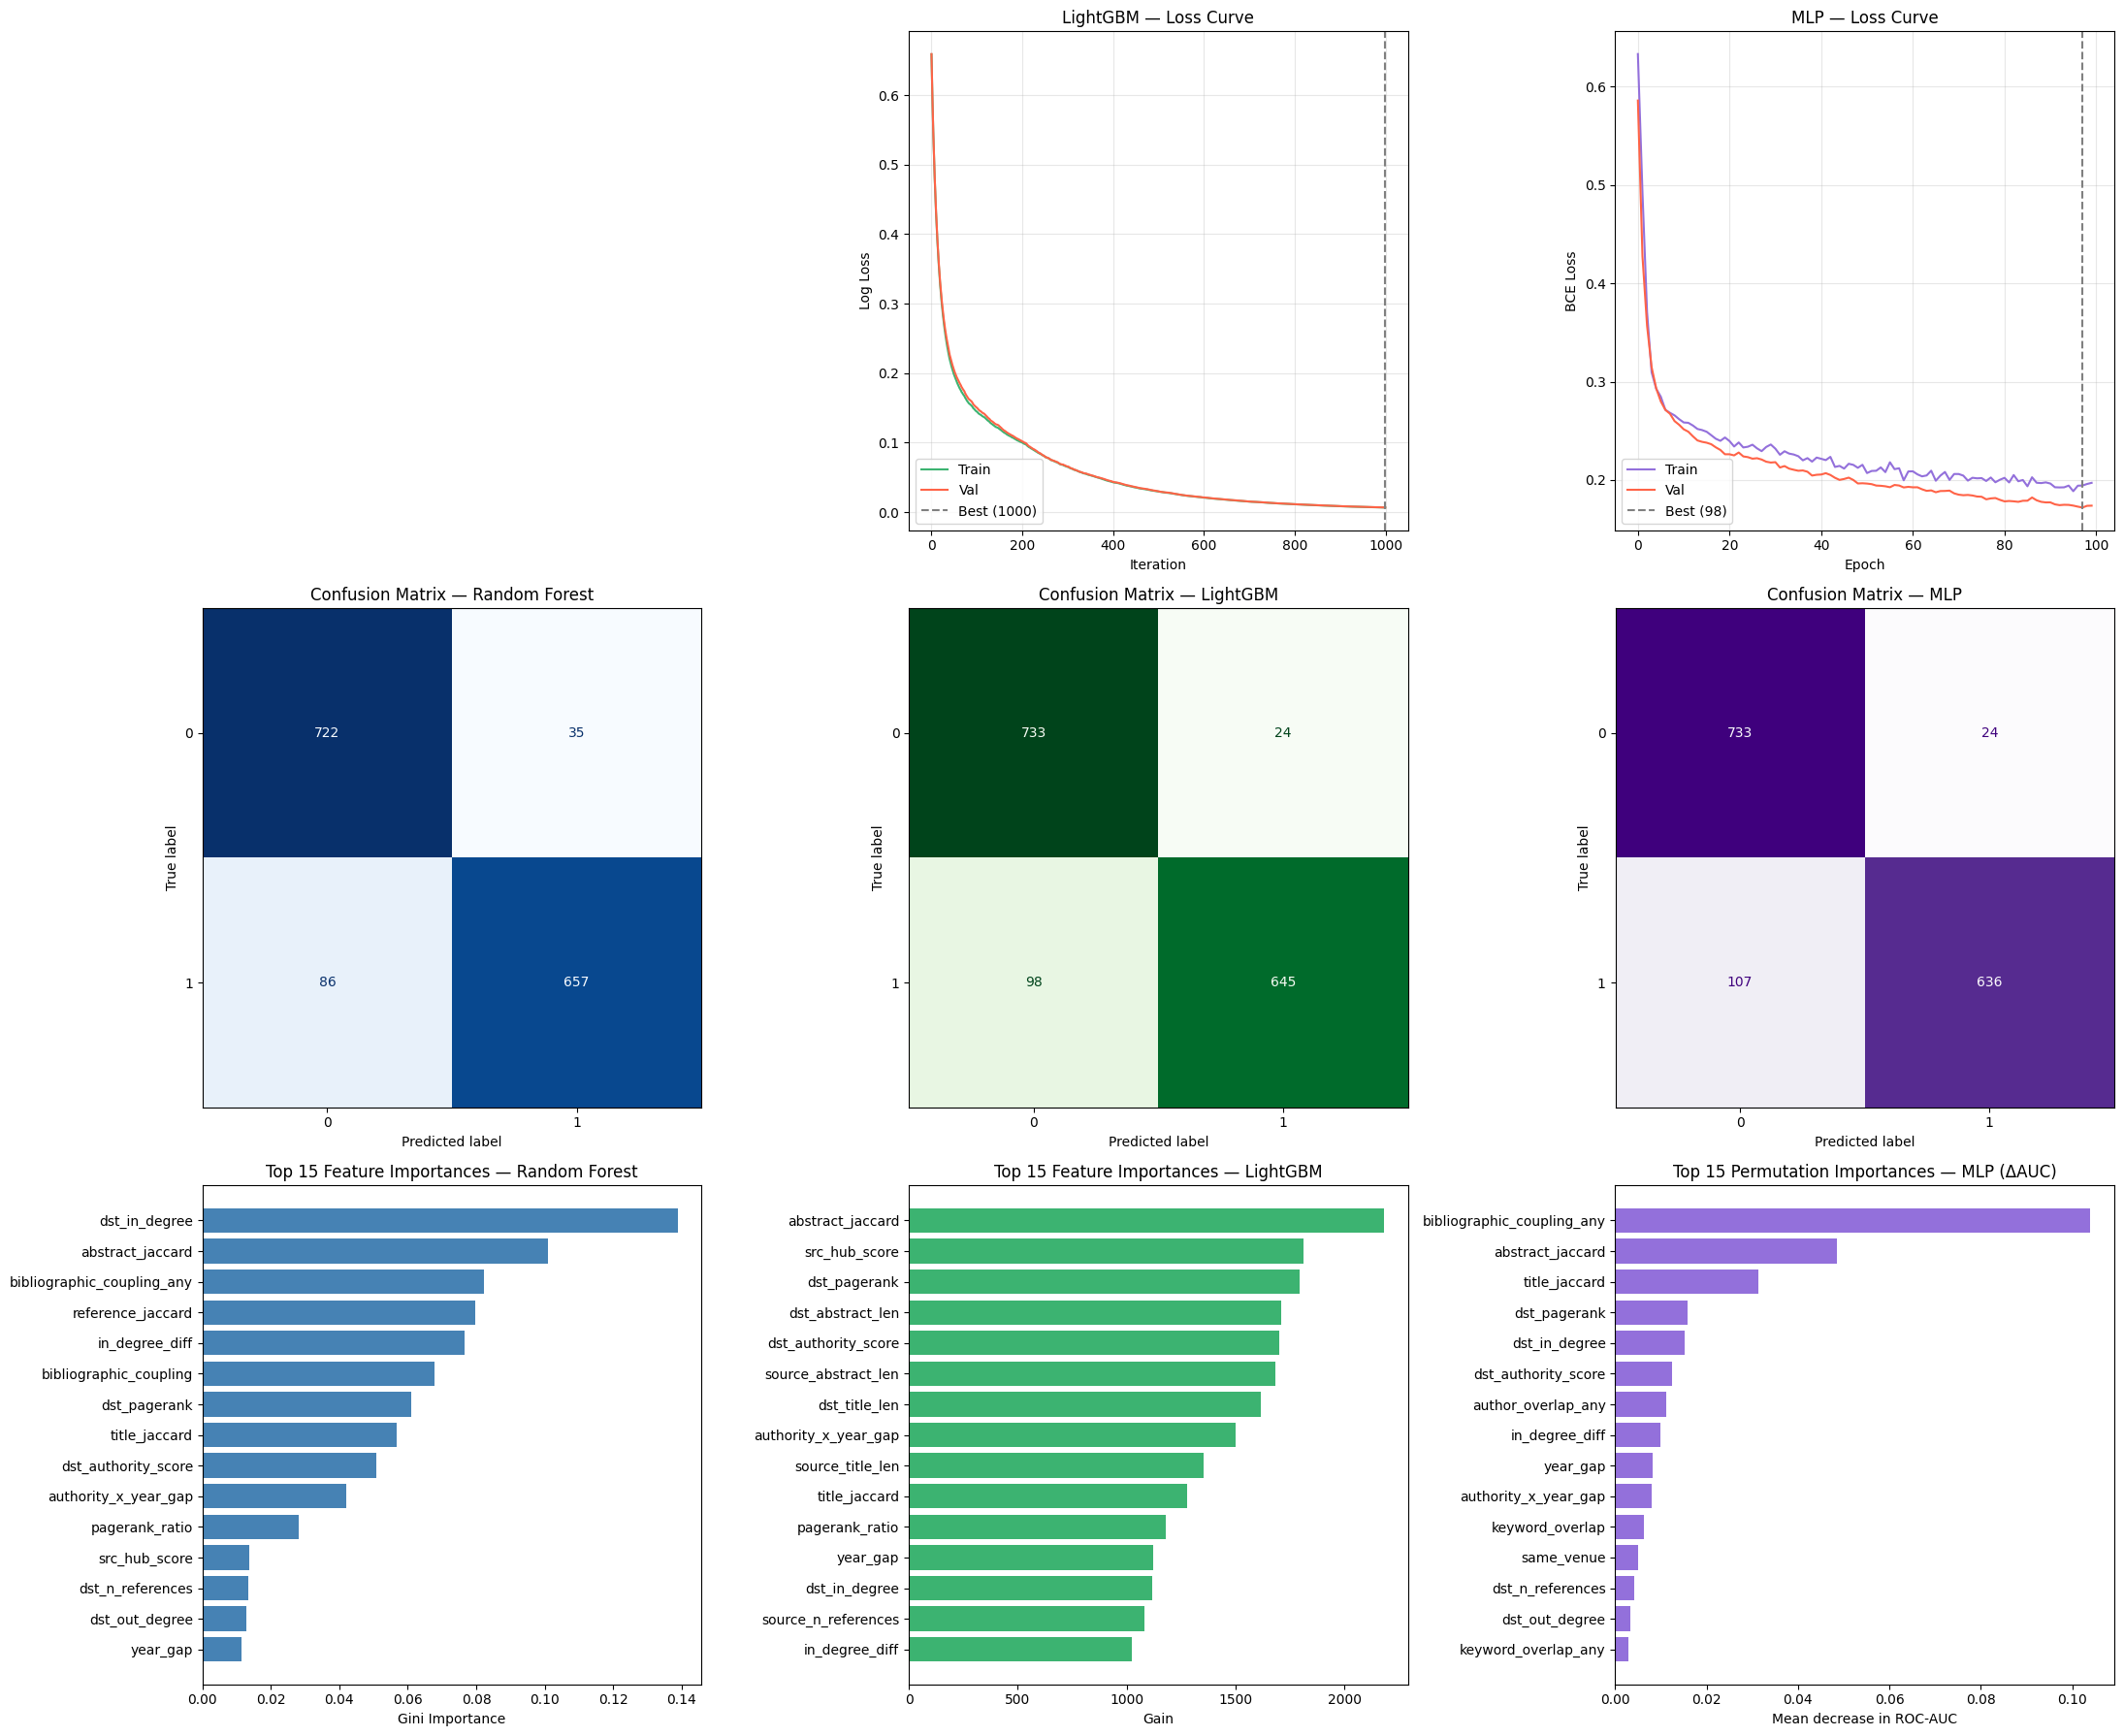


══════════════ FAIR COMPARISON (Pair Features) ══════════════
Metric           Random Forest   LightGBM        MLP
────────────────────────────────────────────────────
ROC-AUC                 0.9611     0.9669     0.9642
PR-AUC                  0.9692     0.9736     0.9716
Brier                   0.0699     0.0703     0.0673
Train time                5.8s       1.6s       9.1s


In [76]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# ── 0. Carve out a validation set from train (for early stopping) ─────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

X_tr  = X_train.to_numpy(dtype=np.float32)
X_val = X_val.to_numpy(dtype=np.float32)
X_te  = X_test.to_numpy(dtype=np.float32)
y_tr  = y_train.to_numpy(dtype=np.int32)
y_val = y_val.to_numpy(dtype=np.int32)
y_te  = y_test.to_numpy(dtype=np.int32)

print(f"Train : {X_tr.shape}  Val : {X_val.shape}  Test : {X_te.shape}")
print(f"Pair features used ({len(feature_cols)}): {feature_cols}")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  1. RANDOM FOREST                                                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("Training Random Forest...")
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_tr, y_tr)
rf_train_time = time.time() - t0

rf_probs = rf_model.predict_proba(X_te)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print(f"Training time : {rf_train_time:.1f}s")
print(f"\n--- Random Forest (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_te, rf_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_te, rf_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_te, rf_probs):.4f}")
print(classification_report(y_te, rf_preds, digits=4))


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  2. LIGHTGBM                                                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("Training LightGBM...")
scale_pos_weight_lgbm = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=6,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.9,
    min_child_samples=20,
    reg_lambda=1.0,
    objective="binary",
    metric="binary_logloss",
    scale_pos_weight=scale_pos_weight_lgbm,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_evals_result = {}
t0 = time.time()
lgbm_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    eval_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=0),
        lgb.record_evaluation(lgbm_evals_result),
    ],
)
lgbm_train_time = time.time() - t0

lgbm_probs = lgbm_model.predict_proba(X_te)[:, 1]
lgbm_preds = (lgbm_probs >= 0.5).astype(int)

print(f"Best iteration : {lgbm_model.best_iteration_}  |  Training time: {lgbm_train_time:.1f}s")
print(f"\n--- LightGBM (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_te, lgbm_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_te, lgbm_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_te, lgbm_probs):.4f}")
print(classification_report(y_te, lgbm_preds, digits=4))


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  3. MLP                                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("Training MLP...")

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 512        # smaller: pair features dataset is tiny vs node-feature one
MAX_EPOCHS = 100
PATIENCE   = 10
LR         = 1e-3

# Scale features — MLP is sensitive to input scale, RF/LGBM are not
scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_te_s  = scaler.transform(X_te).astype(np.float32)

def make_loader(X, y, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

train_loader = make_loader(X_tr_s,  y_tr,  shuffle=True)
val_loader   = make_loader(X_val_s, y_val, shuffle=False)
test_loader  = make_loader(X_te_s,  y_te,  shuffle=False)

class LinkMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

mlp_model = LinkMLP(X_tr_s.shape[1]).to(DEVICE)

pos_weight = torch.tensor(
    [(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)],
    dtype=torch.float32,
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

mlp_train_losses, mlp_val_losses = [], []
best_val_loss, best_state, epochs_no_improve = float("inf"), None, 0

t0 = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    mlp_model.train()
    ep_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item() * len(yb)
    train_loss = ep_loss / len(y_tr)

    mlp_model.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl += criterion(mlp_model(xb), yb).item() * len(yb)
    val_loss = vl / len(y_val)

    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    scheduler.step(val_loss)

    tag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in mlp_model.state_dict().items()}
        epochs_no_improve = 0
        tag = " ✓"
    else:
        epochs_no_improve += 1

    print(f"  Epoch {epoch:>3} | train={train_loss:.4f}  val={val_loss:.4f}{tag}")
    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

mlp_train_time = time.time() - t0
best_epoch = epoch - epochs_no_improve
mlp_model.load_state_dict(best_state)

def predict_proba_mlp(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, _ in loader:
            probs.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
    return np.concatenate(probs)

mlp_probs = predict_proba_mlp(mlp_model, test_loader)
mlp_preds = (mlp_probs >= 0.5).astype(int)

print(f"Best epoch: {best_epoch}  |  Training time: {mlp_train_time:.1f}s")
print(f"\n--- MLP (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_te, mlp_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_te, mlp_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_te, mlp_probs):.4f}")
print(classification_report(y_te, mlp_preds, digits=4))


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  4. PLOTS                                                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
model_configs = [
    ("Random Forest", rf_probs,   rf_preds,   "Blues"),
    ("LightGBM",      lgbm_probs, lgbm_preds, "Greens"),
    ("MLP",           mlp_probs,  mlp_preds,  "Purples"),
]

# Row 0: Loss/learning curves
axes[0, 0].set_visible(False)   # RF has no loss curve

lgbm_tl = lgbm_evals_result["train"]["binary_logloss"]
lgbm_vl = lgbm_evals_result["val"]["binary_logloss"]
axes[0, 1].plot(lgbm_tl, color="mediumseagreen", label="Train")
axes[0, 1].plot(lgbm_vl, color="tomato",         label="Val")
axes[0, 1].axvline(lgbm_model.best_iteration_ - 1, color="gray", linestyle="--",
                   label=f"Best ({lgbm_model.best_iteration_})")
axes[0, 1].set_title("LightGBM — Loss Curve")
axes[0, 1].set_xlabel("Iteration"); axes[0, 1].set_ylabel("Log Loss")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(mlp_train_losses, color="mediumpurple", label="Train")
axes[0, 2].plot(mlp_val_losses,   color="tomato",       label="Val")
axes[0, 2].axvline(best_epoch - 1, color="gray", linestyle="--", label=f"Best ({best_epoch})")
axes[0, 2].set_title("MLP — Loss Curve")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("BCE Loss")
axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)

# Row 1: Confusion matrices
for col, (name, _, preds_, cmap) in enumerate(model_configs):
    cm = confusion_matrix(y_te, preds_)
    ConfusionMatrixDisplay(cm).plot(cmap=cmap, ax=axes[1, col], colorbar=False)
    axes[1, col].set_title(f"Confusion Matrix — {name}")

# Row 2: Feature importances
# RF — built-in
rf_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False).head(15)
axes[2, 0].barh(rf_imp["feature"][::-1], rf_imp["importance"][::-1], color="steelblue")
axes[2, 0].set_title("Top 15 Feature Importances — Random Forest")
axes[2, 0].set_xlabel("Gini Importance")

# LGBM — built-in gain
lgbm_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": lgbm_model.feature_importances_,
}).sort_values("importance", ascending=False).head(15)
axes[2, 1].barh(lgbm_imp["feature"][::-1], lgbm_imp["importance"][::-1], color="mediumseagreen")
axes[2, 1].set_title("Top 15 Feature Importances — LightGBM")
axes[2, 1].set_xlabel("Gain")

# MLP — permutation importance on a subsample
N_IMP = min(2000, len(X_te_s))
rng   = np.random.default_rng(42)
idx   = rng.choice(len(X_te_s), N_IMP, replace=False)
X_sub, y_sub = X_te_s[idx], y_te[idx]

def mlp_roc(X, y):
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    return roc_auc_score(y, predict_proba_mlp(mlp_model, loader))

base = mlp_roc(X_sub, y_sub)
mlp_imp_scores = np.zeros(len(feature_cols))
for i in range(len(feature_cols)):
    Xp = X_sub.copy(); Xp[:, i] = rng.permutation(Xp[:, i])
    mlp_imp_scores[i] = base - mlp_roc(Xp, y_sub)

mlp_imp = pd.DataFrame({
    "feature": feature_cols, "importance": mlp_imp_scores
}).sort_values("importance", ascending=False).head(15)
axes[2, 2].barh(mlp_imp["feature"][::-1], mlp_imp["importance"][::-1], color="mediumpurple")
axes[2, 2].set_title("Top 15 Permutation Importances — MLP (ΔAUC)")
axes[2, 2].set_xlabel("Mean decrease in ROC-AUC")

plt.tight_layout()
plt.show()


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  5. FAIR COMPARISON                                                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n══════════════ FAIR COMPARISON (Pair Features) ══════════════")
print(f"{'Metric':<14} {'Random Forest':>15} {'LightGBM':>10} {'MLP':>10}")
print("─" * 52)
print(f"{'ROC-AUC':<14} {roc_auc_score(y_te, rf_probs):>15.4f} {roc_auc_score(y_te, lgbm_probs):>10.4f} {roc_auc_score(y_te, mlp_probs):>10.4f}")
print(f"{'PR-AUC':<14} {average_precision_score(y_te, rf_probs):>15.4f} {average_precision_score(y_te, lgbm_probs):>10.4f} {average_precision_score(y_te, mlp_probs):>10.4f}")
print(f"{'Brier':<14} {brier_score_loss(y_te, rf_probs):>15.4f} {brier_score_loss(y_te, lgbm_probs):>10.4f} {brier_score_loss(y_te, mlp_probs):>10.4f}")
print(f"{'Train time':<14} {rf_train_time:>14.1f}s {lgbm_train_time:>9.1f}s {mlp_train_time:>9.1f}s")

Computing SHAP values — Random Forest...
Random Forest — Beeswarm


C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\2855672341.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(rf_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="dot")
c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to

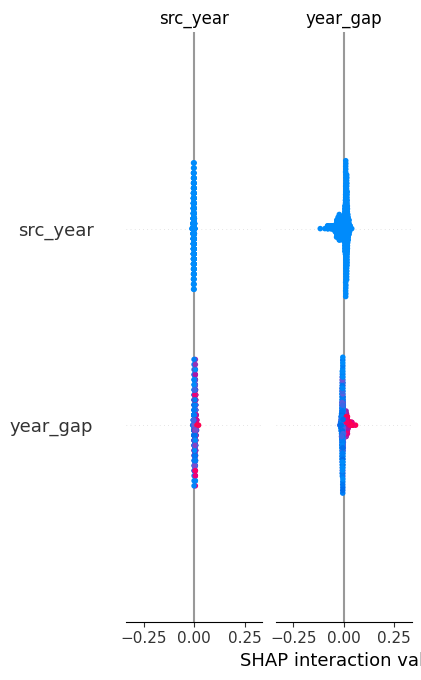

Random Forest — Mean |SHAP|


C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\2855672341.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(rf_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="bar")
c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to

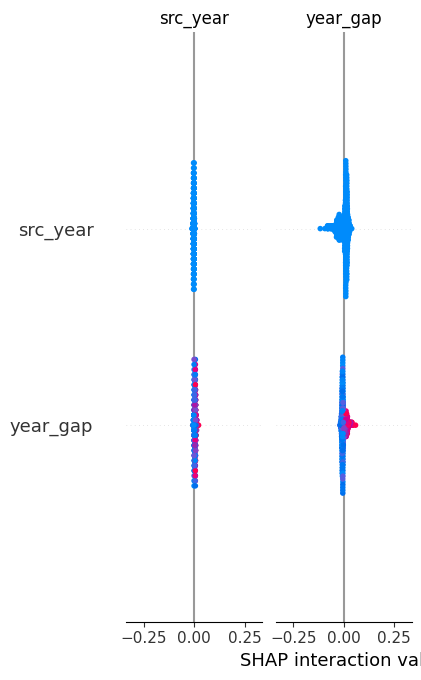

Computing SHAP values — LightGBM...


c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\2855672341.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(lgbm_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="dot")


LightGBM — Beeswarm


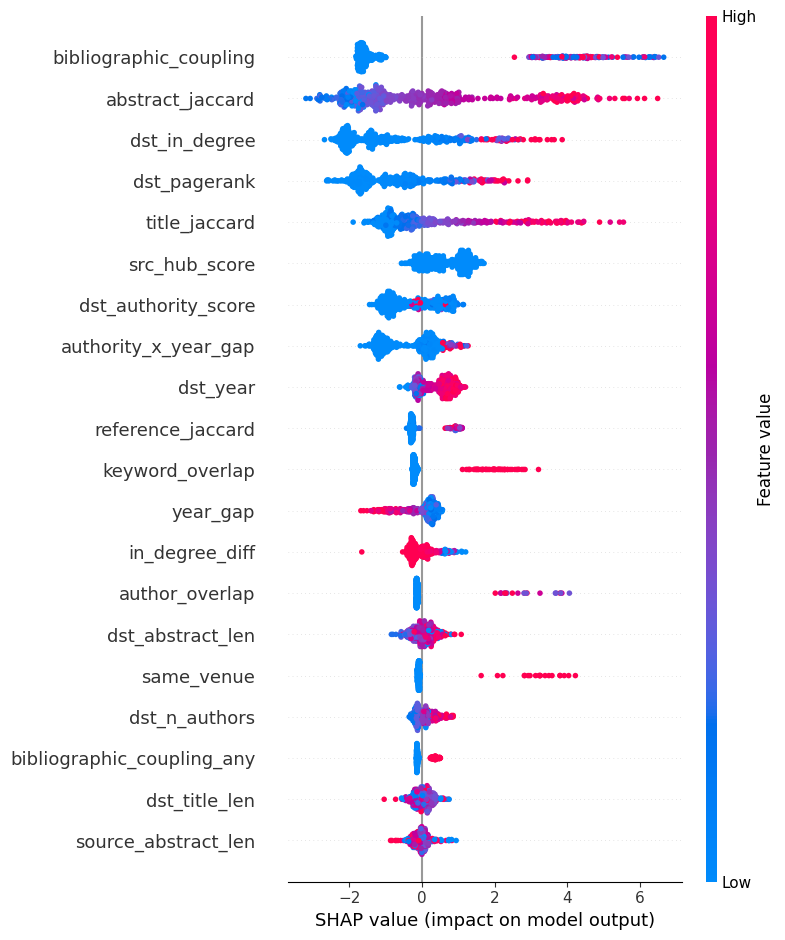

LightGBM — Mean |SHAP|


C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\2855672341.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(lgbm_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="bar")


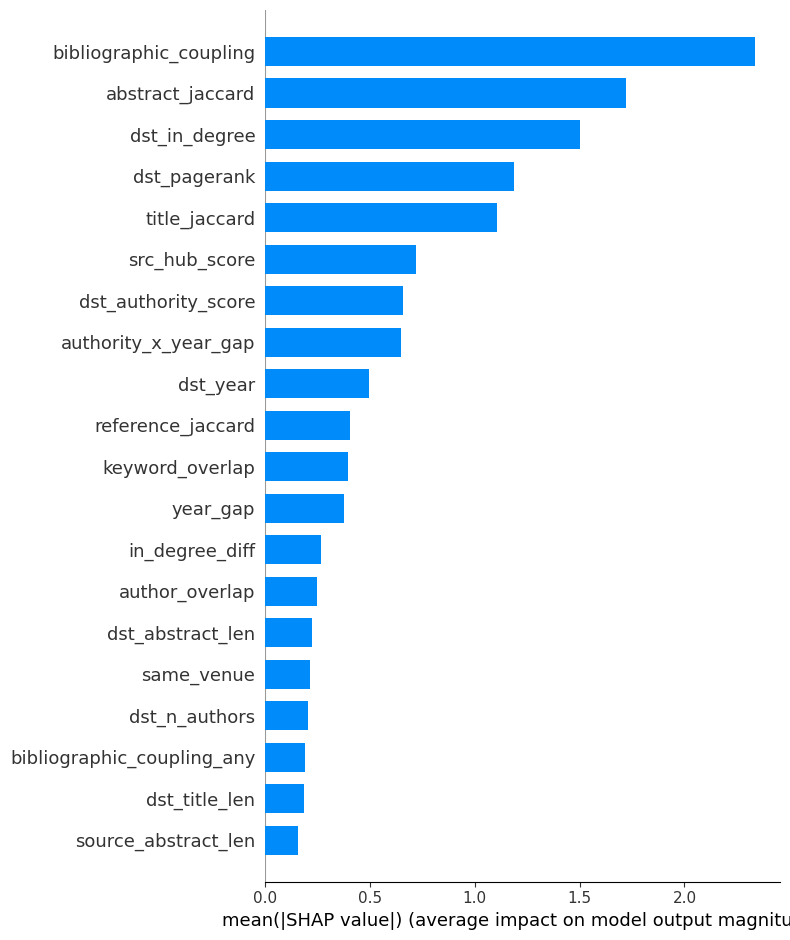

Computing SHAP values — MLP (may take a minute)...


100%|██████████| 500/500 [00:07<00:00, 67.59it/s]
C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\2855672341.py:48: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(mlp_shap_values, X_te_s[:N_SHAP], feature_names=feature_cols, plot_type="dot")


MLP — Beeswarm


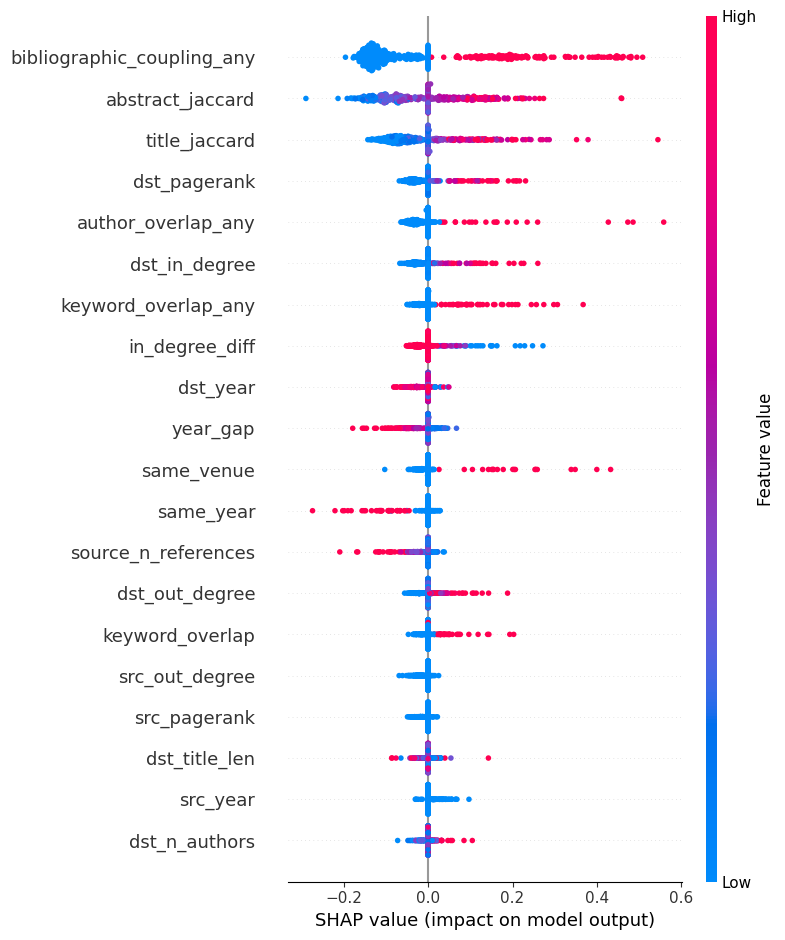

MLP — Mean |SHAP|


C:\Users\Alessio\AppData\Local\Temp\ipykernel_24908\2855672341.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(mlp_shap_values, X_te_s[:N_SHAP], feature_names=feature_cols, plot_type="bar")


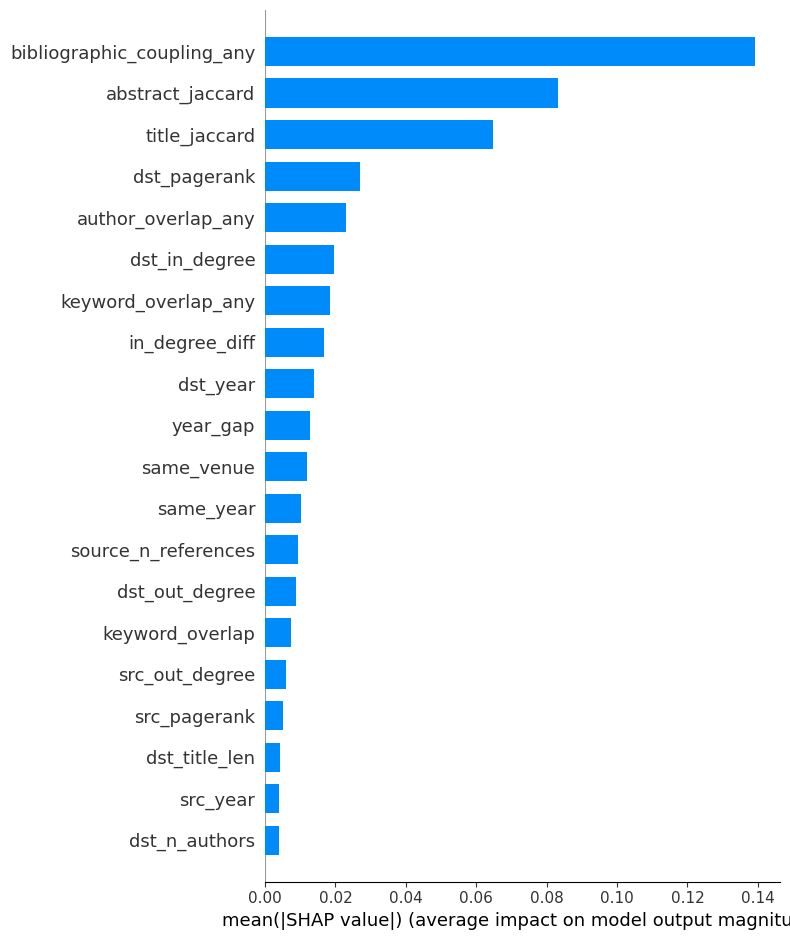

In [77]:
import shap
shap.initjs()

N_SHAP = min(500, len(X_te))

# ── 1. Random Forest ─────────────────────────────────────────────────────────
print("Computing SHAP values — Random Forest...")
rf_explainer   = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_te[:N_SHAP])
rf_sv = rf_shap_values[1] if isinstance(rf_shap_values, list) else rf_shap_values

print("Random Forest — Beeswarm")
shap.summary_plot(rf_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="dot")

print("Random Forest — Mean |SHAP|")
shap.summary_plot(rf_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="bar")


# ── 2. LightGBM ──────────────────────────────────────────────────────────────
print("Computing SHAP values — LightGBM...")
lgbm_explainer   = shap.TreeExplainer(lgbm_model)
lgbm_shap_values = lgbm_explainer.shap_values(X_te[:N_SHAP])
lgbm_sv = lgbm_shap_values[1] if isinstance(lgbm_shap_values, list) else lgbm_shap_values

print("LightGBM — Beeswarm")
shap.summary_plot(lgbm_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="dot")

print("LightGBM — Mean |SHAP|")
shap.summary_plot(lgbm_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="bar")


# ── 3. MLP ───────────────────────────────────────────────────────────────────
print("Computing SHAP values — MLP (may take a minute)...")
N_BG   = min(100, len(X_tr_s))
bg_idx = np.random.default_rng(42).choice(len(X_tr_s), N_BG, replace=False)
background = X_tr_s[bg_idx]

def mlp_predict(X):
    mlp_model.eval()
    with torch.no_grad():
        logits = mlp_model(torch.tensor(X, dtype=torch.float32).to(DEVICE))
        return torch.sigmoid(logits).cpu().numpy()

mlp_explainer   = shap.KernelExplainer(mlp_predict, background)
mlp_shap_values = mlp_explainer.shap_values(X_te_s[:N_SHAP], nsamples=128)

print("MLP — Beeswarm")
shap.summary_plot(mlp_shap_values, X_te_s[:N_SHAP], feature_names=feature_cols, plot_type="dot")

print("MLP — Mean |SHAP|")
shap.summary_plot(mlp_shap_values, X_te_s[:N_SHAP], feature_names=feature_cols, plot_type="bar")

### Why this baseline is a better fit

This section is aligned with the target because each example is explicitly a paper pair. It is also easier to explain:
- SHAP highlights which pair-level signals drive a citation decision,
- uncertainty from the forest shows which predictions are ambiguous,
- the features are interpretable and do not rely on citation-count leakage.

So the narrative is: the GCN is a graph-native approach, but the tabular pair model is the clean supervised baseline for the actual link-classification task.

In [78]:
# FORSE DA TOGLIERE 

# import networkx as nx
# import matplotlib.pyplot as plt
# import numpy as np

# SEED = 42
# N_NODES = 100

# # --- 1. Pick the 100 most-connected papers (in + out degree combined) ---
# edges_arr = edge_df[['src_idx', 'dst_idx']].to_numpy()

# # Count appearances on either end
# all_endpoints = np.concatenate([edges_arr[:, 0], edges_arr[:, 1]])
# unique, counts = np.unique(all_endpoints, return_counts=True)
# order = np.argsort(-counts)  # descending

# selected = set(unique[order[:N_NODES]].tolist())

# # Keep edges whose BOTH endpoints are in the sample
# mask = np.isin(edges_arr[:, 0], list(selected)) & np.isin(edges_arr[:, 1], list(selected))
# sub_edges = edges_arr[mask]

# # --- 2. Build directed graph ---
# G = nx.DiGraph()
# G.add_nodes_from(selected)
# G.add_edges_from(sub_edges.tolist())

# # Drop isolated nodes (no edges to other sampled nodes) so the plot stays clean
# G.remove_nodes_from([n for n in list(G.nodes()) if G.degree(n) == 0])

# print(f"Subgraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} citation links")

# # --- 3. Visual encoding ---
# nodes_list = list(G.nodes())
# if 'year' in node_df.columns:
#     node_years = node_df.set_index('node_idx').loc[nodes_list, 'year'].to_numpy()
# else:
#     node_years = None

# in_deg = np.array([G.in_degree(n) for n in nodes_list])
# node_sizes = 60 + in_deg * 25

# # --- 4. Plot ---
# fig, ax = plt.subplots(figsize=(14, 11))
# pos = nx.spring_layout(G, seed=SEED, k=1.2 / np.sqrt(max(G.number_of_nodes(), 1)), iterations=150)

# nx.draw_networkx_edges(
#     G, pos, ax=ax,
#     edge_color='#999', alpha=0.35, width=0.6,
#     arrows=True, arrowsize=7, arrowstyle='->',
#     connectionstyle='arc3,rad=0.1',
# )

# nodes_drawn = nx.draw_networkx_nodes(
#     G, pos, ax=ax,
#     nodelist=nodes_list,
#     node_size=node_sizes,
#     node_color=node_years if node_years is not None else '#1f77b4',
#     cmap='viridis',
#     edgecolors='white', linewidths=0.8,
#     alpha=0.95,
# )

# # Label only the top 10 most-cited papers
# top_nodes = sorted(nodes_list, key=lambda n: G.in_degree(n), reverse=True)[:10]
# nx.draw_networkx_labels(
#     G, pos, ax=ax,
#     labels={n: str(n) for n in top_nodes},
#     font_size=8,
# )

# if node_years is not None:
#     cbar = plt.colorbar(nodes_drawn, ax=ax, shrink=0.7, pad=0.01)
#     cbar.set_label('Publication year')

# ax.set_title(
#     f"Citation graph — {G.number_of_nodes()} papers, {G.number_of_edges()} links "
#     f"(top-{N_NODES} most-connected)",
#     fontsize=13,
# )
# ax.set_axis_off()
# plt.tight_layout()
# plt.show()